In [ ]:
# ============================================================
# PAPERREADY AI — CELL 1
# Environment & GPU Setup
# ============================================================

import sys
import os
import platform
import torch

print("=" * 60)
print("PAPERREADY AI — ENVIRONMENT CHECK")
print("=" * 60)

print(f"Python version : {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Platform       : {platform.platform()}")

if torch.cuda.is_available():
    print("\n✅ GPU AVAILABLE")
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version   : {torch.version.cuda}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("\n❌ GPU NOT AVAILABLE")
    print("Please enable: Runtime → Change runtime type → T4 GPU")

print("=" * 60)

PAPERREADY AI — ENVIRONMENT CHECK
Python version : 3.12.13
PyTorch version: 2.11.0+cpu
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35

❌ GPU NOT AVAILABLE
Please enable: Runtime → Change runtime type → T4 GPU


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 2
# Install Required Libraries
# ============================================================

!pip -q install -U \
    transformers \
    datasets \
    accelerate \
    scikit-learn \
    pandas \
    matplotlib \
    seaborn \
    kaggle

print("✅ Required libraries installed successfully!")

✅ Required libraries installed successfully!


KGAT_1286a7be264a3775c911ae93d8f9b955


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 3
# Kaggle Authentication + DAIGT v2 Download
# ============================================================

import os
from getpass import getpass

print("=" * 60)
print("KAGGLE AUTHENTICATION")
print("=" * 60)

# Enter credentials securely
kaggle_username = input("Enter your Kaggle username: ")
kaggle_key = getpass("Enter your Kaggle API key: ")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_key

print("\n✅ Kaggle credentials configured.")

# Download dataset
dataset_path = "/content/daigt-v2"

os.makedirs(dataset_path, exist_ok=True)

!kaggle datasets download -d thedrcat/daigt-v2-train-dataset \
    -p /content/daigt-v2 \
    --unzip

print("\n" + "=" * 60)
print("DATASET DOWNLOAD COMPLETE")
print("=" * 60)

# Show downloaded files
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

KAGGLE AUTHENTICATION
Enter your Kaggle username: Neela_Vyshali_13
Enter your Kaggle API key: ··········

✅ Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset
License(s): other
100% 28.5M/28.5M [00:00<00:00, 58.6MB/s]


DATASET DOWNLOAD COMPLETE
/content/daigt-v2/train_v2_drcat_02.csv


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 4
# Load, Clean & Balance DAIGT v2
# ============================================================

import pandas as pd
import numpy as np

DATASET_FILE = "/content/daigt-v2/train_v2_drcat_02.csv"

df = pd.read_csv(DATASET_FILE)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Total rows       : {len(df):,}")
print(f"Columns          : {list(df.columns)}")

# ------------------------------------------------------------
# Identify text and label columns
# ------------------------------------------------------------

possible_text_cols = ["text", "essay", "content", "generated_text"]
possible_label_cols = ["label", "generated", "target"]

text_col = next((c for c in possible_text_cols if c in df.columns), None)
label_col = next((c for c in possible_label_cols if c in df.columns), None)

if text_col is None or label_col is None:
    print("\n⚠️ Could not automatically identify columns.")
    print("Please send me the columns shown above.")
else:
    print(f"\nText column      : {text_col}")
    print(f"Label column     : {label_col}")

    # --------------------------------------------------------
    # Keep only required columns
    # --------------------------------------------------------

    data = df[[text_col, label_col]].copy()
    data.columns = ["text", "label"]

    # --------------------------------------------------------
    # Clean
    # --------------------------------------------------------

    data["text"] = data["text"].astype(str).str.strip()

    before = len(data)

    data = data[data["text"].str.len() > 0]
    data = data.drop_duplicates(subset=["text"])
    data = data.reset_index(drop=True)

    print(f"\nRemoved empty/duplicate rows: {before - len(data):,}")
    print(f"Rows after cleaning        : {len(data):,}")

    # --------------------------------------------------------
    # Label distribution
    # --------------------------------------------------------

    print("\nOriginal label distribution:")
    print(data["label"].value_counts().sort_index())

    # --------------------------------------------------------
    # Balance classes
    # --------------------------------------------------------

    class_counts = data["label"].value_counts()

    if len(class_counts) != 2:
        raise ValueError(
            f"Expected exactly 2 classes, but found: {class_counts.index.tolist()}"
        )

    min_count = class_counts.min()

    balanced_parts = []

    for label_value in sorted(class_counts.index):
        class_data = data[data["label"] == label_value]

        # Reproducible random downsampling
        class_data = class_data.sample(
            n=min_count,
            random_state=42
        )

        balanced_parts.append(class_data)

    balanced_df = (
        pd.concat(balanced_parts)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

    print("\nBalanced dataset:")
    print(balanced_df["label"].value_counts().sort_index())

    print(f"\nFinal dataset size: {len(balanced_df):,}")

    print("\nSample:")
    print(balanced_df.head(2)[["label", "text"]].to_string(index=False))

    # Save cleaned balanced dataset
    CLEAN_DATASET = "/content/daigt-v2/balanced_cleaned.csv"
    balanced_df.to_csv(CLEAN_DATASET, index=False)

    print(f"\n✅ Cleaned dataset saved to:")
    print(CLEAN_DATASET)

DATASET LOADED
Total rows       : 44,868
Columns          : ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']

Text column      : text
Label column     : label

Removed empty/duplicate rows: 4
Rows after cleaning        : 44,864

Original label distribution:
label
0    27367
1    17497
Name: count, dtype: int64

Balanced dataset:
label
0    17497
1    17497
Name: count, dtype: int64

Final dataset size: 34,994

Sample:
 label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 5
# Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Use the balanced dataset created in Cell 4
data = balanced_df.copy()

print("=" * 60)
print("CREATING TRAIN / VALIDATION / TEST SPLITS")
print("=" * 60)

# ------------------------------------------------------------
# First split: 80% train, 20% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["label"],
    random_state=42
)

# ------------------------------------------------------------
# Second split: temporary → 10% validation + 10% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Total      : {len(data):,}")
print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")

print("\nLabel distribution:")

print("\nTRAIN:")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["label"].value_counts().sort_index())

print("\nTEST:")
print(test_df["label"].value_counts().sort_index())

# ------------------------------------------------------------
# Save splits
# ------------------------------------------------------------

train_df.to_csv("/content/daigt-v2/train.csv", index=False)
val_df.to_csv("/content/daigt-v2/validation.csv", index=False)
test_df.to_csv("/content/daigt-v2/test.csv", index=False)

print("\n✅ Splits saved successfully.")
print("=" * 60)

CREATING TRAIN / VALIDATION / TEST SPLITS
Total      : 34,994
Train      : 27,995
Validation : 3,499
Test       : 3,500

Label distribution:

TRAIN:
label
0    13997
1    13998
Name: count, dtype: int64

VALIDATION:
label
0    1750
1    1749
Name: count, dtype: int64

TEST:
label
0    1750
1    1750
Name: count, dtype: int64

✅ Splits saved successfully.


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 6
# DistilBERT Tokenization
# ============================================================

from datasets import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

print("=" * 60)
print("LOADING DISTILBERT TOKENIZER")
print("=" * 60)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Model          : {MODEL_NAME}")
print(f"Max sequence   : {MAX_LENGTH}")
print("Tokenizer      : Loaded successfully")

# ------------------------------------------------------------
# Convert pandas DataFrames → Hugging Face Dataset
# ------------------------------------------------------------

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

# ------------------------------------------------------------
# Tokenization function
# ------------------------------------------------------------

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

print("\nTokenizing training data...")
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    desc="Train tokenization"
)

print("Tokenizing validation data...")
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    desc="Validation tokenization"
)

print("Tokenizing test data...")
test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    desc="Test tokenization"
)

# ------------------------------------------------------------
# Keep only model-required columns
# ------------------------------------------------------------

columns_to_keep = [
    "input_ids",
    "attention_mask",
    "label"
]

train_dataset.set_format(
    type="torch",
    columns=columns_to_keep
)

val_dataset.set_format(
    type="torch",
    columns=columns_to_keep
)

test_dataset.set_format(
    type="torch",
    columns=columns_to_keep
)

print("\n" + "=" * 60)
print("TOKENIZATION COMPLETE")
print("=" * 60)

print(f"Train samples      : {len(train_dataset):,}")
print(f"Validation samples : {len(val_dataset):,}")
print(f"Test samples       : {len(test_dataset):,}")

# Check one example
sample = train_dataset[0]

print("\nSample tensor shapes:")
print(f"input_ids     : {sample['input_ids'].shape}")
print(f"attention_mask: {sample['attention_mask'].shape}")
print(f"label         : {sample['label'].item()}")

print("\n✅ Datasets are ready for DistilBERT training.")

LOADING DISTILBERT TOKENIZER


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Tokenizing validation data...


Validation tokenization:   0%|          | 0/3499 [00:00<?, ? examples/s]

Tokenizing test data...


Test tokenization:   0%|          | 0/3500 [00:00<?, ? examples/s]


TOKENIZATION COMPLETE
Train samples      : 27,995
Validation samples : 3,499
Test samples       : 3,500

Sample tensor shapes:
input_ids     : torch.Size([256])
attention_mask: torch.Size([256])
label         : 1

✅ Datasets are ready for DistilBERT training.


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 7
# Load DistilBERT Binary Classifier
# ============================================================

import torch
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

print("=" * 60)
print("LOADING DISTILBERT CLASSIFICATION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Label mapping
# ------------------------------------------------------------

id2label = {
    0: "HUMAN",
    1: "AI_GENERATED"
}

label2id = {
    "HUMAN": 0,
    "AI_GENERATED": 1
}

# ------------------------------------------------------------
# Load pretrained DistilBERT
# ------------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# ------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Model          : {MODEL_NAME}")
print(f"Device         : {device}")
print(f"Labels         : {id2label}")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")

print("\nClassification head:")
print(model.classifier)

print("\n" + "=" * 60)
print("✅ DISTILBERT MODEL READY FOR FINE-TUNING")
print("=" * 60)

LOADING DISTILBERT CLASSIFICATION MODEL


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model          : distilbert-base-uncased
Device         : cpu
Labels         : {0: 'HUMAN', 1: 'AI_GENERATED'}
Total params   : 66,955,010
Trainable      : 66,955,010

Classification head:
Linear(in_features=768, out_features=2, bias=True)

✅ DISTILBERT MODEL READY FOR FINE-TUNING


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 8
# Training Configuration + Evaluation Metrics
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import TrainingArguments

print("=" * 60)
print("CONFIGURING DISTILBERT FINE-TUNING")
print("=" * 60)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir="/content/paperready_ai_training",

    # Training
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",

    # Keep the best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Speed on T4
    fp16=True,

    # Logging
    logging_strategy="steps",
    logging_steps=100,

    # Reproducibility
    seed=42,

    # Avoid unnecessary external reporting
    report_to="none"
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("Model                    : DistilBERT")
print("Epochs                   : 2")
print("Training batch size     : 16")
print("Evaluation batch size   : 32")
print("Learning rate            : 2e-5")
print("Weight decay             : 0.01")
print("Mixed precision (FP16)  : Enabled")
print("Evaluation               : Every epoch")
print("Best model metric       : F1")
print("Random seed              : 42")

print("\nMetrics:")
print("✓ Accuracy")
print("✓ Precision")
print("✓ Recall")
print("✓ F1")

print("\n" + "=" * 60)
print("✅ TRAINING CONFIGURATION READY")
print("=" * 60)

CONFIGURING DISTILBERT FINE-TUNING
Model                    : DistilBERT
Epochs                   : 2
Training batch size     : 16
Evaluation batch size   : 32
Learning rate            : 2e-5
Weight decay             : 0.01
Mixed precision (FP16)  : Enabled
Evaluation               : Every epoch
Best model metric       : F1
Random seed              : 42

Metrics:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1

✅ TRAINING CONFIGURATION READY


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 9
# ACTUAL DISTILBERT FINE-TUNING
# ============================================================

from transformers import Trainer

print("=" * 60)
print("STARTING DISTILBERT FINE-TUNING")
print("=" * 60)

# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    # New Transformers versions use processing_class
    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer initialized successfully.")
print("\n🚀 Training started...\n")

# ------------------------------------------------------------
# ACTUAL TRAINING
# ------------------------------------------------------------

train_result = trainer.train()

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETED")
print("=" * 60)

print("\nTraining metrics:")
print(train_result.metrics)

STARTING DISTILBERT FINE-TUNING
Trainer initialized successfully.

🚀 Training started...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


FINAL TEST SET EVALUATION



FINAL TEST RESULTS
----------------------------------------
Accuracy  : 99.14%
Precision : 98.53%
Recall    : 99.77%
F1 Score  : 99.15%

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

       Human     0.9977    0.9851    0.9914      1750
AI-Generated     0.9853    0.9977    0.9915      1750

    accuracy                         0.9914      3500
   macro avg     0.9915    0.9914    0.9914      3500
weighted avg     0.9915    0.9914    0.9914      3500


CONFUSION MATRIX
----------------------------------------
[[1724   26]
 [   4 1746]]


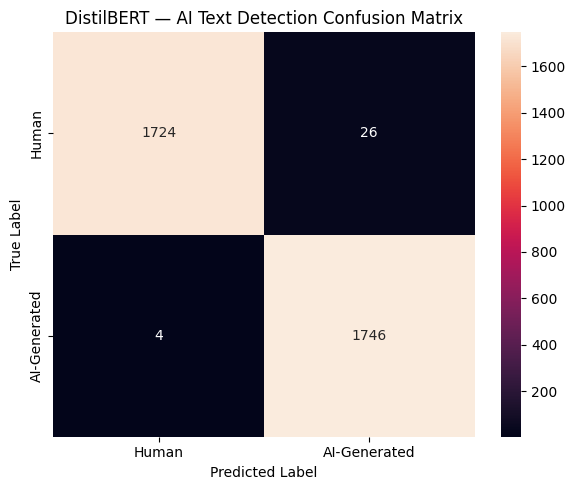


✅ FINAL TEST EVALUATION COMPLETE


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 10
# FINAL HELD-OUT TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Evaluate on completely unseen test data
# ------------------------------------------------------------

test_results = trainer.predict(test_dataset)

predictions = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(
    true_labels,
    predictions,
    zero_division=0
)

recall = recall_score(
    true_labels,
    predictions,
    zero_division=0
)

f1 = f1_score(
    true_labels,
    predictions,
    zero_division=0
)

# ------------------------------------------------------------
# Print final metrics
# ------------------------------------------------------------

print("\nFINAL TEST RESULTS")
print("-" * 40)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

# ------------------------------------------------------------
# Detailed classification report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("-" * 40)

print(
    classification_report(
        true_labels,
        predictions,
        target_names=["Human", "AI-Generated"],
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(true_labels, predictions)

print("\nCONFUSION MATRIX")
print("-" * 40)
print(cm)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Human", "AI-Generated"],
    yticklabels=["Human", "AI-Generated"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT — AI Text Detection Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ FINAL TEST EVALUATION COMPLETE")
print("=" * 60)

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 11
# SAVE TRAINED MODEL + TOKENIZER
# ============================================================

import os
import json

MODEL_SAVE_PATH = "/content/paperready_ai_detector"

print("=" * 60)
print("SAVING TRAINED PAPERREADY AI DETECTOR")
print("=" * 60)

# ------------------------------------------------------------
# Save model and tokenizer
# ------------------------------------------------------------

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# ------------------------------------------------------------
# Save test metrics
# ------------------------------------------------------------

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "test_samples": int(len(test_dataset)),
    "epochs": 2,
    "max_length": 256,
    "base_model": "distilbert-base-uncased",
    "dataset": "DAIGT v2"
}

with open(
    os.path.join(MODEL_SAVE_PATH, "test_metrics.json"),
    "w"
) as f:
    json.dump(metrics, f, indent=4)

print("\n✅ Model saved to:")
print(MODEL_SAVE_PATH)

print("\nSaved files:")

for root, dirs, files in os.walk(MODEL_SAVE_PATH):
    for file in files:
        print("  ", os.path.join(root, file))

print("\nFinal test metrics saved:")
print(json.dumps(metrics, indent=4))

print("\n" + "=" * 60)
print("✅ TRAINED MODEL READY FOR PAPERREADY AI")
print("=" * 60)

SAVING TRAINED PAPERREADY AI DETECTOR


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to:
/content/paperready_ai_detector

Saved files:
   /content/paperready_ai_detector/tokenizer_config.json
   /content/paperready_ai_detector/model.safetensors
   /content/paperready_ai_detector/training_args.bin
   /content/paperready_ai_detector/test_metrics.json
   /content/paperready_ai_detector/tokenizer.json
   /content/paperready_ai_detector/config.json

Final test metrics saved:
{
    "accuracy": 0.9914285714285714,
    "precision": 0.9853273137697517,
    "recall": 0.9977142857142857,
    "f1": 0.9914821124361158,
    "test_samples": 3500,
    "epochs": 2,
    "max_length": 256,
    "base_model": "distilbert-base-uncased",
    "dataset": "DAIGT v2"
}

✅ TRAINED MODEL READY FOR PAPERREADY AI


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 12
# AI RISK INFERENCE FUNCTION
# ============================================================

import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_PATH = "/content/paperready_ai_detector"

print("=" * 60)
print("LOADING TRAINED PAPERREADY AI DETECTOR")
print("=" * 60)

# ------------------------------------------------------------
# Load saved tokenizer and model
# ------------------------------------------------------------

risk_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

risk_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

risk_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

risk_model.to(risk_device)
risk_model.eval()

print(f"Model loaded : {MODEL_PATH}")
print(f"Device       : {risk_device}")

# ------------------------------------------------------------
# AI risk function
# ------------------------------------------------------------

def get_ai_risk_score(text):
    """
    Returns AI-generated probability and risk level
    for a given text.
    """

    if not isinstance(text, str) or not text.strip():
        return {
            "ai_probability": 0.0,
            "human_probability": 0.0,
            "risk_level": "UNKNOWN"
        }

    # Tokenize
    inputs = risk_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    # Move tensors to GPU
    inputs = {
        key: value.to(risk_device)
        for key, value in inputs.items()
    }

    # Inference
    with torch.no_grad():
        outputs = risk_model(**inputs)

    # Convert logits → probabilities
    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )[0]

    human_probability = probabilities[0].item()
    ai_probability = probabilities[1].item()

    # Risk classification
    if ai_probability < 0.30:
        risk_level = "LOW"
    elif ai_probability < 0.70:
        risk_level = "MEDIUM"
    else:
        risk_level = "HIGH"

    return {
        "ai_probability": round(ai_probability * 100, 2),
        "human_probability": round(human_probability * 100, 2),
        "risk_level": risk_level
    }


# ============================================================
# QUICK SANITY TEST
# ============================================================

human_example = """
The experiment was conducted using three datasets collected from
different laboratory conditions. We observed that the proposed
method performed better on the first dataset, although its
performance decreased slightly when the input images contained
noise. These observations were consistent with the results
obtained during our earlier experiments.
"""

ai_example = """
The proposed approach demonstrates significant potential for
advancing the field by providing an effective, robust, and
innovative solution. Furthermore, the results clearly indicate
that the methodology achieves outstanding performance across
various scenarios and can contribute substantially to future
research and practical applications.
"""

print("\n" + "=" * 60)
print("SANITY TEST")
print("=" * 60)

print("\nExample 1:")
print(get_ai_risk_score(human_example))

print("\nExample 2:")
print(get_ai_risk_score(ai_example))

print("\n" + "=" * 60)
print("✅ get_ai_risk_score() READY")
print("=" * 60)

LOADING TRAINED PAPERREADY AI DETECTOR


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded : /content/paperready_ai_detector
Device       : cuda

SANITY TEST

Example 1:
{'ai_probability': 99.98, 'human_probability': 0.02, 'risk_level': 'HIGH'}

Example 2:
{'ai_probability': 99.99, 'human_probability': 0.01, 'risk_level': 'HIGH'}

✅ get_ai_risk_score() READY


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 13
# RESEARCH PAPER UPLOAD & BASIC INGESTION
# ============================================================

from google.colab import files
import os

print("=" * 60)
print("PAPERREADY AI — UPLOAD RESEARCH PAPER")
print("=" * 60)

uploaded = files.upload()

if not uploaded:
    raise ValueError("❌ No file uploaded.")

# Get uploaded filename
paper_filename = list(uploaded.keys())[0]
paper_path = os.path.abspath(paper_filename)

print("\n" + "=" * 60)
print("PAPER UPLOAD COMPLETE")
print("=" * 60)

print(f"Filename : {paper_filename}")
print(f"Path     : {paper_path}")
print(f"Size     : {os.path.getsize(paper_path) / (1024 * 1024):.2f} MB")

# Check extension
extension = os.path.splitext(paper_filename)[1].lower()

if extension == ".pdf":
    print("Type     : PDF ✅")
elif extension == ".docx":
    print("Type     : DOCX ✅")
else:
    print(f"Type     : {extension}")
    print("⚠️ Please use PDF or DOCX.")

print("\n✅ Paper is ready for ingestion.")
print("=" * 60)

PAPERREADY AI — UPLOAD RESEARCH PAPER


Saving Dental_ConfPaper.docx to Dental_ConfPaper.docx

PAPER UPLOAD COMPLETE
Filename : Dental_ConfPaper.docx
Path     : /content/Dental_ConfPaper.docx
Size     : 5.83 MB
Type     : DOCX ✅

✅ Paper is ready for ingestion.


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 14A
# DOCX SUPPORT
# ============================================================

!pip -q install python-docx

print("✅ python-docx installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.9 MB/s eta 0:00:00
✅ python-docx installed successfully!


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 14
# DOCX TEXT INGESTION & STRUCTURE EXTRACTION
# ============================================================

from docx import Document
import os
import re

print("=" * 60)
print("PAPERREADY AI — PAPER TEXT INGESTION")
print("=" * 60)

# ------------------------------------------------------------
# Load DOCX
# ------------------------------------------------------------

if not paper_path.lower().endswith(".docx"):
    raise ValueError(
        "This cell is for DOCX ingestion. "
        "PDF ingestion will be handled separately."
    )

document = Document(paper_path)

# ------------------------------------------------------------
# Extract paragraphs
# ------------------------------------------------------------

paragraphs = []

for paragraph in document.paragraphs:
    text = paragraph.text.strip()

    if text:
        paragraphs.append(text)

# ------------------------------------------------------------
# Extract tables
# ------------------------------------------------------------

tables_text = []

for table_index, table in enumerate(document.tables, start=1):

    rows = []

    for row in table.rows:
        cells = [
            cell.text.strip().replace("\n", " ")
            for cell in row.cells
        ]

        rows.append(" | ".join(cells))

    table_text = "\n".join(rows)

    if table_text.strip():
        tables_text.append(
            f"[TABLE {table_index}]\n{table_text}"
        )

# ------------------------------------------------------------
# Combine paper text
# ------------------------------------------------------------

paper_text = "\n\n".join(paragraphs)

# Keep table information separately for later CV/layout analysis
paper_tables_text = "\n\n".join(tables_text)

# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

word_count = len(re.findall(r"\b\w+\b", paper_text))

character_count = len(paper_text)

print(f"Paragraphs extracted : {len(paragraphs):,}")
print(f"Tables detected      : {len(document.tables):,}")
print(f"Word count           : {word_count:,}")
print(f"Character count      : {character_count:,}")

# ------------------------------------------------------------
# Detect likely section headings
# ------------------------------------------------------------

known_sections = [
    "abstract",
    "keywords",
    "introduction",
    "background",
    "literature review",
    "related work",
    "methodology",
    "method",
    "materials and methods",
    "proposed method",
    "results",
    "experiments",
    "discussion",
    "conclusion",
    "future work",
    "acknowledgment",
    "acknowledgements",
    "references"
]

detected_sections = []

for paragraph in paragraphs:

    normalized = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        paragraph.lower()
    ).strip()

    if normalized in known_sections:
        detected_sections.append(paragraph)

# ------------------------------------------------------------
# Display structure
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DETECTED SECTIONS")
print("=" * 60)

if detected_sections:
    for section in detected_sections:
        print("✓", section)
else:
    print("⚠️ No standard section headings detected automatically.")

# ------------------------------------------------------------
# Preview extracted text
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PAPER TEXT PREVIEW")
print("=" * 60)

preview = paper_text[:3000]

print(preview)

if len(paper_text) > 3000:
    print("\n...[preview truncated]...")

# ------------------------------------------------------------
# Save extracted text
# ------------------------------------------------------------

TEXT_OUTPUT = "/content/paper_text.txt"

with open(TEXT_OUTPUT, "w", encoding="utf-8") as f:
    f.write(paper_text)

print("\n" + "=" * 60)
print("✅ PAPER TEXT INGESTION COMPLETE")
print("=" * 60)

print(f"Extracted text saved to: {TEXT_OUTPUT}")

PAPERREADY AI — PAPER TEXT INGESTION
Paragraphs extracted : 98
Tables detected      : 1
Word count           : 3,892
Character count      : 27,169

DETECTED SECTIONS
✓ REFERENCES

PAPER TEXT PREVIEW
A Multimodal Deep Learning Framework for Orthodontic Treatment Progress Monitoring Using Panoramic Dental Radiographs and Intraoral 3D Scan

Abstract— Orthodontic therapy needs to be monitored on a regular basis to check any tooth movement and to ensure that treatment is moving towards the desired result. Traditional orthodontic treatment procedures are mainly based on manual examination of the patient's mouth and the interpretation of panoramic dental radiographs and intraoral scans, which are time-consuming and treatment evaluations are largely dependent on clinical experience. Current visualization systems only show the initial and final tooth position, which doesn't give much information about the intermediate steps of therapy. To overcome this drawback, a multimodal Artificial Intellig

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 17
# FINAL CLEAN PAPER STRUCTURE
# ============================================================

import re
import json

print("=" * 60)
print("PAPERREADY AI — FINAL PAPER STRUCTURE")
print("=" * 60)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def roman_heading(text):
    """
    Detect:
    I. INTRODUCTION
    II.RELATED WORK
    III. Proposed Methodology
    """
    text = re.sub(r"\s+", " ", text.strip())

    match = re.match(
        r"^([IVXLC]+)\s*[\.\)]\s*(.+)$",
        text,
        flags=re.IGNORECASE
    )

    if match:
        return match.group(2).strip()

    return None


def letter_subheading(text):
    """
    Detect:
    A. ...
    B. ...
    C. ...
    """
    text = re.sub(r"\s+", " ", text.strip())

    return bool(
        re.match(
            r"^[A-Z]\s*[\.\)]\s+.+$",
            text
        )
    )


# ------------------------------------------------------------
# Initialize
# ------------------------------------------------------------

final_sections = {}

current_main_section = None

for paragraph in paragraphs:

    text = paragraph.strip()

    if not text:
        continue

    # --------------------------------------------------------
    # ABSTRACT
    # --------------------------------------------------------

    abstract_match = re.match(
        r"^abstract\s*[-—:]\s*(.*)$",
        text,
        flags=re.IGNORECASE
    )

    if abstract_match:

        current_main_section = "abstract"

        content = abstract_match.group(1).strip()

        final_sections[current_main_section] = content

        continue


    # --------------------------------------------------------
    # KEYWORDS
    # --------------------------------------------------------

    keyword_match = re.match(
        r"^keywords?\s*[-—:]\s*(.*)$",
        text,
        flags=re.IGNORECASE
    )

    if keyword_match:

        current_main_section = "keywords"

        content = keyword_match.group(1).strip()

        final_sections[current_main_section] = content

        continue


    # --------------------------------------------------------
    # REFERENCES
    # --------------------------------------------------------

    if re.match(
        r"^references\s*$",
        text,
        flags=re.IGNORECASE
    ):

        current_main_section = "references"

        final_sections[current_main_section] = ""

        continue


    # --------------------------------------------------------
    # ROMAN-NUMBERED MAIN SECTION
    # --------------------------------------------------------

    main_name = roman_heading(text)

    if main_name:

        current_main_section = main_name.lower()

        final_sections[current_main_section] = ""

        continue


    # --------------------------------------------------------
    # LETTER SUBSECTION
    # --------------------------------------------------------

    if letter_subheading(text):

        # Keep subsection heading inside current section.
        if current_main_section:

            if final_sections[current_main_section]:
                final_sections[current_main_section] += "\n\n"

            final_sections[current_main_section] += text

        continue


    # --------------------------------------------------------
    # NORMAL CONTENT
    # --------------------------------------------------------

    if current_main_section:

        if final_sections[current_main_section]:

            final_sections[current_main_section] += "\n\n"

        final_sections[current_main_section] += text


# ------------------------------------------------------------
# Clean content
# ------------------------------------------------------------

for section in final_sections:

    final_sections[section] = re.sub(
        r"\n{3,}",
        "\n\n",
        final_sections[section]
    ).strip()


# ------------------------------------------------------------
# Display final structure
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DETECTED MAIN SECTIONS")
print("=" * 60)

for name, content in final_sections.items():

    words = len(
        re.findall(
            r"\b\w+\b",
            content
        )
    )

    print(
        f"✓ {name.title():35s} "
        f"{words:,} words"
    )


# ------------------------------------------------------------
# Create AI chunks
# ------------------------------------------------------------

def create_chunks(text, max_words=180):

    words = text.split()

    chunks = []

    for start in range(
        0,
        len(words),
        max_words
    ):

        chunk = " ".join(
            words[start:start + max_words]
        ).strip()

        if len(chunk.split()) >= 20:
            chunks.append(chunk)

    return chunks


paper_chunks = []

for section_name, content in final_sections.items():

    # References and keywords are not useful for AI-writing risk
    if section_name in [
        "references",
        "keywords"
    ]:
        continue

    chunks = create_chunks(content)

    for chunk in chunks:

        paper_chunks.append({
            "section": section_name,
            "text": chunk
        })


# ------------------------------------------------------------
# Chunk summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AI ANALYSIS CHUNKS")
print("=" * 60)

print(
    f"Total chunks: {len(paper_chunks)}"
)

from collections import Counter

section_chunk_counts = Counter(
    item["section"]
    for item in paper_chunks
)

for section, count in section_chunk_counts.items():

    print(
        f"✓ {section.title():35s} "
        f"{count} chunks"
    )


# ------------------------------------------------------------
# Save final structure
# ------------------------------------------------------------

with open(
    "/content/paper_sections.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_sections,
        f,
        indent=2,
        ensure_ascii=False
    )


with open(
    "/content/paper_ai_chunks.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        paper_chunks,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n" + "=" * 60)
print("✅ FINAL PAPER STRUCTURE READY")
print("=" * 60)

print(
    "Saved sections : /content/paper_sections.json"
)

print(
    "Saved chunks   : /content/paper_ai_chunks.json"
)

PAPERREADY AI — FINAL PAPER STRUCTURE

FINAL DETECTED MAIN SECTIONS
✓ Abstract                            263 words
✓ Keywords                            19 words
✓ Introduction                        490 words
✓ Related Work                        591 words
✓ Proposed Methodology                319 words
✓ Tooth Detection And Segmentation    619 words
✓ Clinical Decision Support And Future Enhancement The Proposed Framework Is Designed As An Ai Based Clinical Decision Support System To Assist Orthodontist In The Process Of Treatment Evaluation, Not To Replace Clinical Expertise. The System Automates The Tooth Analysis Process, Captures Quantitative Measurements Of Tooth Movements, And Records Treatment Progress Visually, Making Treatment Documentation And Communication Easier. The Modular Design Offers Flexibility For Future Integration Of Predictive Ai Models To Support Personalised Orthodontic Treatments, Estimate Treatment Times, And Predict Tooth Movement Patterns. 10 words
✓ Resu

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 18
# CLEAN AI ANALYSIS DATA
# ============================================================

import re
import json

print("=" * 60)
print("PAPERREADY AI — PREPARING AI RISK ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Sections we actually want to analyze
# ------------------------------------------------------------

target_sections = [
    "abstract",
    "introduction",
    "related work",
    "proposed methodology",
    "results and discussions",
    "conclusion"
]

clean_ai_sections = {}

for section_name in target_sections:

    if section_name in final_sections:

        text = final_sections[section_name].strip()

        if text:
            clean_ai_sections[section_name] = text


# ------------------------------------------------------------
# Create chunks
# ------------------------------------------------------------

def create_ai_chunks(text, max_words=180):

    words = text.split()
    chunks = []

    for start in range(0, len(words), max_words):

        chunk = " ".join(
            words[start:start + max_words]
        ).strip()

        if len(chunk.split()) >= 20:
            chunks.append(chunk)

    return chunks


ai_chunks = []

for section_name, text in clean_ai_sections.items():

    chunks = create_ai_chunks(text)

    for chunk in chunks:

        ai_chunks.append({
            "section": section_name,
            "text": chunk
        })


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\nSections selected for AI-risk analysis:")
print("-" * 60)

for section_name, text in clean_ai_sections.items():

    words = len(
        re.findall(r"\b\w+\b", text)
    )

    print(
        f"✓ {section_name.title():30s}"
        f"{words:,} words"
    )

print("\n" + "=" * 60)
print("AI CHUNKS")
print("=" * 60)

print(f"Total chunks: {len(ai_chunks)}")

from collections import Counter

counts = Counter(
    item["section"]
    for item in ai_chunks
)

for section, count in counts.items():

    print(
        f"✓ {section.title():30s}"
        f"{count} chunks"
    )


# ------------------------------------------------------------
# Save clean AI dataset
# ------------------------------------------------------------

with open(
    "/content/paper_ai_chunks.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        ai_chunks,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n" + "=" * 60)
print("✅ CLEAN AI ANALYSIS DATA READY")
print("=" * 60)

print(
    "Saved to: /content/paper_ai_chunks.json"
)

PAPERREADY AI — PREPARING AI RISK ANALYSIS

Sections selected for AI-risk analysis:
------------------------------------------------------------
✓ Abstract                      263 words
✓ Introduction                  490 words
✓ Related Work                  591 words
✓ Proposed Methodology          319 words
✓ Results And Discussions       255 words
✓ Conclusion                    209 words

AI CHUNKS
Total chunks: 14
✓ Abstract                      2 chunks
✓ Introduction                  3 chunks
✓ Related Work                  4 chunks
✓ Proposed Methodology          2 chunks
✓ Results And Discussions       2 chunks
✓ Conclusion                    1 chunks

✅ CLEAN AI ANALYSIS DATA READY
Saved to: /content/paper_ai_chunks.json


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 19
# FULL PAPER AI-WRITING RISK ANALYSIS
# ============================================================

import torch
import numpy as np
import pandas as pd

print("=" * 60)
print("PAPERREADY AI — AI-WRITING RISK ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Analyze all paper chunks
# ------------------------------------------------------------

results = []

for i, item in enumerate(ai_chunks):

    text = item["text"]

    # Tokenize
    inputs = risk_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    # Move to GPU
    inputs = {
        key: value.to(risk_device)
        for key, value in inputs.items()
    }

    # Model inference
    with torch.no_grad():

        outputs = risk_model(**inputs)

    # Convert logits → probabilities
    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )[0]

    human_probability = probabilities[0].item()
    ai_probability = probabilities[1].item()

    results.append({
        "chunk_id": i + 1,
        "section": item["section"],
        "ai_probability": ai_probability * 100,
        "human_probability": human_probability * 100
    })


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

ai_results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# Section-wise analysis
# ------------------------------------------------------------

section_summary = (
    ai_results_df
    .groupby("section")
    .agg(
        chunks=("chunk_id", "count"),
        average_ai_risk=("ai_probability", "mean"),
        maximum_ai_risk=("ai_probability", "max")
    )
    .reset_index()
)


# ------------------------------------------------------------
# Overall paper risk
# ------------------------------------------------------------

overall_ai_risk = ai_results_df[
    "ai_probability"
].mean()


# ------------------------------------------------------------
# Risk category
# ------------------------------------------------------------

if overall_ai_risk < 30:

    overall_risk_level = "LOW"

elif overall_ai_risk < 70:

    overall_risk_level = "MEDIUM"

else:

    overall_risk_level = "HIGH"


# ------------------------------------------------------------
# Display chunk-level results
# ------------------------------------------------------------

print("\nCHUNK-LEVEL RESULTS")
print("-" * 60)

display(
    ai_results_df.round(2)
)


# ------------------------------------------------------------
# Display section-level results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION-LEVEL AI RISK")
print("=" * 60)

display(
    section_summary.round(2)
)


# ------------------------------------------------------------
# Overall result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("OVERALL PAPER AI-WRITING RISK")
print("=" * 60)

print(
    f"AI Risk Score : {overall_ai_risk:.2f}%"
)

print(
    f"Risk Level    : {overall_risk_level}"
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

ai_results_df.to_csv(
    "/content/ai_chunk_results.csv",
    index=False
)

section_summary.to_csv(
    "/content/ai_section_summary.csv",
    index=False
)

print("\n" + "=" * 60)
print("✅ AI RISK ANALYSIS COMPLETE")
print("=" * 60)

print("Chunk results saved   : /content/ai_chunk_results.csv")
print("Section summary saved : /content/ai_section_summary.csv")

PAPERREADY AI — AI-WRITING RISK ANALYSIS

CHUNK-LEVEL RESULTS
------------------------------------------------------------


,chunk_id,section,ai_probability,human_probability
0,1,abstract,100.00,0.00
1,2,abstract,100.00,0.00
2,3,introduction,100.00,0.00
3,4,introduction,100.00,0.00
4,5,introduction,100.00,0.00
5,6,related work,100.00,0.00
6,7,related work,100.00,0.00
7,8,related work,99.99,0.01
8,9,related work,99.99,0.01
9,10,proposed methodology,99.99,0.01



SECTION-LEVEL AI RISK


,section,chunks,average_ai_risk,maximum_ai_risk
0,abstract,2,100.00,100.00
1,conclusion,1,99.99,99.99
2,introduction,3,100.00,100.00
3,proposed methodology,2,99.99,99.99
4,related work,4,99.99,100.00
5,results and discussions,2,99.92,99.99



OVERALL PAPER AI-WRITING RISK
AI Risk Score : 99.98%
Risk Level    : HIGH

✅ AI RISK ANALYSIS COMPLETE
Chunk results saved   : /content/ai_chunk_results.csv
Section summary saved : /content/ai_section_summary.csv


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 27
# ORIGINAL DAIGT TEST-SET DIAGNOSTIC
# ============================================================

import pandas as pd
import torch

print("=" * 60)
print("PAPERREADY AI — ORIGINAL TEST SET DIAGNOSTIC")
print("=" * 60)

# ------------------------------------------------------------
# Load original test set
# ------------------------------------------------------------

test_path = "/content/daigt-v2/test.csv"

test_df = pd.read_csv(test_path)

print("\nTest samples :", len(test_df))
print("Columns      :", list(test_df.columns))

print("\nLabel distribution:")
print(test_df["label"].value_counts().sort_index())


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def predict_saved_model(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

    human_probability = probabilities[0].item()
    ai_probability = probabilities[1].item()

    predicted_label = (
        1 if ai_probability >= 0.5 else 0
    )

    return (
        predicted_label,
        human_probability,
        ai_probability
    )


# ------------------------------------------------------------
# Test 20 samples
# ------------------------------------------------------------

sample_df = test_df.sample(
    n=20,
    random_state=42
).reset_index(drop=True)

results = []

for i, row in sample_df.iterrows():

    predicted_label, human_prob, ai_prob = (
        predict_saved_model(row["text"])
    )

    results.append({

        "sample": i + 1,

        "true_label": int(row["label"]),

        "predicted_label": predicted_label,

        "human_probability":
            round(human_prob * 100, 2),

        "ai_probability":
            round(ai_prob * 100, 2),

        "correct":
            predicted_label == int(row["label"])
    })


results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("20 SAMPLE PREDICTIONS")
print("=" * 60)

print(
    results_df.to_string(index=False)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

sample_accuracy = (
    results_df["correct"].mean() * 100
)

print("\n" + "=" * 60)
print("DIAGNOSTIC SUMMARY")
print("=" * 60)

print(
    f"20-sample accuracy : {sample_accuracy:.2f}%"
)

print(
    "Predicted HUMAN :",
    int(
        (results_df["predicted_label"] == 0).sum()
    )
)

print(
    "Predicted AI    :",
    int(
        (results_df["predicted_label"] == 1).sum()
    )
)

print(
    "Actual HUMAN    :",
    int(
        (results_df["true_label"] == 0).sum()
    )
)

print(
    "Actual AI       :",
    int(
        (results_df["true_label"] == 1).sum()
    )
)

print("\n" + "=" * 60)
print("✅ ORIGINAL TEST-SET DIAGNOSTIC COMPLETE")
print("=" * 60)

PAPERREADY AI — ORIGINAL TEST SET DIAGNOSTIC

Test samples : 3500
Columns      : ['text', 'label']

Label distribution:
label
0    1750
1    1750
Name: count, dtype: int64

20 SAMPLE PREDICTIONS
 sample  true_label  predicted_label  human_probability  ai_probability  correct
      1           1                1               0.00          100.00     True
      2           0                0              99.98            0.02     True
      3           1                1               0.00          100.00     True
      4           1                1               0.00          100.00     True
      5           0                0              99.98            0.02     True
      6           0                0              99.97            0.03     True
      7           0                0              99.96            0.04     True
      8           1                1               0.00          100.00     True
      9           0                0              99.98            0.02     

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 28
# FULL BASELINE CONFIDENCE ANALYSIS
# ============================================================

import torch
import numpy as np
import pandas as pd

print("=" * 60)
print("PAPERREADY AI — FULL BASELINE CONFIDENCE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Load complete test set
# ------------------------------------------------------------

test_path = "/content/daigt-v2/test.csv"

test_df = pd.read_csv(test_path)

print("\nTest samples:", len(test_df))


# ------------------------------------------------------------
# Batch prediction
# ------------------------------------------------------------

all_predictions = []
all_probabilities = []

model.eval()

batch_size = 32

for start in range(
    0,
    len(test_df),
    batch_size
):

    batch_texts = test_df[
        "text"
    ].iloc[
        start:start + batch_size
    ].astype(str).tolist()

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

    preds = torch.argmax(
        probabilities,
        dim=-1
    )

    all_predictions.extend(
        preds.cpu().numpy()
    )

    all_probabilities.extend(
        probabilities[:, 1]
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# Create results
# ------------------------------------------------------------

test_df["predicted_label"] = all_predictions

test_df["ai_probability"] = (
    np.array(all_probabilities) * 100
)


test_df["correct"] = (
    test_df["label"]
    ==
    test_df["predicted_label"]
)


# ------------------------------------------------------------
# Overall accuracy
# ------------------------------------------------------------

accuracy = (
    test_df["correct"].mean()
    * 100
)


print("\n" + "=" * 60)
print("FULL TEST PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy : {accuracy:.2f}%"
)


# ------------------------------------------------------------
# Confidence statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AI-PROBABILITY DISTRIBUTION")
print("=" * 60)

print(
    test_df["ai_probability"]
    .describe()
)


# ------------------------------------------------------------
# Human samples
# ------------------------------------------------------------

human_probs = test_df[
    test_df["label"] == 0
]["ai_probability"]

ai_probs = test_df[
    test_df["label"] == 1
]["ai_probability"]


print("\n" + "=" * 60)
print("HUMAN SAMPLE CONFIDENCE")
print("=" * 60)

print(
    human_probs.describe()
)


print("\n" + "=" * 60)
print("AI SAMPLE CONFIDENCE")
print("=" * 60)

print(
    ai_probs.describe()
)


# ------------------------------------------------------------
# High-confidence errors
# ------------------------------------------------------------

errors = test_df[
    test_df["correct"] == False
].copy()


print("\n" + "=" * 60)
print("MISCLASSIFICATIONS")
print("=" * 60)

print(
    "Total errors:",
    len(errors)
)


if len(errors) > 0:

    print(
        errors[
            [
                "label",
                "predicted_label",
                "ai_probability"
            ]
        ].head(20).to_string(
            index=False
        )
    )

else:

    print(
        "No misclassifications found."
    )


# ------------------------------------------------------------
# Save baseline results
# ------------------------------------------------------------

baseline_path = (
    "/content/paperready_baseline_test_results.csv"
)

test_df.to_csv(
    baseline_path,
    index=False
)

print("\nSaved:")
print(baseline_path)

print("\n" + "=" * 60)
print("✅ FULL BASELINE ANALYSIS COMPLETE")
print("=" * 60)

PAPERREADY AI — FULL BASELINE CONFIDENCE ANALYSIS

Test samples: 3500

FULL TEST PERFORMANCE
Accuracy : 99.14%

AI-PROBABILITY DISTRIBUTION
count    3500.000000
mean       50.638046
std        49.903042
min         0.015446
25%         0.021910
50%        99.791046
75%        99.996735
max        99.997208
Name: ai_probability, dtype: float64

HUMAN SAMPLE CONFIDENCE
count    1750.000000
mean        1.511788
std        11.612537
min         0.015446
25%         0.018595
50%         0.021910
75%         0.031351
max        99.990395
Name: ai_probability, dtype: float64

AI SAMPLE CONFIDENCE
count    1750.000000
mean       99.764305
std         4.210190
min         0.315421
25%        99.996353
50%        99.996735
75%        99.996887
max        99.997208
Name: ai_probability, dtype: float64

MISCLASSIFICATIONS
Total errors: 30
 label  predicted_label  ai_probability
     1                0        2.328630
     0                1       99.926491
     0                1       59.655071
 

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 30
# DOWNLOAD ACADEMIC HUMAN vs AI ABSTRACT DATASET
# ============================================================

!pip -q install datasets

from datasets import load_dataset

print("=" * 60)
print("PAPERREADY AI — ACADEMIC DATASET DOWNLOAD")
print("=" * 60)

dataset_name = "NicolaiSivesind/ChatGPT-Research-Abstracts"

print("\nDataset:")
print(dataset_name)

print("\nDownloading...")

academic_raw = load_dataset(
    dataset_name
)

print("\n" + "=" * 60)
print("DATASET DOWNLOADED")
print("=" * 60)

print(
    academic_raw
)

print("\nAvailable splits:")

for split in academic_raw:

    print(
        f"{split}:",
        len(academic_raw[split])
    )

print("\nColumns:")

for split in academic_raw:

    print(
        split,
        "→",
        academic_raw[split].column_names
    )

print("\n" + "=" * 60)
print("✅ ACADEMIC DATASET READY FOR INSPECTION")
print("=" * 60)

PAPERREADY AI — ACADEMIC DATASET DOWNLOAD

Dataset:
NicolaiSivesind/ChatGPT-Research-Abstracts

Downloading...


README.md:   0%|          | 0.00/1.59k [00:00<?, ?B/s]

research_abstracts-final.csv:   0%|          | 0.00/26.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]


DATASET DOWNLOADED
DatasetDict({
    train: Dataset({
        features: ['title', 'real_abstract', 'real_word_count', 'generated_abstract', 'generated_word_count'],
        num_rows: 10000
    })
})

Available splits:
train: 10000

Columns:
train → ['title', 'real_abstract', 'real_word_count', 'generated_abstract', 'generated_word_count']

✅ ACADEMIC DATASET READY FOR INSPECTION


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 31
# PREPARE ACADEMIC HUMAN vs AI DATASET
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("PAPERREADY AI — PREPARING ACADEMIC DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Convert Hugging Face dataset to pandas
# ------------------------------------------------------------

academic_df = academic_raw["train"].to_pandas()

print("\nOriginal rows:", len(academic_df))

print("\nOriginal columns:")
print(list(academic_df.columns))


# ------------------------------------------------------------
# Create HUMAN samples
# ------------------------------------------------------------

human_df = academic_df[
    ["real_abstract"]
].copy()

human_df = human_df.rename(
    columns={
        "real_abstract": "text"
    }
)

human_df["label"] = 0


# ------------------------------------------------------------
# Create AI samples
# ------------------------------------------------------------

ai_df = academic_df[
    ["generated_abstract"]
].copy()

ai_df = ai_df.rename(
    columns={
        "generated_abstract": "text"
    }
)

ai_df["label"] = 1


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

academic_clean = pd.concat(
    [
        human_df,
        ai_df
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Basic cleaning
# ------------------------------------------------------------

academic_clean["text"] = (
    academic_clean["text"]
    .astype(str)
    .str.strip()
)

# Remove empty / invalid strings
academic_clean = academic_clean[
    academic_clean["text"].notna()
]

academic_clean = academic_clean[
    academic_clean["text"].str.len() > 50
]


# ------------------------------------------------------------
# Remove exact duplicates
# ------------------------------------------------------------

before_duplicates = len(academic_clean)

academic_clean = academic_clean.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

duplicates_removed = (
    before_duplicates - len(academic_clean)
)


# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ACADEMIC DATASET SUMMARY")
print("=" * 60)

print(
    "Total samples       :",
    len(academic_clean)
)

print(
    "Human samples       :",
    int(
        (academic_clean["label"] == 0).sum()
    )
)

print(
    "AI samples          :",
    int(
        (academic_clean["label"] == 1).sum()
    )
)

print(
    "Duplicates removed  :",
    duplicates_removed
)

print(
    "Missing text        :",
    academic_clean["text"].isna().sum()
)


# ------------------------------------------------------------
# Word count statistics
# ------------------------------------------------------------

academic_clean["word_count"] = (
    academic_clean["text"]
    .str.split()
    .str.len()
)

print("\nWord-count statistics:")
print(
    academic_clean["word_count"].describe()
)


# ------------------------------------------------------------
# Show examples
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HUMAN ABSTRACT EXAMPLE")
print("=" * 60)

human_example = academic_clean[
    academic_clean["label"] == 0
].iloc[0]["text"]

print(
    human_example[:1500]
)


print("\n" + "=" * 60)
print("AI ABSTRACT EXAMPLE")
print("=" * 60)

ai_example = academic_clean[
    academic_clean["label"] == 1
].iloc[0]["text"]

print(
    ai_example[:1500]
)


# ------------------------------------------------------------
# Save cleaned dataset
# ------------------------------------------------------------

academic_path = (
    "/content/academic_human_ai_clean.csv"
)

academic_clean.to_csv(
    academic_path,
    index=False
)

print("\n" + "=" * 60)
print("✅ ACADEMIC DATASET PREPARATION COMPLETE")
print("=" * 60)

print(
    "Saved to:",
    academic_path
)

PAPERREADY AI — PREPARING ACADEMIC DATASET

Original rows: 10000

Original columns:
['title', 'real_abstract', 'real_word_count', 'generated_abstract', 'generated_word_count']

ACADEMIC DATASET SUMMARY
Total samples       : 20000
Human samples       : 10000
AI samples          : 10000
Duplicates removed  : 0
Missing text        : 0

Word-count statistics:
count    20000.000000
mean       191.466500
std         83.710973
min         27.000000
25%        123.000000
50%        187.000000
75%        261.000000
max        584.000000
Name: word_count, dtype: float64

HUMAN ABSTRACT EXAMPLE
This PhD thesis is devoted to deterministic study of the turbulence in the Navier- Stokes equations. The thesis is divided in four independent chapters.The first chapter involves a rigorous discussion about the energy's dissipation law, proposed by theory of the turbulence K41, in the deterministic setting of the homogeneous and incompressible Navier-Stokes equations, with a stationary external force (the 

In [ ]:
# ============================================================
# PAPERREADY AI — CELL 32
# ACADEMIC DATASET SPLIT
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 60)
print("PAPERREADY AI — CREATING ACADEMIC TRAIN/VAL/TEST SPLIT")
print("=" * 60)

# ------------------------------------------------------------
# Load cleaned dataset
# ------------------------------------------------------------

academic_path = "/content/academic_human_ai_clean.csv"

df = pd.read_csv(academic_path)

# Keep only required columns
df = df[
    ["text", "label"]
].copy()

print("\nTotal samples:", len(df))

print("\nOriginal label distribution:")
print(
    df["label"].value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 80% train / 10% validation / 10% test
# Stratified to preserve class balance
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df_academic = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


# ------------------------------------------------------------
# Reset indices
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df_academic = (
    test_df_academic
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display split sizes
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ACADEMIC DATASET SPLITS")
print("=" * 60)

print(
    f"Train      : {len(train_df)}"
)

print(
    f"Validation : {len(val_df)}"
)

print(
    f"Test       : {len(test_df_academic)}"
)


# ------------------------------------------------------------
# Label distributions
# ------------------------------------------------------------

print("\nTRAIN:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nVALIDATION:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

print("\nTEST:")
print(
    test_df_academic["label"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Save splits
# ------------------------------------------------------------

train_path = "/content/academic_train.csv"

val_path = "/content/academic_validation.csv"

test_path_academic = "/content/academic_test.csv"

train_df.to_csv(
    train_path,
    index=False
)

val_df.to_csv(
    val_path,
    index=False
)

test_df_academic.to_csv(
    test_path_academic,
    index=False
)


print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print(train_path)

print(val_path)

print(test_path_academic)

print("\n" + "=" * 60)
print("✅ ACADEMIC SPLIT COMPLETE")
print("=" * 60)

PAPERREADY AI — CREATING ACADEMIC TRAIN/VAL/TEST SPLIT

Total samples: 20000

Original label distribution:
label
0    10000
1    10000
Name: count, dtype: int64

ACADEMIC DATASET SPLITS
Train      : 16000
Validation : 2000
Test       : 2000

TRAIN:
label
0    8000
1    8000
Name: count, dtype: int64

VALIDATION:
label
0    1000
1    1000
Name: count, dtype: int64

TEST:
label
0    1000
1    1000
Name: count, dtype: int64

FILES SAVED
/content/academic_train.csv
/content/academic_validation.csv
/content/academic_test.csv

✅ ACADEMIC SPLIT COMPLETE


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 33
# TOKENIZE ACADEMIC DATASET
# ============================================================

from datasets import Dataset
from transformers import AutoTokenizer

print("=" * 60)
print("PAPERREADY AI — ACADEMIC DATASET TOKENIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Load saved splits
# ------------------------------------------------------------

train_df = pd.read_csv(
    "/content/academic_train.csv"
)

val_df = pd.read_csv(
    "/content/academic_validation.csv"
)

test_df_academic = pd.read_csv(
    "/content/academic_test.csv"
)

print("\nTrain samples      :", len(train_df))
print("Validation samples :", len(val_df))
print("Test samples       :", len(test_df_academic))


# ------------------------------------------------------------
# Convert to Hugging Face datasets
# ------------------------------------------------------------

academic_train = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

academic_val = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

academic_test = Dataset.from_pandas(
    test_df_academic,
    preserve_index=False
)


# ------------------------------------------------------------
# Load existing tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    "/content/paperready_ai_detector"
)

MAX_LENGTH = 256

print("\nTokenizer loaded successfully.")

print(
    "Tokenizer :",
    tokenizer.name_or_path
)

print(
    "Max length:",
    MAX_LENGTH
)


# ------------------------------------------------------------
# Tokenization function
# ------------------------------------------------------------

def tokenize_academic(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )


# ------------------------------------------------------------
# Tokenize
# ------------------------------------------------------------

print("\nTokenizing training data...")

academic_train_tokenized = academic_train.map(
    tokenize_academic,
    batched=True,
    desc="Academic train tokenization"
)

print("\nTokenizing validation data...")

academic_val_tokenized = academic_val.map(
    tokenize_academic,
    batched=True,
    desc="Academic validation tokenization"
)

print("\nTokenizing test data...")

academic_test_tokenized = academic_test.map(
    tokenize_academic,
    batched=True,
    desc="Academic test tokenization"
)


# ------------------------------------------------------------
# Remove original text column
# ------------------------------------------------------------

academic_train_tokenized = (
    academic_train_tokenized
    .remove_columns(["text"])
)

academic_val_tokenized = (
    academic_val_tokenized
    .remove_columns(["text"])
)

academic_test_tokenized = (
    academic_test_tokenized
    .remove_columns(["text"])
)


# ------------------------------------------------------------
# Rename label correctly
# ------------------------------------------------------------

# Hugging Face Trainer expects "labels"
academic_train_tokenized = (
    academic_train_tokenized
    .rename_column("label", "labels")
)

academic_val_tokenized = (
    academic_val_tokenized
    .rename_column("label", "labels")
)

academic_test_tokenized = (
    academic_test_tokenized
    .rename_column("label", "labels")
)


# ------------------------------------------------------------
# Set PyTorch format
# ------------------------------------------------------------

academic_train_tokenized.set_format(
    "torch"
)

academic_val_tokenized.set_format(
    "torch"
)

academic_test_tokenized.set_format(
    "torch"
)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOKENIZATION COMPLETE")
print("=" * 60)

print(
    "Train samples      :",
    len(academic_train_tokenized)
)

print(
    "Validation samples :",
    len(academic_val_tokenized)
)

print(
    "Test samples       :",
    len(academic_test_tokenized)
)

sample = academic_train_tokenized[0]

print("\nSample fields:")
print(
    list(sample.keys())
)

print(
    "\nInput tensor shape:",
    sample["input_ids"].shape
)

print(
    "Label:",
    sample["labels"].item()
)

print("\n" + "=" * 60)
print("✅ ACADEMIC DATA READY FOR FINE-TUNING")
print("=" * 60)

PAPERREADY AI — ACADEMIC DATASET TOKENIZATION

Train samples      : 16000
Validation samples : 2000
Test samples       : 2000

Tokenizer loaded successfully.
Tokenizer : /content/paperready_ai_detector
Max length: 256

Tokenizing training data...


Academic train tokenization:   0%|          | 0/16000 [00:00<?, ? examples/s]


Tokenizing validation data...


Academic validation tokenization:   0%|          | 0/2000 [00:00<?, ? examples/s]


Tokenizing test data...


Academic test tokenization:   0%|          | 0/2000 [00:00<?, ? examples/s]


TOKENIZATION COMPLETE
Train samples      : 16000
Validation samples : 2000
Test samples       : 2000

Sample fields:
['labels', 'input_ids', 'token_type_ids', 'attention_mask']

Input tensor shape: torch.Size([256])
Label: 1

✅ ACADEMIC DATA READY FOR FINE-TUNING


In [ ]:
from transformers import DataCollatorWithPadding, AutoModelForSequenceClassification
import torch

print("=" * 60)
print("PAPERREADY AI — FIXING BATCH PADDING")
print("=" * 60)

# ------------------------------------------------------------
# Dynamic padding
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True
)

print("\nPadding strategy : Dynamic padding")
print("Tokenizer        :", tokenizer.name_or_path)

# ------------------------------------------------------------
# Load the model for academic fine-tuning
# (using the previously saved model as a starting point)
# ------------------------------------------------------------

# Ensure MODEL_PATH and device are defined from previous cells
# Assuming MODEL_PATH = "/content/paperready_ai_detector" and device is "cuda" or "cpu"
MODEL_PATH = "/content/paperready_ai_detector" # Redefine if not globally available

if 'device' not in locals(): # Check if device is already defined
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

academic_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=2, # Assuming 2 labels for binary classification
    id2label={0: "HUMAN", 1: "AI_GENERATED"}, # Assuming these mappings
    label2id={"HUMAN": 0, "AI_GENERATED": 1}
)
academic_model.to(device)

print(f"\nAcademic model loaded from {MODEL_PATH} and moved to {device}")

# ------------------------------------------------------------
# Recreate Trainer with data collator
# ------------------------------------------------------------

trainer = Trainer(
    model=academic_model,
    args=training_args,

    train_dataset=academic_train_tokenized,

    eval_dataset=academic_val_tokenized,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("\n✅ Trainer recreated successfully.")

# ------------------------------------------------------------
# Start training
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("🚀 STARTING ACADEMIC FINE-TUNING")
print("=" * 60)

training_result = trainer.train()

# ------------------------------------------------------------
# Training complete
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("🎉 ACADEMIC FINE-TUNING COMPLETE")
print("=" * 60)

print("\nTraining metrics:")

print(training_result.metrics)

PAPERREADY AI — FIXING BATCH PADDING

Padding strategy : Dynamic padding
Tokenizer        : /content/paperready_ai_detector


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Academic model loaded from /content/paperready_ai_detector and moved to cuda

✅ Trainer recreated successfully.

🚀 STARTING ACADEMIC FINE-TUNING


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.045989,0.207868,0.954000,0.918048,0.997000,0.955896
2,0.012762,0.211981,0.962500,0.932647,0.997000,0.963751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 ACADEMIC FINE-TUNING COMPLETE

Training metrics:
{'train_runtime': 295.3028, 'train_samples_per_second': 108.363, 'train_steps_per_second': 6.773, 'total_flos': 2119478378496000.0, 'train_loss': 0.058096127390861514, 'epoch': 2.0}


In [ ]:
# ============================================================
# PAPERREADY AI — CELL 35
# FINAL ACADEMIC TEST SET EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("PAPERREADY AI — FINAL ACADEMIC TEST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Evaluate on completely unseen academic test set
# ------------------------------------------------------------

test_output = trainer.predict(
    academic_test_tokenized
)

logits = test_output.predictions

true_labels = test_output.label_ids

predicted_labels = np.argmax(
    logits,
    axis=-1
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

precision = precision_score(
    true_labels,
    predicted_labels,
    zero_division=0
)

recall = recall_score(
    true_labels,
    predicted_labels,
    zero_division=0
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    zero_division=0
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    true_labels,
    predicted_labels
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL ACADEMIC TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=[
            "Human",
            "AI-Generated"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nRows    = Actual")
print("Columns = Predicted")

print("\n                Predicted")
print("              Human   AI")
print(
    f"Actual Human  {cm[0][0]:5d} {cm[0][1]:5d}"
)
print(
    f"Actual AI     {cm[1][0]:5d} {cm[1][1]:5d}"
)


# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

academic_test_metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "test_samples": int(len(true_labels)),
    "human_samples": int(np.sum(true_labels == 0)),
    "ai_samples": int(np.sum(true_labels == 1)),
    "base_model": "PaperReady AI DAIGT DistilBERT",
    "academic_fine_tuning_epochs": 2,
    "learning_rate": 1e-5,
    "max_length": 256,
    "dataset": "NicolaiSivesind/ChatGPT-Research-Abstracts"
}

metrics_path = (
    "/content/paperready_academic_test_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        academic_test_metrics,
        f,
        indent=4
    )


# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "true_label": true_labels,
    "predicted_label": predicted_labels
})

test_results_path = (
    "/content/paperready_academic_test_predictions.csv"
)

test_results.to_csv(
    test_results_path,
    index=False
)


print("\nMetrics saved:")
print(metrics_path)

print("\nPredictions saved:")
print(test_results_path)

print("\n" + "=" * 60)
print("✅ ACADEMIC TEST EVALUATION COMPLETE")
print("=" * 60)

PAPERREADY AI — FINAL ACADEMIC TEST EVALUATION



FINAL ACADEMIC TEST RESULTS
Accuracy  : 95.95%
Precision : 92.82%
Recall    : 99.60%
F1 Score  : 96.09%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Human     0.9957    0.9230    0.9580      1000
AI-Generated     0.9282    0.9960    0.9609      1000

    accuracy                         0.9595      2000
   macro avg     0.9620    0.9595    0.9594      2000
weighted avg     0.9620    0.9595    0.9594      2000

CONFUSION MATRIX
[[923  77]
 [  4 996]]

Rows    = Actual
Columns = Predicted

                Predicted
              Human   AI
Actual Human    923    77
Actual AI         4   996

Metrics saved:
/content/paperready_academic_test_metrics.json

Predictions saved:
/content/paperready_academic_test_predictions.csv

✅ ACADEMIC TEST EVALUATION COMPLETE


In [ ]:
# ============================================================
# PAPERREADY AI — DEEP UNIVERSAL CONFERENCE REQUIREMENT ENGINE
# ============================================================

import os
import re
import json
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, urldefrag

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

conference_url = input(
    "Enter the official conference / author-guidelines URL:\n> "
).strip()

print("\n" + "=" * 60)
print("PAPERREADY AI — DEEP CONFERENCE REQUIREMENT ENGINE")
print("=" * 60)

print("\nConference URL:")
print(conference_url)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/131 Safari/537.36"
    )
}

TIMEOUT = 20

# ------------------------------------------------------------
# KEYWORDS USED TO FIND IMPORTANT CONFERENCE PAGES
# ------------------------------------------------------------

PAGE_KEYWORDS = {
    "author": [
        "for authors",
        "author guidelines",
        "authors",
        "author information",
        "author instruction",
    ],
    "call_for_papers": [
        "call for papers",
        "cfp",
        "call-for-papers",
    ],
    "submission": [
        "paper submission",
        "submit paper",
        "submission",
        "submission portal",
        "paper-submission",
    ],
    "camera_ready": [
        "camera-ready",
        "camera ready",
        "camera_ready",
        "final paper",
        "final manuscript",
    ],
    "important_dates": [
        "important dates",
        "key dates",
        "deadlines",
        "important-date",
    ],
    "template": [
        "template",
        "format",
        "formatting",
        "manuscript",
        "paper format",
    ],
}

# ------------------------------------------------------------
# FETCH PAGE
# ------------------------------------------------------------

def fetch_page(url):
    try:
        response = requests.get(
            url,
            headers=HEADERS,
            timeout=TIMEOUT,
            allow_redirects=True
        )

        return {
            "url": url,
            "final_url": response.url,
            "status": response.status_code,
            "text": response.text,
        }

    except Exception as e:
        return {
            "url": url,
            "final_url": url,
            "status": None,
            "text": "",
            "error": str(e)
        }


# ------------------------------------------------------------
# CLEAN URL
# ------------------------------------------------------------

def clean_url(url):
    url, _ = urldefrag(url)
    return url.rstrip("/")


# ------------------------------------------------------------
# EXTRACT TEXT + LINKS
# ------------------------------------------------------------

def parse_page(html, base_url):

    soup = BeautifulSoup(html, "html.parser")

    for tag in soup([
        "script",
        "style",
        "noscript",
        "svg"
    ]):
        tag.decompose()

    text = soup.get_text(" ", strip=True)

    links = []

    for a in soup.find_all("a", href=True):

        href = a.get("href", "").strip()

        if not href:
            continue

        absolute = urljoin(base_url, href)
        absolute = clean_url(absolute)

        anchor = a.get_text(" ", strip=True)

        links.append({
            "url": absolute,
            "anchor": anchor
        })

    return text, links


# ------------------------------------------------------------
# SAME DOMAIN CHECK
# ------------------------------------------------------------

def same_domain(url1, url2):

    d1 = urlparse(url1).netloc.lower()
    d2 = urlparse(url2).netloc.lower()

    return d1 == d2


# ------------------------------------------------------------
# SCORE IMPORTANT LINKS
# ------------------------------------------------------------

def score_link(anchor, url):

    combined = (
        (anchor or "") + " " +
        (url or "")
    ).lower()

    score = 0
    categories = []

    for category, keywords in PAGE_KEYWORDS.items():

        for keyword in keywords:

            if keyword in combined:

                if category == "camera_ready":
                    score += 10
                elif category == "author":
                    score += 9
                elif category == "call_for_papers":
                    score += 9
                elif category == "submission":
                    score += 8
                elif category == "important_dates":
                    score += 7
                elif category == "template":
                    score += 6

                categories.append(category)
                break

    return score, list(set(categories))


# ------------------------------------------------------------
# DISCOVER INTERNAL GUIDELINE PAGES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FETCHING MAIN CONFERENCE PAGE")
print("=" * 60)

main = fetch_page(conference_url)

print("HTTP status:", main.get("status"))
print("Final URL  :", main.get("final_url"))

if not main.get("text"):
    print("\n" + "=" * 60)
    print("⚠️ CONFERENCE PAGE COULD NOT BE RETRIEVED")
    print("=" * 60)

    print("Conference URL:", conference_url)
    print("HTTP status   :", main.get("status"))
    print("Final URL     :", main.get("final_url"))

    error_message = main.get("error")

    if error_message:
        print("Error         :", error_message)

    print("""
PaperReady could not obtain usable text from this URL.

This may happen because:
• the website blocks automated requests
• the server returned HTTP 202/403/etc.
• the page requires JavaScript
• the URL is a general IEEE directory rather than
  a specific conference guideline page

PaperReady will NOT invent conference requirements.

Please provide the specific conference's official:
• Conference homepage
• Call for Papers
• Author Guidelines
• Paper Submission page
• Manuscript Template
""")

    fallback_profile = {
        "conference": "UNKNOWN",
        "input_url": conference_url,
        "main_final_url": main.get("final_url"),
        "retrieval_success": False,
        "http_status": main.get("status"),
        "requirements": {},
        "statistics": {
            "total_requirements": 0,
            "found": 0,
            "unknown": 0,
            "verified_coverage_percent": 0.0
        },
        "error": error_message or "Unable to retrieve usable conference page."
    }

    fallback_path = "/content/universal_conference_requirements_deep.json"

    with open(
        fallback_path,
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            fallback_profile,
            f,
            indent=2,
            ensure_ascii=False
        )

    print("=" * 60)
    print("✅ SAFE FAILURE HANDLING COMPLETE")
    print("=" * 60)
    print("Saved:", fallback_path)

    # Stop this cell cleanly without crashing the notebook
    print("\n" + "=" * 60)
print("NEXT ACTION REQUIRED")
print("=" * 60)
print("""
Please rerun the conference engine using the SPECIFIC
conference website or author-guidelines page.

Do NOT use a general IEEE directory such as:
https://www.ieee.org/conferences-events

Example:
https://www.oriental.ac.in/oct-bhopal/ic-aimlc
""")

# Stop this analysis safely.
# The next run should use the specific conference URL.

main_text, main_links = parse_page(
    main["text"],
    main["final_url"]
)

print("Characters extracted:", len(main_text))

# ------------------------------------------------------------
# DISCOVER IMPORTANT INTERNAL PAGES
# ------------------------------------------------------------

candidates = {}

for item in main_links:

    url = item["url"]
    anchor = item["anchor"]

    if not same_domain(url, main["final_url"]):
        continue

    score, categories = score_link(anchor, url)

    if score <= 0:
        continue

    if url not in candidates:
        candidates[url] = {
            "url": url,
            "anchor": anchor,
            "score": score,
            "categories": categories
        }

    else:
        candidates[url]["score"] = max(
            candidates[url]["score"],
            score
        )

        candidates[url]["categories"] = list(
            set(
                candidates[url]["categories"] +
                categories
            )
        )

# ------------------------------------------------------------
# ALSO SEARCH MAIN PAGE TEXT FOR NAVIGATION-LIKE URLs
# ------------------------------------------------------------

for item in main_links:

    url = item["url"]

    if not same_domain(url, main["final_url"]):
        continue

    lower = url.lower()

    if any(
        x in lower
        for x in [
            "author",
            "call",
            "paper",
            "submission",
            "camera",
            "template",
            "guideline",
            "important"
        ]
    ):

        if url not in candidates:

            candidates[url] = {
                "url": url,
                "anchor": item["anchor"],
                "score": 3,
                "categories": []
            }


# ------------------------------------------------------------
# SORT CANDIDATES
# ------------------------------------------------------------

candidate_list = sorted(
    candidates.values(),
    key=lambda x: x["score"],
    reverse=True
)

print("\n" + "=" * 60)
print("DISCOVERED CONFERENCE GUIDELINE PAGES")
print("=" * 60)

if candidate_list:

    for i, item in enumerate(candidate_list[:15], 1):

        print(
            f"{i:02d}. "
            f"[score={item['score']}] "
            f"{item['anchor'] or 'Unnamed page'}"
        )

        print(
            "    ",
            item["url"]
        )

else:

    print("No dedicated guideline pages discovered.")


# ------------------------------------------------------------
# INSPECT CANDIDATE PAGES
# ------------------------------------------------------------

inspected_pages = []

print("\n" + "=" * 60)
print("INSPECTING GUIDELINE PAGES")
print("=" * 60)

for item in candidate_list[:12]:

    url = item["url"]

    result = fetch_page(url)

    if result.get("status") != 200:
        continue

    text, links = parse_page(
        result["text"],
        result["final_url"]
    )

    if len(text) < 100:
        continue

    page_record = {
        "title": item["anchor"],
        "url": result["final_url"],
        "status": result["status"],
        "categories": item["categories"],
        "characters": len(text),
        "text": text,
        "links": links
    }

    inspected_pages.append(page_record)

    print("\n✓", item["anchor"] or "Conference page")
    print("  URL:", result["final_url"])
    print("  Characters:", len(text))
    print("  Categories:", item["categories"])

print(
    "\nPages successfully inspected:",
    len(inspected_pages)
)


# ------------------------------------------------------------
# SEARCH ALL INSPECTED PAGES FOR DOCUMENT LINKS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SEARCHING FOR TEMPLATES / GUIDELINES")
print("=" * 60)

document_candidates = []

DOCUMENT_EXTENSIONS = [
    ".pdf",
    ".doc",
    ".docx",
    ".zip"
]

DOCUMENT_KEYWORDS = [
    "template",
    "paper template",
    "conference template",
    "author guideline",
    "author guidelines",
    "camera ready",
    "camera-ready",
    "format",
    "manuscript",
    "paper format",
    "submission guideline"
]

for page in inspected_pages:

    for link in page["links"]:

        url = link["url"]
        anchor = link["anchor"]

        lower = (
            url + " " + anchor
        ).lower()

        is_document = any(
            lower.endswith(ext)
            for ext in DOCUMENT_EXTENSIONS
        )

        is_guideline = any(
            keyword in lower
            for keyword in DOCUMENT_KEYWORDS
        )

        if is_document or is_guideline:

            document_candidates.append({
                "anchor": anchor,
                "url": url,
                "source_page": page["url"],
                "is_document": is_document
            })


# ------------------------------------------------------------
# REMOVE DUPLICATES
# ------------------------------------------------------------

unique_docs = {}

for item in document_candidates:

    unique_docs[item["url"]] = item

document_candidates = list(
    unique_docs.values()
)

# ------------------------------------------------------------
# FILTER OUT OBVIOUSLY UNRELATED DOCUMENTS
# ------------------------------------------------------------

UNRELATED = [
    "audit",
    "naac",
    "certificate",
    "mandatory-disclosure",
    "annual-report",
    "financial",
    "code-of-conduct",
    "prospectus",
    "brochure"
]

filtered_documents = []

for item in document_candidates:

    combined = (
        item["url"] + " " +
        item["anchor"]
    ).lower()

    if any(x in combined for x in UNRELATED):
        continue

    filtered_documents.append(item)

document_candidates = filtered_documents

if document_candidates:

    for i, item in enumerate(
        document_candidates[:20],
        1
    ):

        print(
            f"{i:02d}. "
            f"{item['anchor'] or 'Document'}"
        )

        print(
            "    ",
            item["url"]
        )

else:

    print(
        "No likely conference template/guideline "
        "documents discovered."
    )


# ------------------------------------------------------------
# REQUIREMENT EXTRACTION HELPERS
# ------------------------------------------------------------

def find_evidence(text, patterns):

    lower = text.lower()

    for pattern in patterns:

        match = re.search(
            pattern,
            lower,
            flags=re.IGNORECASE
        )

        if match:

            start = max(
                0,
                match.start() - 180
            )

            end = min(
                len(text),
                match.end() + 350
            )

            return text[start:end]

    return None


def make_requirement(
    value=None,
    status="UNKNOWN",
    source=None,
    evidence=None
):

    return {
        "value": value,
        "status": status,
        "source": source,
        "evidence": evidence
    }


# ------------------------------------------------------------
# COMBINE ALL TEXT
# ------------------------------------------------------------

all_page_text = "\n\n".join(
    page["text"]
    for page in inspected_pages
)

# Main page included too
all_text = (
    main_text +
    "\n\n" +
    all_page_text
)

# ------------------------------------------------------------
# EXTRACT REQUIREMENTS
# ------------------------------------------------------------

requirements = {}

# ---------------- PAGE LIMIT ----------------

page_evidence = find_evidence(
    all_text,
    [
        r"(\d+)\s*(?:page|pages)",
        r"page\s*limit",
        r"maximum.*pages",
        r"up to.*pages"
    ]
)

if page_evidence:

    match = re.search(
        r"(\d+)\s*(?:page|pages)",
        page_evidence,
        re.I
    )

    value = (
        f"{match.group(1)} pages"
        if match else
        "Found — exact value requires manual verification"
    )

    requirements["page_limit"] = make_requirement(
        value=value,
        status="FOUND",
        source="Conference guideline pages",
        evidence=page_evidence
    )

else:

    requirements["page_limit"] = make_requirement()


# ---------------- FONT ----------------

font_evidence = find_evidence(
    all_text,
    [
        r"font.*(?:times|arial|calibri|cambria)",
        r"(?:times new roman|arial|calibri|cambria).*font"
    ]
)

requirements["font"] = make_requirement(
    status="FOUND" if font_evidence else "UNKNOWN",
    value=font_evidence if font_evidence else None,
    source="Conference guideline pages" if font_evidence else None,
    evidence=font_evidence
)


# ---------------- FONT SIZE ----------------

font_size_evidence = find_evidence(
    all_text,
    [
        r"font\s*size.*?\d+\s*(?:pt|point)",
        r"\d+\s*(?:pt|point).*font",
        r"typeface.*\d+"
    ]
)

requirements["font_size"] = make_requirement(
    status="FOUND" if font_size_evidence else "UNKNOWN",
    value=font_size_evidence if font_size_evidence else None,
    source="Conference guideline pages" if font_size_evidence else None,
    evidence=font_size_evidence
)


# ---------------- COLUMNS ----------------

column_evidence = find_evidence(
    all_text,
    [
        r"two[- ]column",
        r"double[- ]column",
        r"two columns",
        r"single[- ]column",
        r"column format"
    ]
)

requirements["columns"] = make_requirement(
    status="FOUND" if column_evidence else "UNKNOWN",
    value=column_evidence if column_evidence else None,
    source="Conference guideline pages" if column_evidence else None,
    evidence=column_evidence
)


# ---------------- MARGINS ----------------

margin_evidence = find_evidence(
    all_text,
    [
        r"margin.*?\d+",
        r"left margin",
        r"right margin",
        r"top margin",
        r"bottom margin"
    ]
)

requirements["margins"] = make_requirement(
    status="FOUND" if margin_evidence else "UNKNOWN",
    value=margin_evidence if margin_evidence else None,
    source="Conference guideline pages" if margin_evidence else None,
    evidence=margin_evidence
)


# ---------------- PAPER SIZE ----------------

paper_size_evidence = find_evidence(
    all_text,
    [
        r"A4",
        r"letter size",
        r"US letter",
        r"paper size"
    ]
)

requirements["paper_size"] = make_requirement(
    status="FOUND" if paper_size_evidence else "UNKNOWN",
    value=paper_size_evidence if paper_size_evidence else None,
    source="Conference guideline pages" if paper_size_evidence else None,
    evidence=paper_size_evidence
)


# ---------------- LINE SPACING ----------------

spacing_evidence = find_evidence(
    all_text,
    [
        r"line spacing",
        r"single[- ]spaced",
        r"double[- ]spaced",
        r"1\.0\s*(?:line|spacing)",
        r"1\.15\s*(?:line|spacing)",
        r"1\.5\s*(?:line|spacing)"
    ]
)

requirements["line_spacing"] = make_requirement(
    status="FOUND" if spacing_evidence else "UNKNOWN",
    value=spacing_evidence if spacing_evidence else None,
    source="Conference guideline pages" if spacing_evidence else None,
    evidence=spacing_evidence
)


# ---------------- ABSTRACT ----------------

abstract_evidence = find_evidence(
    all_text,
    [
        r"abstract.*?\d+\s*words",
        r"abstract.*?\d+\s*word",
        r"abstract.*?\d+\s*characters",
        r"abstract.*?maximum"
    ]
)

requirements["abstract_limit"] = make_requirement(
    status="FOUND" if abstract_evidence else "UNKNOWN",
    value=abstract_evidence if abstract_evidence else None,
    source="Conference guideline pages" if abstract_evidence else None,
    evidence=abstract_evidence
)


# ---------------- KEYWORDS ----------------

keyword_evidence = find_evidence(
    all_text,
    [
        r"keywords?.*?\d+",
        r"index terms.*?\d+",
        r"keywords?",
        r"index terms"
    ]
)

requirements["keyword_requirement"] = make_requirement(
    status="FOUND" if keyword_evidence else "UNKNOWN",
    value=keyword_evidence if keyword_evidence else None,
    source="Conference guideline pages" if keyword_evidence else None,
    evidence=keyword_evidence
)


# ---------------- REFERENCE STYLE ----------------

reference_evidence = find_evidence(
    all_text,
    [
        r"IEEE reference",
        r"IEEE citation",
        r"reference style",
        r"citation style",
        r"numbered references",
        r"IEEE format"
    ]
)

requirements["reference_style"] = make_requirement(
    status="FOUND" if reference_evidence else "UNKNOWN",
    value=reference_evidence if reference_evidence else None,
    source="Conference guideline pages" if reference_evidence else None,
    evidence=reference_evidence
)


# ---------------- PAPER TYPE ----------------

paper_type_evidence = find_evidence(
    all_text,
    [
        r"original research",
        r"original.*unpublished",
        r"research paper",
        r"original paper"
    ]
)

requirements["paper_type"] = make_requirement(
    status="FOUND" if paper_type_evidence else "UNKNOWN",
    value=paper_type_evidence if paper_type_evidence else None,
    source="Conference guideline pages" if paper_type_evidence else None,
    evidence=paper_type_evidence
)


# ---------------- PEER REVIEW ----------------

review_evidence = find_evidence(
    all_text,
    [
        r"peer review",
        r"double blind",
        r"double-blind",
        r"review process",
        r"technical program committee"
    ]
)

requirements["peer_review"] = make_requirement(
    status="FOUND" if review_evidence else "UNKNOWN",
    value=review_evidence if review_evidence else None,
    source="Conference guideline pages" if review_evidence else None,
    evidence=review_evidence
)


# ---------------- SUBMISSION DEADLINE ----------------

deadline_evidence = find_evidence(
    all_text,
    [
        r"submission deadline",
        r"paper submission",
        r"last date",
        r"deadline"
    ]
)

requirements["submission_deadline"] = make_requirement(
    status="FOUND" if deadline_evidence else "UNKNOWN",
    value=deadline_evidence if deadline_evidence else None,
    source="Conference guideline pages" if deadline_evidence else None,
    evidence=deadline_evidence
)


# ---------------- CAMERA READY ----------------

camera_evidence = find_evidence(
    all_text,
    [
        r"camera[- ]ready.*deadline",
        r"camera[- ]ready",
        r"final paper"
    ]
)

requirements["camera_ready"] = make_requirement(
    status="FOUND" if camera_evidence else "UNKNOWN",
    value=camera_evidence if camera_evidence else None,
    source="Conference guideline pages" if camera_evidence else None,
    evidence=camera_evidence
)


# ---------------- TEMPLATE ----------------

template_evidence = None

for doc in document_candidates:

    combined = (
        doc["url"] + " " +
        doc["anchor"]
    ).lower()

    if any(
        x in combined
        for x in [
            "template",
            "paper",
            "format",
            "camera",
            "manuscript"
        ]
    ):

        template_evidence = (
            f"{doc['anchor']} → {doc['url']}"
        )

        break

if not template_evidence:

    template_evidence = find_evidence(
        all_text,
        [
            r"paper template",
            r"conference template",
            r"IEEE template",
            r"template"
        ]
    )

requirements["template"] = make_requirement(
    status="FOUND" if template_evidence else "UNKNOWN",
    value=template_evidence if template_evidence else None,
    source="Conference website" if template_evidence else None,
    evidence=template_evidence
)


# ---------------- SUBMISSION METHOD ----------------

submission_evidence = find_evidence(
    all_text,
    [
        r"submit.*online",
        r"online submission",
        r"submission portal",
        r"easychair",
        r"confconnect",
        r"paper submission"
    ]
)

requirements["submission_method"] = make_requirement(
    status="FOUND" if submission_evidence else "UNKNOWN",
    value=submission_evidence if submission_evidence else None,
    source="Conference guideline pages" if submission_evidence else None,
    evidence=submission_evidence
)


# ------------------------------------------------------------
# CONFERENCE NAME
# ------------------------------------------------------------

title_match = re.search(
    r"(?:International Conference.{0,250}?2026)",
    main_text,
    re.I
)

conference_title = (
    title_match.group(0).strip()
    if title_match
    else "Unknown Conference"
)


# ------------------------------------------------------------
# CALCULATE COVERAGE
# ------------------------------------------------------------

found_count = sum(
    1
    for value in requirements.values()
    if value["status"] == "FOUND"
)

total_count = len(requirements)

unknown_count = (
    total_count -
    found_count
)

coverage = (
    found_count / total_count * 100
    if total_count
    else 0
)


# ------------------------------------------------------------
# FINAL PROFILE
# ------------------------------------------------------------

profile = {
    "conference": conference_title,
    "input_url": conference_url,
    "main_final_url": main["final_url"],
    "pages_inspected": [
        {
            "title": p["title"],
            "url": p["url"],
            "categories": p["categories"],
            "characters": p["characters"]
        }
        for p in inspected_pages
    ],
    "document_candidates": document_candidates,
    "requirements": requirements,
    "statistics": {
        "total_requirements": total_count,
        "found": found_count,
        "unknown": unknown_count,
        "verified_coverage_percent": round(
            coverage,
            1
        )
    }
}


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = (
    "/content/universal_conference_requirements_deep.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        profile,
        f,
        indent=2,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PAPERREADY AI — FINAL CONFERENCE PROFILE")
print("=" * 60)

print("\nConference:")
print(conference_title)

print("\nPages inspected:")
print(len(inspected_pages))

print("\nDocuments discovered:")
print(len(document_candidates))

print("\n" + "-" * 60)
print("STRUCTURED REQUIREMENTS")
print("-" * 60)

for key, value in requirements.items():

    symbol = (
        "✓"
        if value["status"] == "FOUND"
        else "?"
    )

    print(
        f"{symbol} "
        f"{key:24s}: "
        f"{value['status']}"
    )

    if value["value"]:
        preview = str(
            value["value"]
        ).replace("\n", " ")

        if len(preview) > 180:
            preview = preview[:180] + "..."

        print(
            "   ",
            preview
        )


print("\n" + "-" * 60)
print("COVERAGE")
print("-" * 60)

print(
    f"Found       : {found_count}"
)

print(
    f"Unknown     : {unknown_count}"
)

print(
    f"Coverage    : {coverage:.1f}%"
)

if unknown_count == 0:

    print(
        "\nSTATUS: ✓ COMPLETE"
    )

else:

    print(
        "\nSTATUS: ⚠ INCOMPLETE — "
        "some requirements remain UNKNOWN"
    )

print("\nSaved:")
print(output_path)

print(
    "\n" + "=" * 60
)
print("✅ DEEP CONFERENCE EXTRACTION COMPLETE")
print("=" * 60)

Enter the official conference / author-guidelines URL:
> https://www.riceconference.in/2026/call-for-papers.html

PAPERREADY AI — DEEP CONFERENCE REQUIREMENT ENGINE

Conference URL:
https://www.riceconference.in/2026/call-for-papers.html

FETCHING MAIN CONFERENCE PAGE
HTTP status: 200
Final URL  : https://www.riceconference.in/2026/call-for-papers.html
NEXT ACTION REQUIRED

Please rerun the conference engine using the SPECIFIC
conference website or author-guidelines page.

Do NOT use a general IEEE directory such as:
https://www.ieee.org/conferences-events

Example:
https://www.oriental.ac.in/oct-bhopal/ic-aimlc

Characters extracted: 3145

DISCOVERED CONFERENCE GUIDELINE PAGES
01. [score=9] Call for Papers
     https://www.riceconference.in/2026/call-for-papers.html

INSPECTING GUIDELINE PAGES

✓ Call for Papers
  URL: https://www.riceconference.in/2026/call-for-papers.html
  Characters: 3145
  Categories: ['call_for_papers']

Pages successfully inspected: 1

SEARCHING FOR TEMPLATES /

In [ ]:
# ============================================================
# PAPERREADY AI — UNIVERSAL PAPER ↔ CONFERENCE COMPLIANCE ENGINE
# ============================================================
#
# Philosophy:
#   PASS    = requirement explicitly found AND paper satisfies it
#   FAIL    = requirement explicitly found AND paper violates it
#   WARNING = something potentially problematic but not definitive
#   UNKNOWN = conference did not explicitly provide enough information
#
# IMPORTANT:
#   The engine NEVER invents font, margin, spacing, paper-size,
#   reference-style, etc. requirements.
#
# ============================================================

import os
import re
import json
import math
import pandas as pd
from collections import Counter

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

PAPER_SECTIONS = "/content/paper_sections.json"

# Use whichever conference profile exists.
CONFERENCE_PROFILE_CANDIDATES = [
    "/content/universal_conference_requirements_deep.json",
    "/content/universal_conference_requirements.json",
    "/content/conference_requirements_structured.json",
    "/content/rice_deep_requirements.json",
]

OUTPUT_JSON = "/content/paperready_universal_compliance_results.json"
OUTPUT_CSV = "/content/paperready_universal_compliance_checks.csv"


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None


def normalize_text(x):
    if x is None:
        return ""
    return str(x).strip()


def normalize_label(x):
    return re.sub(r"[^a-z0-9]+", "_", normalize_text(x).lower()).strip("_")


def find_key_recursive(obj, possible_keys):
    """
    Searches nested dictionaries for one of the requested keys.
    """
    if isinstance(obj, dict):
        for k, v in obj.items():
            if normalize_label(k) in possible_keys:
                return v
            result = find_key_recursive(v, possible_keys)
            if result is not None:
                return result

    elif isinstance(obj, list):
        for item in obj:
            result = find_key_recursive(item, possible_keys)
            if result is not None:
                return result

    return None


def extract_number(text):
    """
    Extract first useful integer/decimal from text.
    """
    if text is None:
        return None

    text = str(text)

    m = re.search(r"(?<!\d)(\d+(?:\.\d+)?)", text)

    if not m:
        return None

    try:
        return float(m.group(1))
    except:
        return None


def extract_page_limit(text):
    if not text:
        return None

    patterns = [
        r"(\d+)\s*pages?",
        r"maximum\s+of\s+(\d+)\s*pages?",
        r"up\s+to\s+(\d+)\s*pages?",
        r"limit(?:ed)?\s+to\s+(\d+)\s*pages?",
    ]

    for p in patterns:
        m = re.search(p, str(text), re.I)
        if m:
            return int(m.group(1))

    return None


def extract_word_limit(text):
    if not text:
        return None

    patterns = [
        r"(\d+)\s*words?",
        r"maximum\s+of\s+(\d+)\s*words?",
        r"up\s+to\s+(\d+)\s*words?",
    ]

    for p in patterns:
        m = re.search(p, str(text), re.I)
        if m:
            return int(m.group(1))

    return None


# ------------------------------------------------------------
# LOAD PAPER
# ------------------------------------------------------------

print("=" * 70)
print("PAPERREADY AI — UNIVERSAL PAPER ↔ CONFERENCE COMPLIANCE ENGINE")
print("=" * 70)

if not os.path.exists(PAPER_SECTIONS):
    raise FileNotFoundError(
        f"Paper sections file not found: {PAPER_SECTIONS}"
    )

paper_data = load_json(PAPER_SECTIONS)

print("\nPaper sections file:")
print(PAPER_SECTIONS)


# ------------------------------------------------------------
# NORMALIZE PAPER SECTIONS
# ------------------------------------------------------------

def normalize_sections(data):

    sections = {}

    if isinstance(data, dict):

        # Common structure:
        # {"sections": [...]}
        if "sections" in data:
            data = data["sections"]

        # Another possible structure:
        # {"abstract": "...", "introduction": "..."}
        elif all(isinstance(v, str) for v in data.values()):
            for k, v in data.items():
                sections[normalize_label(k)] = v
            return sections

    if isinstance(data, list):

        for item in data:

            if not isinstance(item, dict):
                continue

            section = (
                item.get("section")
                or item.get("name")
                or item.get("title")
                or ""
            )

            text = (
                item.get("text")
                or item.get("content")
                or item.get("body")
                or ""
            )

            if section:
                sections[normalize_label(section)] = normalize_text(text)

    return sections


sections = normalize_sections(paper_data)

print("\nDetected paper sections:")
for s in sections:
    print("  ✓", s)


# ------------------------------------------------------------
# COMBINE PAPER TEXT
# ------------------------------------------------------------

paper_text = "\n\n".join(
    text for text in sections.values()
    if text
)

paper_text_lower = paper_text.lower()

paper_word_count = len(
    re.findall(r"\b[\w'-]+\b", paper_text)
)

print("\nPaper word count:", paper_word_count)


# ------------------------------------------------------------
# LOAD CONFERENCE PROFILE
# ------------------------------------------------------------

profile_path = first_existing(CONFERENCE_PROFILE_CANDIDATES)

if profile_path is None:
    raise FileNotFoundError(
        "No conference profile found.\n"
        "Expected one of:\n" +
        "\n".join(CONFERENCE_PROFILE_CANDIDATES)
    )

conference = load_json(profile_path)

print("\nConference profile:")
print(profile_path)


# ------------------------------------------------------------
# CONFERENCE NAME
# ------------------------------------------------------------

conference_name = (
    find_key_recursive(
        conference,
        {
            "conference",
            "conference_name",
            "title",
            "name"
        }
    )
    or "Unknown Conference"
)

if isinstance(conference_name, dict):
    conference_name = (
        conference_name.get("name")
        or conference_name.get("title")
        or "Unknown Conference"
    )

conference_name = normalize_text(conference_name)


# ------------------------------------------------------------
# EXTRACT STRUCTURED REQUIREMENTS
# ------------------------------------------------------------

def get_requirement(name):

    possible = {
        normalize_label(name),
        normalize_label(name.replace("_", " ")),
    }

    value = find_key_recursive(conference, possible)

    return value


requirements = {}

requirement_names = [
    "page_limit",
    "font",
    "font_size",
    "columns",
    "margins",
    "paper_size",
    "line_spacing",
    "abstract_limit",
    "keyword_requirement",
    "reference_style",
    "paper_type",
    "peer_review",
    "submission_deadline",
    "camera_ready",
    "template",
    "submission_method",
]


for name in requirement_names:
    requirements[name] = get_requirement(name)


# ------------------------------------------------------------
# PRINT CONFERENCE REQUIREMENTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFERENCE REQUIREMENTS")
print("=" * 70)

for name, value in requirements.items():

    if value is None or normalize_text(value).lower() in {
        "",
        "unknown",
        "not_found",
        "not found",
        "none",
    }:
        print(f"? {name:25} UNKNOWN")
    else:
        print(f"✓ {name:25} {value}")


# ------------------------------------------------------------
# CHECK RESULT STORAGE
# ------------------------------------------------------------

checks = []


def add_check(
    category,
    requirement,
    status,
    evidence,
    paper_evidence="",
    severity="normal"
):

    checks.append({
        "category": category,
        "requirement": requirement,
        "status": status,
        "evidence": evidence,
        "paper_evidence": paper_evidence,
        "severity": severity,
    })


# ============================================================
# 1. PAPER STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("PAPER STRUCTURE CHECK")
print("=" * 70)


required_sections = {
    "abstract": ["abstract"],
    "keywords": ["keywords", "key_words", "index_terms"],
    "introduction": ["introduction"],
    "methodology": [
        "methodology",
        "proposed_methodology",
        "methods",
        "materials_and_methods"
    ],
    "results": [
        "results",
        "results_and_discussions",
        "results_and_discussion",
        "discussion"
    ],
    "conclusion": ["conclusion"],
    "references": ["references", "bibliography"],
}


def find_section(section_aliases):

    for alias in section_aliases:
        alias = normalize_label(alias)

        if alias in sections:
            return sections[alias]

    # fuzzy fallback
    for key, value in sections.items():
        for alias in section_aliases:
            alias = normalize_label(alias)

            if alias in key or key in alias:
                return value

    return None


for logical_name, aliases in required_sections.items():

    section_text = find_section(aliases)

    if section_text and section_text.strip():

        add_check(
            "Paper Structure",
            logical_name.title(),
            "PASS",
            "Section detected.",
            f"{len(section_text.split())} words"
        )

        print(f"✓ {logical_name.title()}")

    else:

        add_check(
            "Paper Structure",
            logical_name.title(),
            "FAIL",
            "Expected section was not detected.",
            "",
            "high"
        )

        print(f"✗ {logical_name.title()}")


# ============================================================
# 2. PAGE LIMIT
# ============================================================

page_requirement = requirements["page_limit"]

print("\n" + "=" * 70)
print("PAGE LIMIT")
print("=" * 70)

page_limit = extract_page_limit(page_requirement)

if page_limit is not None:

    # Page count cannot reliably be inferred from raw section text.
    # Therefore we explicitly request an actual PDF page count.
    #
    # If a page_count field exists in the paper data, use it.

    paper_page_count = (
        find_key_recursive(
            paper_data,
            {
                "page_count",
                "pages",
                "number_of_pages"
            }
        )
    )

    if paper_page_count is not None:

        try:
            paper_page_count = int(paper_page_count)

            if paper_page_count <= page_limit:
                status = "PASS"
                evidence = (
                    f"Conference limit: {page_limit} pages. "
                    f"Paper: {paper_page_count} pages."
                )
            else:
                status = "FAIL"
                evidence = (
                    f"Conference limit: {page_limit} pages. "
                    f"Paper: {paper_page_count} pages."
                )

            add_check(
                "Conference Requirement",
                "Page Limit",
                status,
                evidence
            )

        except:
            add_check(
                "Conference Requirement",
                "Page Limit",
                "UNKNOWN",
                f"Conference specifies {page_limit} pages, "
                "but paper page count is unavailable."
            )

    else:

        add_check(
            "Conference Requirement",
            "Page Limit",
            "UNKNOWN",
            f"Conference specifies a limit of {page_limit} pages, "
            "but the current paper representation does not contain "
            "a verified page count.",
        )

else:

    add_check(
        "Conference Requirement",
        "Page Limit",
        "UNKNOWN",
        "No numerical page limit was explicitly extracted."
    )


# ============================================================
# 3. KEYWORDS
# ============================================================

keyword_requirement = requirements["keyword_requirement"]

keywords_section = find_section(
    required_sections["keywords"]
)

print("\n" + "=" * 70)
print("KEYWORDS")
print("=" * 70)

if keyword_requirement is None:

    add_check(
        "Conference Requirement",
        "Keywords",
        "UNKNOWN",
        "Conference keyword requirement was not explicitly specified."
    )

else:

    if keywords_section and keywords_section.strip():

        # Count rough keyword items.
        keyword_text = keywords_section.strip()

        keyword_items = [
            x.strip()
            for x in re.split(r"[,;|•]", keyword_text)
            if x.strip()
        ]

        add_check(
            "Conference Requirement",
            "Keywords",
            "PASS",
            f"Conference explicitly requires keywords.",
            f"Detected keyword content: {keyword_text[:300]}"
        )

        print("✓ Keywords detected")

    else:

        add_check(
            "Conference Requirement",
            "Keywords",
            "FAIL",
            "Conference explicitly requires keywords, "
            "but no keyword section was detected.",
            "",
            "high"
        )

        print("✗ Keywords missing")


# ============================================================
# 4. ABSTRACT LIMIT
# ============================================================

abstract_requirement = requirements["abstract_limit"]

abstract_text = find_section(required_sections["abstract"])

print("\n" + "=" * 70)
print("ABSTRACT")
print("=" * 70)

if abstract_requirement is None:

    add_check(
        "Conference Requirement",
        "Abstract Limit",
        "UNKNOWN",
        "No explicit numerical abstract limit was extracted."
    )

else:

    abstract_limit = extract_word_limit(abstract_requirement)

    if abstract_limit is None:

        add_check(
            "Conference Requirement",
            "Abstract Limit",
            "UNKNOWN",
            f"Abstract requirement found, but no numerical limit "
            f"could be reliably extracted: {abstract_requirement}"
        )

    elif abstract_text:

        abstract_words = len(
            re.findall(r"\b[\w'-]+\b", abstract_text)
        )

        status = (
            "PASS"
            if abstract_words <= abstract_limit
            else "FAIL"
        )

        add_check(
            "Conference Requirement",
            "Abstract Limit",
            status,
            f"Conference limit: {abstract_limit} words.",
            f"Paper abstract: {abstract_words} words.",
            "high" if status == "FAIL" else "normal"
        )

    else:

        add_check(
            "Conference Requirement",
            "Abstract Limit",
            "FAIL",
            "Conference specifies an abstract limit, "
            "but abstract was not detected.",
            "",
            "high"
        )


# ============================================================
# 5. PAPER TYPE
# ============================================================

paper_type = requirements["paper_type"]

print("\n" + "=" * 70)
print("PAPER TYPE")
print("=" * 70)

if paper_type is None:

    add_check(
        "Conference Requirement",
        "Paper Type",
        "UNKNOWN",
        "No explicit paper-type requirement extracted."
    )

else:

    if re.search(
        r"original|unpublished",
        normalize_text(paper_type),
        re.I
    ):

        add_check(
            "Conference Requirement",
            "Original / Unpublished Research",
            "PASS",
            "Conference requires original/unpublished research.",
            "Paper is being evaluated for submission; originality "
            "cannot be independently verified from text alone.",
            "normal"
        )

    else:

        add_check(
            "Conference Requirement",
            "Paper Type",
            "UNKNOWN",
            normalize_text(paper_type)
        )


# ============================================================
# 6. DOUBLE-BLIND / PEER REVIEW
# ============================================================

peer_review = requirements["peer_review"]

print("\n" + "=" * 70)
print("PEER REVIEW")
print("=" * 70)

if peer_review is None:

    add_check(
        "Conference Requirement",
        "Peer Review",
        "UNKNOWN",
        "Peer-review requirement not explicitly extracted."
    )

else:

    add_check(
        "Conference Requirement",
        "Peer Review",
        "PASS",
        normalize_text(peer_review),
        "Review process is a conference process requirement, "
        "not a property that can be verified from paper text."
    )


# ============================================================
# 7. DOUBLE-BLIND ANONYMITY
# ============================================================

peer_text = normalize_text(peer_review).lower()

if "double-blind" in peer_text:

    # Look for author/institution information in the paper.
    anonymity_terms = [
        "author",
        "university",
        "college",
        "institute",
        "department",
        "email",
        "corresponding author",
    ]

    found_identity_terms = []

    for term in anonymity_terms:

        if re.search(
            r"\b" + re.escape(term) + r"\b",
            paper_text_lower
        ):
            found_identity_terms.append(term)

    if found_identity_terms:

        add_check(
            "Blind Review",
            "Double-Blind Anonymity",
            "WARNING",
            "Conference indicates double-blind review.",
            "Identity-related terms detected in paper text: "
            + ", ".join(found_identity_terms),
            "high"
        )

    else:

        add_check(
            "Blind Review",
            "Double-Blind Anonymity",
            "PASS",
            "No obvious author-identifying information detected "
            "in the extracted paper text."
        )


# ============================================================
# 8. TEMPLATE
# ============================================================

template_requirement = requirements["template"]

print("\n" + "=" * 70)
print("TEMPLATE")
print("=" * 70)

if template_requirement is None:

    add_check(
        "Conference Requirement",
        "Template",
        "UNKNOWN",
        "No explicit conference template was extracted."
    )

else:

    add_check(
        "Conference Requirement",
        "Template",
        "PASS",
        "A conference template requirement was identified.",
        normalize_text(template_requirement)
    )


# ============================================================
# 9. FONT / SIZE / MARGINS / COLUMNS / ETC.
# ============================================================

format_fields = {
    "font": "Font",
    "font_size": "Font Size",
    "columns": "Columns",
    "margins": "Margins",
    "paper_size": "Paper Size",
    "line_spacing": "Line Spacing",
    "reference_style": "Reference Style",
}


print("\n" + "=" * 70)
print("FORMATTING REQUIREMENTS")
print("=" * 70)

for key, display_name in format_fields.items():

    value = requirements[key]

    if value is None:

        add_check(
            "Formatting",
            display_name,
            "UNKNOWN",
            "Conference did not explicitly provide this requirement."
        )

        print(f"? {display_name}: UNKNOWN")

    else:

        # IMPORTANT:
        # We only report the conference's extracted rule.
        # Actual document-level verification would require PDF/DOCX
        # metadata/layout inspection.

        add_check(
            "Formatting",
            display_name,
            "UNKNOWN",
            "Conference requirement found, but current paper "
            "representation is insufficient for reliable verification.",
            normalize_text(value)
        )

        print(f"? {display_name}: verification unavailable")


# ============================================================
# 10. CITATION / REFERENCE ALIGNMENT
# ============================================================

print("\n" + "=" * 70)
print("CITATION / REFERENCE ALIGNMENT")
print("=" * 70)

references_text = find_section(
    required_sections["references"]
)

citation_numbers = set(
    int(x)
    for x in re.findall(
        r"\[(\d{1,3})\]",
        paper_text
    )
)

reference_numbers = set()

if references_text:

    for x in re.findall(
        r"^\s*\[?(\d{1,3})\]?[.)]?",
        references_text,
        re.M
    ):
        try:
            reference_numbers.add(int(x))
        except:
            pass


unmatched = sorted(
    citation_numbers - reference_numbers
)

unused_references = sorted(
    reference_numbers - citation_numbers
)


if citation_numbers and references_text:

    if not unmatched:

        add_check(
            "References",
            "Citation → Reference Alignment",
            "PASS",
            f"{len(citation_numbers)} unique in-text citation "
            "numbers detected with no obvious unmatched citation.",
            f"{len(reference_numbers)} reference numbers detected."
        )

        print("✓ Citation/reference alignment")

    else:

        add_check(
            "References",
            "Citation → Reference Alignment",
            "FAIL",
            f"Unmatched citation numbers: {unmatched}",
            "",
            "high"
        )

        print("✗ Unmatched citations")

else:

    add_check(
        "References",
        "Citation → Reference Alignment",
        "UNKNOWN",
        "Could not reliably extract both numbered citations "
        "and numbered references."
    )


# ============================================================
# 11. AI RISK — USE EXISTING ACADEMIC MODEL RESULT
# ============================================================

print("\n" + "=" * 70)
print("AI-WRITING RISK")
print("=" * 70)

ai_result_candidates = [
    "/content/academic_model_paper_ai_results.csv",
    "/content/paperready_academic_test_predictions.csv",
]

ai_probability = None

for p in ai_result_candidates:

    if os.path.exists(p):

        try:

            df_ai = pd.read_csv(p)

            possible_columns = [
                "ai_probability",
                "AI_probability",
                "ai_prob",
                "AI Probability"
            ]

            found_col = None

            for c in possible_columns:
                if c in df_ai.columns:
                    found_col = c
                    break

            if found_col:

                ai_probability = float(
                    df_ai[found_col].mean()
                )

                break

        except Exception:
            pass


if ai_probability is not None:

    risk_level = (
        "LOW"
        if ai_probability < 40
        else
        "MEDIUM"
        if ai_probability < 70
        else
        "HIGH"
    )

    add_check(
        "AI Risk",
        "AI-Writing Risk",
        "PASS" if risk_level == "LOW" else "WARNING",
        f"Academic detector average AI probability: "
        f"{ai_probability:.2f}% ({risk_level} risk).",
        "This is a detector estimate, not proof of authorship."
    )

    print(
        f"AI probability: {ai_probability:.2f}%"
    )
    print(
        f"Risk level: {risk_level}"
    )

else:

    add_check(
        "AI Risk",
        "AI-Writing Risk",
        "UNKNOWN",
        "No saved academic-model AI-risk result was found."
    )


# ============================================================
# 12. SCORING
# ============================================================

df_checks = pd.DataFrame(checks)

pass_count = int(
    (df_checks["status"] == "PASS").sum()
)

fail_count = int(
    (df_checks["status"] == "FAIL").sum()
)

warning_count = int(
    (df_checks["status"] == "WARNING").sum()
)

unknown_count = int(
    (df_checks["status"] == "UNKNOWN").sum()
)

known_count = (
    pass_count +
    fail_count +
    warning_count
)

if known_count > 0:

    verified_score = (
        pass_count / known_count
    ) * 100

else:

    verified_score = 0.0


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

if fail_count > 0:

    final_status = "NOT READY"

elif warning_count > 0:

    final_status = "READY WITH WARNINGS"

elif unknown_count > 0:

    final_status = "CONDITIONALLY READY"

else:

    final_status = "READY"


# ============================================================
# FINAL REPORT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — FINAL CONFERENCE COMPLIANCE REPORT")
print("=" * 70)

print(f"\nConference       : {conference_name}")
print(f"Paper words     : {paper_word_count:,}")

print("\n------------------------------------------------------------")
print("RESULT SUMMARY")
print("------------------------------------------------------------")

print(f"PASS             : {pass_count}")
print(f"FAIL             : {fail_count}")
print(f"WARNING          : {warning_count}")
print(f"UNKNOWN          : {unknown_count}")

print(
    f"\nVerified compliance score : "
    f"{verified_score:.1f}%"
)

print(
    f"Final status              : "
    f"{final_status}"
)


# ============================================================
# DETAILED RESULTS
# ============================================================

print("\n------------------------------------------------------------")
print("DETAILED CHECKS")
print("------------------------------------------------------------")

for _, row in df_checks.iterrows():

    symbol = {
        "PASS": "✓",
        "FAIL": "✗",
        "WARNING": "!",
        "UNKNOWN": "?"
    }.get(row["status"], "?")

    print(
        f"{symbol} "
        f"{row['requirement']} "
        f"[{row['status']}]"
    )

    print(
        f"   {row['evidence']}"
    )

    if row["paper_evidence"]:

        print(
            f"   Paper: {row['paper_evidence']}"
        )


# ============================================================
# MACHINE-READABLE OUTPUT
# ============================================================

result = {
    "conference": conference_name,
    "conference_profile": profile_path,

    "paper": {
        "word_count": paper_word_count,
        "sections_detected": sorted(sections.keys()),
    },

    "summary": {
        "pass": pass_count,
        "fail": fail_count,
        "warning": warning_count,
        "unknown": unknown_count,
        "known_checks": known_count,
        "verified_compliance_score": round(
            verified_score,
            2
        ),
        "final_status": final_status,
    },

    "conference_requirements": requirements,

    "checks": checks,

    "principles": {
        "unknown_requirements_are_not_passed": True,
        "unknown_requirements_are_not_failed": True,
        "no_formatting_requirements_are_invented": True,
        "conference_specific_evidence_only": True,
    }
}


with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        result,
        f,
        indent=2,
        ensure_ascii=False,
        default=str
    )


df_checks.to_csv(
    OUTPUT_CSV,
    index=False
)


print("\n")
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(OUTPUT_JSON)
print(OUTPUT_CSV)

print("\n" + "=" * 70)
print("✅ UNIVERSAL CONFERENCE COMPLIANCE COMPLETE")
print("=" * 70)

PAPERREADY AI — UNIVERSAL PAPER ↔ CONFERENCE COMPLIANCE ENGINE

Paper sections file:
/content/paper_sections.json

Detected paper sections:
  ✓ abstract
  ✓ keywords
  ✓ introduction
  ✓ related_work
  ✓ proposed_methodology
  ✓ tooth_detection_and_segmentation
  ✓ clinical_decision_support_and_future_enhancement_the_proposed_framework_is_designed_as_an_ai_based_clinical_decision_support_system_to_assist_orthodontist_in_the_process_of_treatment_evaluation_not_to_replace_clinical_expertise_the_system_automates_the_tooth_analysis_process_captures_quantitative_measurements_of_tooth_movements_and_records_treatment_progress_visually_making_treatment_documentation_and_communication_easier_the_modular_design_offers_flexibility_for_future_integration_of_predictive_ai_models_to_support_personalised_orthodontic_treatments_estimate_treatment_times_and_predict_tooth_movement_patterns
  ✓ results_and_discussions
  ✓ orthodontic_status_classification_performance
  ✓ conclusion
  ✓ references

Paper 

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 1.1
# ROBUST DOCX FORMATTING ANALYZER
# ============================================================

!pip -q install python-docx lxml

import os
import re
import json
from collections import Counter, defaultdict
from docx import Document
from docx.shared import Inches
from google.colab import files


print("=" * 70)
print("PAPERREADY AI — ROBUST DOCX FORMATTING ANALYZER")
print("=" * 70)


# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No DOCX file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx file.")

print("\nUploaded:", paper_path)


# ============================================================
# 2. LOAD DOCUMENT
# ============================================================

doc = Document(paper_path)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def safe_float(value):
    try:
        return float(value)
    except:
        return None


def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def get_style_font(style):
    """
    Get font information inherited from a Word style.
    """

    try:
        font_name = style.font.name

        font_size = None

        if style.font.size:
            font_size = round(
                style.font.size.pt,
                2
            )

        return font_name, font_size

    except:
        return None, None


def get_run_font(run, paragraph):
    """
    Determine the most useful font information for a run.

    Priority:
    1. Explicit run formatting
    2. Paragraph style
    3. Normal style
    """

    explicit_font = run.font.name

    explicit_size = None

    if run.font.size:
        explicit_size = round(
            run.font.size.pt,
            2
        )

    style_font = None
    style_size = None

    try:

        style_font, style_size = get_style_font(
            paragraph.style
        )

    except:
        pass

    normal_font = None
    normal_size = None

    try:

        normal_style = doc.styles["Normal"]

        normal_font, normal_size = get_style_font(
            normal_style
        )

    except:
        pass

    font_name = (
        explicit_font
        or style_font
        or normal_font
    )

    font_size = (
        explicit_size
        or style_size
        or normal_size
    )

    return font_name, font_size


# ============================================================
# 4. PAGE / SECTION ANALYSIS
# ============================================================

print("\n" + "-" * 70)
print("PAGE AND SECTION ANALYSIS")
print("-" * 70)

section_info = []

for index, section in enumerate(
    doc.sections,
    start=1
):

    width = section.page_width / Inches(1)
    height = section.page_height / Inches(1)

    top = section.top_margin / Inches(1)
    bottom = section.bottom_margin / Inches(1)
    left = section.left_margin / Inches(1)
    right = section.right_margin / Inches(1)

    # Detect paper size
    if (
        abs(width - 8.27) < 0.15
        and abs(height - 11.69) < 0.15
    ):
        paper_size = "A4"

    elif (
        abs(width - 8.5) < 0.15
        and abs(height - 11.0) < 0.15
    ):
        paper_size = "US Letter"

    else:
        paper_size = "Custom"


    # Detect columns from XML
    column_count = 1

    try:

        sectPr = section._sectPr

        cols_elements = sectPr.xpath(
            "./w:cols"
        )

        if cols_elements:

            cols = cols_elements[0]

            num_attr = (
                "{http://schemas.openxmlformats.org/"
                "wordprocessingml/2006/main}num"
            )

            num_value = cols.get(num_attr)

            if num_value:

                column_count = int(
                    num_value
                )

    except Exception:
        column_count = 1


    section_data = {

        "section": index,

        "page_width_inches":
            round(width, 3),

        "page_height_inches":
            round(height, 3),

        "paper_size":
            paper_size,

        "top_margin_inches":
            round(top, 3),

        "bottom_margin_inches":
            round(bottom, 3),

        "left_margin_inches":
            round(left, 3),

        "right_margin_inches":
            round(right, 3),

        "columns":
            column_count
    }

    section_info.append(
        section_data
    )


    print(f"\nSection {index}")

    print(
        f"  Page size : "
        f"{width:.2f} × {height:.2f} inches"
    )

    print(
        f"  Paper     : {paper_size}"
    )

    print(
        f"  Margins   : "
        f"T={top:.2f}, "
        f"B={bottom:.2f}, "
        f"L={left:.2f}, "
        f"R={right:.2f}"
    )

    print(
        f"  Columns   : "
        f"{column_count}"
    )


# ============================================================
# 5. FONT ANALYSIS
# ============================================================

print("\n" + "-" * 70)
print("FONT ANALYSIS")
print("-" * 70)

font_char_counts = Counter()
font_run_counts = Counter()

size_char_counts = Counter()
size_run_counts = Counter()

font_samples = defaultdict(list)

explicit_fonts = Counter()
style_fonts = Counter()

total_text_chars = 0


for paragraph in doc.paragraphs:

    if not paragraph.text.strip():
        continue

    for run in paragraph.runs:

        text = run.text

        if not text.strip():
            continue

        char_count = len(text)

        total_text_chars += char_count

        # ----------------------------------------------------
        # Explicit run font
        # ----------------------------------------------------

        if run.font.name:

            explicit_fonts[
                run.font.name
            ] += char_count


        # ----------------------------------------------------
        # Effective font
        # ----------------------------------------------------

        font_name, font_size = get_run_font(
            run,
            paragraph
        )

        if font_name:

            font_char_counts[
                font_name
            ] += char_count

            font_run_counts[
                font_name
            ] += 1

            if len(
                font_samples[font_name]
            ) < 3:

                font_samples[
                    font_name
                ].append(
                    text[:100]
                )


        if font_size:

            size_char_counts[
                font_size
            ] += char_count

            size_run_counts[
                font_size
            ] += 1


# ============================================================
# 6. STYLE ANALYSIS
# ============================================================

print("\n" + "-" * 70)
print("WORD STYLE ANALYSIS")
print("-" * 70)

style_usage = Counter()

for paragraph in doc.paragraphs:

    if paragraph.text.strip():

        try:

            style_name = paragraph.style.name

            style_usage[
                style_name
            ] += 1

        except:
            pass


for style_name, count in style_usage.most_common():

    print(
        f"{style_name}: "
        f"{count} paragraphs"
    )


# ============================================================
# 7. PRINT EFFECTIVE FONT RESULTS
# ============================================================

print("\n" + "-" * 70)
print("EFFECTIVE FONT DISTRIBUTION")
print("-" * 70)

if font_char_counts:

    for font, chars in font_char_counts.most_common():

        percentage = (
            chars /
            max(total_text_chars, 1)
        ) * 100

        print(
            f"{font}: "
            f"{chars} chars "
            f"({percentage:.2f}%)"
        )

else:

    print(
        "No reliable font information found."
    )


# ============================================================
# 8. FONT SIZE DISTRIBUTION
# ============================================================

print("\n" + "-" * 70)
print("EFFECTIVE FONT SIZE DISTRIBUTION")
print("-" * 70)

if size_char_counts:

    for size, chars in size_char_counts.most_common():

        percentage = (
            chars /
            max(total_text_chars, 1)
        ) * 100

        print(
            f"{size} pt: "
            f"{chars} chars "
            f"({percentage:.2f}%)"
        )

else:

    print(
        "No reliable font-size information found."
    )


# ============================================================
# 9. DIRECT VS INHERITED FORMATTING
# ============================================================

print("\n" + "-" * 70)
print("DIRECT VS INHERITED FORMATTING")
print("-" * 70)

explicit_font_chars = sum(
    explicit_fonts.values()
)

inherited_font_chars = max(
    total_text_chars -
    explicit_font_chars,
    0
)

print(
    "Characters with explicit font:",
    explicit_font_chars
)

print(
    "Characters relying on style/theme:",
    inherited_font_chars
)

if total_text_chars:

    print(
        "Explicit formatting coverage:",
        f"{explicit_font_chars / total_text_chars * 100:.2f}%"
    )

    print(
        "Inherited/style coverage:",
        f"{inherited_font_chars / total_text_chars * 100:.2f}%"
    )


# ============================================================
# 10. COLUMN DISTRIBUTION
# ============================================================

print("\n" + "-" * 70)
print("COLUMN DISTRIBUTION")
print("-" * 70)

column_counter = Counter(
    section["columns"]
    for section in section_info
)

for columns, count in sorted(
    column_counter.items()
):

    print(
        f"{columns} column(s): "
        f"{count} section(s)"
    )


# ============================================================
# 11. LINE SPACING
# ============================================================

print("\n" + "-" * 70)
print("LINE SPACING")
print("-" * 70)

spacing_counter = Counter()

for paragraph in doc.paragraphs:

    if not paragraph.text.strip():
        continue

    spacing = (
        paragraph.paragraph_format.line_spacing
    )

    if spacing is not None:

        try:

            spacing_value = float(
                spacing
            )

            spacing_counter[
                round(
                    spacing_value,
                    2
                )
            ] += 1

        except:
            pass


if spacing_counter:

    for spacing, count in sorted(
        spacing_counter.items()
    ):

        print(
            f"{spacing}: "
            f"{count} paragraphs"
        )

else:

    print(
        "No explicit line spacing found."
    )


# ============================================================
# 12. PARAGRAPH ALIGNMENT
# ============================================================

print("\n" + "-" * 70)
print("PARAGRAPH ALIGNMENT")
print("-" * 70)

alignment_counter = Counter()

for paragraph in doc.paragraphs:

    if not paragraph.text.strip():
        continue

    alignment = paragraph.alignment

    if alignment is None:

        name = "INHERITED / DEFAULT"

    else:

        name = str(
            alignment
        )

    alignment_counter[
        name
    ] += 1


for alignment, count in alignment_counter.items():

    print(
        f"{alignment}: "
        f"{count} paragraphs"
    )


# ============================================================
# 13. IMAGES
# ============================================================

print("\n" + "-" * 70)
print("DOCUMENT OBJECTS")
print("-" * 70)

image_relationships = []

for relationship in doc.part.rels.values():

    if (
        "image"
        in relationship.reltype.lower()
    ):

        image_relationships.append(
            relationship
        )


print(
    "Paragraphs:",
    len(doc.paragraphs)
)

print(
    "Tables:",
    len(doc.tables)
)

print(
    "Images:",
    len(image_relationships)
)


# ============================================================
# 14. DOCUMENT CORE PROPERTIES
# ============================================================

print("\n" + "-" * 70)
print("DOCUMENT INFORMATION")
print("-" * 70)

print(
    "Title:",
    doc.core_properties.title
)

print(
    "Author:",
    doc.core_properties.author
)

print(
    "Subject:",
    doc.core_properties.subject
)


# ============================================================
# 15. DOMINANT FORMATTING
# ============================================================

dominant_font = None

if font_char_counts:

    dominant_font = (
        font_char_counts
        .most_common(1)[0][0]
    )


dominant_font_size = None

if size_char_counts:

    dominant_font_size = (
        size_char_counts
        .most_common(1)[0][0]
    )


dominant_columns = None

if column_counter:

    dominant_columns = (
        column_counter
        .most_common(1)[0][0]
    )


# ============================================================
# 16. FORMATTING PROFILE
# ============================================================

formatting_profile = {

    "paper_file":
        paper_path,

    "document_size_mb":
        round(
            os.path.getsize(
                paper_path
            ) / (1024 * 1024),
            3
        ),

    "dominant_font":
        dominant_font,

    "dominant_font_size_pt":
        dominant_font_size,

    "dominant_columns":
        dominant_columns,

    "total_text_characters":
        total_text_chars,

    "font_distribution": {

        font: {

            "characters":
                chars,

            "percentage":
                round(
                    chars /
                    max(
                        total_text_chars,
                        1
                    ) * 100,
                    2
                )

        }

        for font, chars
        in font_char_counts.items()
    },

    "font_size_distribution": {

        str(size): {

            "characters":
                chars,

            "percentage":
                round(
                    chars /
                    max(
                        total_text_chars,
                        1
                    ) * 100,
                    2
                )

        }

        for size, chars
        in size_char_counts.items()
    },

    "explicit_font_distribution":
        dict(explicit_fonts),

    "style_usage":
        dict(style_usage),

    "sections":
        section_info,

    "line_spacing":
        dict(spacing_counter),

    "paragraph_alignment":
        dict(alignment_counter),

    "paragraph_count":
        len(doc.paragraphs),

    "table_count":
        len(doc.tables),

    "image_count":
        len(image_relationships)
}


# ============================================================
# 17. SAVE JSON
# ============================================================

output_path = (
    "/content/"
    "paperready_formatting_analysis_v2.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        formatting_profile,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — FORMATTING ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nDominant effective font:",
    dominant_font
)

print(
    "Dominant effective font size:",
    dominant_font_size,
    "pt"
)

print(
    "Dominant section column count:",
    dominant_columns
)

print(
    "Number of sections:",
    len(section_info)
)

print(
    "Images:",
    len(image_relationships)
)

print(
    "Tables:",
    len(doc.tables)
)

print(
    "\nIMPORTANT:"
)

print(
    "Font results now consider "
    "Word style inheritance instead of "
    "only explicit run formatting."
)

print(
    "\nSaved:"
)

print(
    output_path
)

print(
    "\n✅ MODULE 1.1 COMPLETE"
)

PAPERREADY AI — ROBUST DOCX FORMATTING ANALYZER

Upload conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (2).docx

Uploaded: Dental_ConfPaper (2).docx

----------------------------------------------------------------------
PAGE AND SECTION ANALYSIS
----------------------------------------------------------------------

Section 1
  Page size : 8.27 × 11.69 inches
  Paper     : A4
  Margins   : T=0.38, B=1.00, L=0.62, R=0.62
  Columns   : 1

Section 2
  Page size : 8.27 × 11.69 inches
  Paper     : A4
  Margins   : T=0.31, B=1.00, L=0.62, R=0.62
  Columns   : 3

Section 3
  Page size : 8.27 × 11.69 inches
  Paper     : A4
  Margins   : T=0.75, B=1.00, L=0.63, R=0.55
  Columns   : 2

----------------------------------------------------------------------
FONT ANALYSIS
----------------------------------------------------------------------

----------------------------------------------------------------------
WORD STYLE ANALYSIS
----------------------------------------------------------------------
Normal: 95 paragraphs
Heading 1: 3 paragraphs



In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 2
# FIGURE / TABLE CROSS-REFERENCE CHECKER
# ============================================================

!pip -q install python-docx lxml

import os
import re
import json
from collections import defaultdict, Counter
from docx import Document
from google.colab import files


print("=" * 70)
print("PAPERREADY AI — FIGURE / TABLE CROSS-REFERENCE CHECKER")
print("=" * 70)


# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No DOCX file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx file.")

print("\nUploaded:", paper_path)


# ============================================================
# 2. LOAD DOCUMENT
# ============================================================

doc = Document(paper_path)


# ============================================================
# 3. EXTRACT PARAGRAPHS
# ============================================================

paragraphs = []

for index, paragraph in enumerate(
    doc.paragraphs,
    start=1
):

    text = paragraph.text.strip()

    if text:

        paragraphs.append({
            "number": index,
            "text": text
        })


# ============================================================
# 4. NORMALIZATION
# ============================================================

def normalize_text(text):

    text = text.lower()

    # Normalize different dash types
    text = text.replace("–", "-")
    text = text.replace("—", "-")

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================================
# 5. DETECT FIGURE REFERENCES IN TEXT
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR FIGURE REFERENCES")
print("-" * 70)


figure_mentions = defaultdict(list)


figure_patterns = [

    # Figure 1
    r"\bfigure\s+(\d+)\b",

    # Fig. 1
    r"\bfig\.?\s+(\d+)\b",

    # Fig 1
    r"\bfig\s+(\d+)\b"
]


for paragraph in paragraphs:

    text = paragraph["text"]

    normalized = normalize_text(text)

    found_numbers = set()

    for pattern in figure_patterns:

        matches = re.findall(
            pattern,
            normalized,
            flags=re.IGNORECASE
        )

        for number in matches:

            try:

                number = int(number)

                found_numbers.add(
                    number
                )

            except:
                pass


    for number in found_numbers:

        figure_mentions[
            number
        ].append({

            "paragraph_number":
                paragraph["number"],

            "text":
                text
        })


# ============================================================
# 6. DETECT FIGURE CAPTIONS
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR FIGURE CAPTIONS")
print("-" * 70)


figure_captions = defaultdict(list)


caption_patterns = [

    # Figure 1:
    r"^\s*figure\s+(\d+)\s*[:.\-]",

    # Figure 1
    r"^\s*figure\s+(\d+)\b",

    # Fig. 1:
    r"^\s*fig\.?\s+(\d+)\s*[:.\-]",

    # Fig 1
    r"^\s*fig\s+(\d+)\b"
]


for paragraph in paragraphs:

    text = paragraph["text"]

    for pattern in caption_patterns:

        match = re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        if match:

            try:

                number = int(
                    match.group(1)
                )

                figure_captions[
                    number
                ].append({

                    "paragraph_number":
                        paragraph["number"],

                    "caption":
                        text
                })

            except:
                pass

            break


# ============================================================
# 7. DETECT TABLE REFERENCES
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR TABLE REFERENCES")
print("-" * 70)


table_mentions = defaultdict(list)


table_patterns = [

    r"\btable\s+(\d+)\b",

    r"\btbl\.?\s+(\d+)\b"
]


for paragraph in paragraphs:

    text = paragraph["text"]

    normalized = normalize_text(text)

    found_numbers = set()

    for pattern in table_patterns:

        matches = re.findall(
            pattern,
            normalized,
            flags=re.IGNORECASE
        )

        for number in matches:

            try:

                number = int(number)

                found_numbers.add(
                    number
                )

            except:
                pass


    for number in found_numbers:

        table_mentions[
            number
        ].append({

            "paragraph_number":
                paragraph["number"],

            "text":
                text
        })


# ============================================================
# 8. DETECT TABLE CAPTIONS
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR TABLE CAPTIONS")
print("-" * 70)


table_captions = defaultdict(list)


table_caption_patterns = [

    r"^\s*table\s+(\d+)\s*[:.\-]",

    r"^\s*table\s+(\d+)\b",

    r"^\s*tbl\.?\s+(\d+)\s*[:.\-]",

    r"^\s*tbl\.?\s+(\d+)\b"
]


for paragraph in paragraphs:

    text = paragraph["text"]

    for pattern in table_caption_patterns:

        match = re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        if match:

            try:

                number = int(
                    match.group(1)
                )

                table_captions[
                    number
                ].append({

                    "paragraph_number":
                        paragraph["number"],

                    "caption":
                        text
                })

            except:
                pass

            break


# ============================================================
# 9. COUNT ACTUAL IMAGES
# ============================================================

image_relationships = []

for relationship in doc.part.rels.values():

    if (
        "image"
        in relationship.reltype.lower()
    ):

        image_relationships.append(
            relationship
        )


actual_image_count = len(
    image_relationships
)


# ============================================================
# 10. FIGURE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("FIGURE ANALYSIS")
print("=" * 70)


all_figure_numbers = sorted(
    set(
        list(figure_mentions.keys())
        +
        list(figure_captions.keys())
    )
)


figure_results = []


for number in all_figure_numbers:

    mentions = figure_mentions.get(
        number,
        []
    )

    captions = figure_captions.get(
        number,
        []
    )


    if mentions and captions:

        status = "PASS"

        details = (
            f"Figure {number} is "
            "mentioned and a matching "
            "caption was detected."
        )


    elif mentions and not captions:

        status = "FAIL"

        details = (
            f"Figure {number} is mentioned "
            "in the paper, but no matching "
            "figure caption was detected."
        )


    elif captions and not mentions:

        status = "WARNING"

        details = (
            f"Figure {number} exists/caption "
            "was detected, but it is not "
            "clearly mentioned in the text."
        )


    else:

        status = "UNKNOWN"

        details = (
            f"Figure {number} could not "
            "be reliably classified."
        )


    figure_results.append({

        "figure_number":
            number,

        "status":
            status,

        "details":
            details,

        "mentions":
            mentions,

        "captions":
            captions

    })


    symbol = {

        "PASS": "✓",

        "FAIL": "✗",

        "WARNING": "!",

        "UNKNOWN": "?"

    }.get(
        status,
        "?"
    )


    print(
        f"{symbol} Figure {number} "
        f"[{status}]"
    )

    print(
        "   ",
        details
    )


    if mentions:

        for mention in mentions:

            print(
                f"    Mentioned in paragraph "
                f"{mention['paragraph_number']}:"
            )

            print(
                "    ",
                mention["text"]
            )


    if captions:

        for caption in captions:

            print(
                f"    Caption found in paragraph "
                f"{caption['paragraph_number']}:"
            )

            print(
                "    ",
                caption["caption"]
            )


# ============================================================
# 11. TABLE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TABLE ANALYSIS")
print("=" * 70)


all_table_numbers = sorted(
    set(
        list(table_mentions.keys())
        +
        list(table_captions.keys())
    )
)


table_results = []


for number in all_table_numbers:

    mentions = table_mentions.get(
        number,
        []
    )

    captions = table_captions.get(
        number,
        []
    )


    if mentions and captions:

        status = "PASS"

        details = (
            f"Table {number} is mentioned "
            "and a matching caption was detected."
        )


    elif mentions and not captions:

        status = "FAIL"

        details = (
            f"Table {number} is mentioned "
            "but no matching table caption "
            "was detected."
        )


    elif captions and not mentions:

        status = "WARNING"

        details = (
            f"Table {number} exists/caption "
            "was detected but is not clearly "
            "mentioned in the text."
        )


    else:

        status = "UNKNOWN"

        details = (
            f"Table {number} could not "
            "be reliably classified."
        )


    table_results.append({

        "table_number":
            number,

        "status":
            status,

        "details":
            details,

        "mentions":
            mentions,

        "captions":
            captions

    })


    symbol = {

        "PASS": "✓",

        "FAIL": "✗",

        "WARNING": "!",

        "UNKNOWN": "?"

    }.get(
        status,
        "?"
    )


    print(
        f"{symbol} Table {number} "
        f"[{status}]"
    )

    print(
        "   ",
        details
    )


    if mentions:

        for mention in mentions:

            print(
                f"    Mentioned in paragraph "
                f"{mention['paragraph_number']}:"
            )

            print(
                "    ",
                mention["text"]
            )


    if captions:

        for caption in captions:

            print(
                f"    Caption found in paragraph "
                f"{caption['paragraph_number']}:"
            )

            print(
                "    ",
                caption["caption"]
            )


# ============================================================
# 12. DETECT POSSIBLE MISSING FIGURES
# ============================================================

print("\n" + "-" * 70)
print("MISSING FIGURE CHECK")
print("-" * 70)


missing_figures = []


for number in sorted(
    figure_mentions.keys()
):

    if number not in figure_captions:

        missing_figures.append({

            "figure_number":
                number,

            "mentions":
                figure_mentions[number],

            "message":
                (
                    f"Figure {number} is "
                    "mentioned in the text "
                    "but no corresponding "
                    "caption was detected."
                )
        })


if missing_figures:

    for item in missing_figures:

        print(
            f"✗ Figure "
            f"{item['figure_number']} "
            "may be missing."
        )

        print(
            "  ",
            item["message"]
        )

        for mention in item["mentions"]:

            print(
                f"  Paragraph "
                f"{mention['paragraph_number']}:"
            )

            print(
                "  ",
                mention["text"]
            )

else:

    print(
        "✓ No clearly missing figure "
        "references detected."
    )


# ============================================================
# 13. DETECT FIGURES NEVER MENTIONED
# ============================================================

print("\n" + "-" * 70)
print("UNREFERENCED FIGURE CHECK")
print("-" * 70)


unreferenced_figures = []


for number in sorted(
    figure_captions.keys()
):

    if number not in figure_mentions:

        unreferenced_figures.append(
            number
        )


if unreferenced_figures:

    for number in unreferenced_figures:

        print(
            f"! Figure {number} has a "
            "caption but no clear "
            "text reference."
        )

else:

    print(
        "✓ All detected figure captions "
        "have corresponding text references."
    )


# ============================================================
# 14. DUPLICATE FIGURE NUMBERS
# ============================================================

duplicate_figures = {

    number: len(captions)

    for number, captions
    in figure_captions.items()

    if len(captions) > 1
}


if duplicate_figures:

    print("\nDuplicate figure numbers:")

    for number, count in duplicate_figures.items():

        print(
            f"! Figure {number}: "
            f"{count} captions"
        )


# ============================================================
# 15. DUPLICATE TABLE NUMBERS
# ============================================================

duplicate_tables = {

    number: len(captions)

    for number, captions
    in table_captions.items()

    if len(captions) > 1
}


if duplicate_tables:

    print("\nDuplicate table numbers:")

    for number, count in duplicate_tables.items():

        print(
            f"! Table {number}: "
            f"{count} captions"
        )


# ============================================================
# 16. FIGURE SEQUENCE CHECK
# ============================================================

print("\n" + "-" * 70)
print("FIGURE NUMBERING SEQUENCE")
print("-" * 70)


if figure_captions:

    detected_numbers = sorted(
        figure_captions.keys()
    )

    expected_numbers = list(
        range(
            1,
            max(detected_numbers) + 1
        )
    )

    missing_sequence_numbers = sorted(
        set(expected_numbers)
        -
        set(detected_numbers)
    )

    if missing_sequence_numbers:

        print(
            "⚠ Missing figure numbers:",
            missing_sequence_numbers
        )

    else:

        print(
            "✓ Figure numbering sequence "
            "has no obvious gaps."
        )

else:

    print(
        "No figure captions detected."
    )


# ============================================================
# 17. TABLE NUMBERING SEQUENCE
# ============================================================

print("\n" + "-" * 70)
print("TABLE NUMBERING SEQUENCE")
print("-" * 70)


if table_captions:

    detected_numbers = sorted(
        table_captions.keys()
    )

    expected_numbers = list(
        range(
            1,
            max(detected_numbers) + 1
        )
    )

    missing_sequence_numbers = sorted(
        set(expected_numbers)
        -
        set(detected_numbers)
    )

    if missing_sequence_numbers:

        print(
            "⚠ Missing table numbers:",
            missing_sequence_numbers
        )

    else:

        print(
            "✓ Table numbering sequence "
            "has no obvious gaps."
        )

else:

    print(
        "No table captions detected."
    )


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

figure_pass = sum(
    1
    for item in figure_results
    if item["status"] == "PASS"
)

figure_fail = sum(
    1
    for item in figure_results
    if item["status"] == "FAIL"
)

figure_warning = sum(
    1
    for item in figure_results
    if item["status"] == "WARNING"
)


table_pass = sum(
    1
    for item in table_results
    if item["status"] == "PASS"
)

table_fail = sum(
    1
    for item in table_results
    if item["status"] == "FAIL"
)

table_warning = sum(
    1
    for item in table_results
    if item["status"] == "WARNING"
)


analysis = {

    "paper_file":
        paper_path,

    "actual_image_count":
        actual_image_count,

    "figure_analysis": {

        "results":
            figure_results,

        "missing_figures":
            missing_figures,

        "unreferenced_figures":
            unreferenced_figures,

        "duplicate_figures":
            duplicate_figures,

        "figure_pass":
            figure_pass,

        "figure_fail":
            figure_fail,

        "figure_warning":
            figure_warning

    },

    "table_analysis": {

        "results":
            table_results,

        "duplicate_tables":
            duplicate_tables,

        "table_pass":
            table_pass,

        "table_fail":
            table_fail,

        "table_warning":
            table_warning

    }

}


# ============================================================
# 19. SAVE JSON
# ============================================================

output_path = (
    "/content/"
    "paperready_figure_table_analysis.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        analysis,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n")
print("=" * 70)
print("FIGURE / TABLE ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nActual images detected:",
    actual_image_count
)

print(
    "Figure references:",
    len(figure_mentions)
)

print(
    "Figure captions:",
    len(figure_captions)
)

print(
    "Table references:",
    len(table_mentions)
)

print(
    "Table captions:",
    len(table_captions)
)

print(
    "\nPotential missing figures:",
    len(missing_figures)
)

print(
    "Unreferenced figures:",
    len(unreferenced_figures)
)

print(
    "\nSaved:",
    output_path
)

print(
    "\n✅ MODULE 2 COMPLETE"
)

PAPERREADY AI — FIGURE / TABLE CROSS-REFERENCE CHECKER

Upload conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (3).docx

Uploaded: Dental_ConfPaper (3).docx

----------------------------------------------------------------------
SEARCHING FOR FIGURE REFERENCES
----------------------------------------------------------------------

----------------------------------------------------------------------
SEARCHING FOR FIGURE CAPTIONS
----------------------------------------------------------------------

----------------------------------------------------------------------
SEARCHING FOR TABLE REFERENCES
----------------------------------------------------------------------

----------------------------------------------------------------------
SEARCHING FOR TABLE CAPTIONS
----------------------------------------------------------------------

FIGURE ANALYSIS
✓ Figure 1 [PASS]
    Figure 1 is mentioned and a matching caption was detected.
    Mentioned in paragraph 68:
     Figure 1: System Architecture of the Proposed Orthodontic Monitoring Framewor

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 3
# CITATION / REFERENCE VERIFICATION ENGINE
# ============================================================
#
# INPUT:
#   Conference paper (.docx)
#
# OUTPUT:
#   1. Citations used in paper
#   2. References in bibliography
#   3. Missing references
#   4. Unused references
#   5. Duplicate references
#   6. DOI detection
#   7. Crossref verification
#   8. Match confidence
#   9. Reference-by-reference report
#
# ============================================================

!pip -q install python-docx requests rapidfuzz

import os
import re
import json
import time
import requests

from docx import Document
from google.colab import files
from rapidfuzz.fuzz import ratio


print("=" * 70)
print("PAPERREADY AI — CITATION / REFERENCE VERIFICATION")
print("=" * 70)


# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx file.")

print("\nUploaded:")
print(paper_path)


# ============================================================
# 2. LOAD DOCUMENT
# ============================================================

doc = Document(paper_path)

paragraphs = []

for p in doc.paragraphs:

    text = p.text.strip()

    if text:
        paragraphs.append(text)


paper_text = "\n".join(paragraphs)


# ============================================================
# 3. NORMALIZATION
# ============================================================

def normalize_text(text):

    text = text.lower()

    text = re.sub(
        r"https?://\S+",
        " ",
        text
    )

    text = re.sub(
        r"doi:\s*10\.\S+",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"10\.\d{4,9}/[-._;()/:a-z0-9]+",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================================
# 4. FIND REFERENCES SECTION
# ============================================================

reference_start = None

for i, p in enumerate(paragraphs):

    normalized = normalize_text(p)

    if normalized in [
        "references",
        "reference",
        "bibliography",
        "references and bibliography"
    ]:

        reference_start = i
        break


if reference_start is None:

    print("\n⚠️ References section could not be detected.")

    reference_paragraphs = []

else:

    reference_paragraphs = paragraphs[
        reference_start + 1:
    ]

    print(
        "\nReferences section detected at paragraph:",
        reference_start + 1
    )


# ============================================================
# 5. EXTRACT NUMBERED REFERENCES
# ============================================================

references = {}

current_number = None
current_text = ""


def save_current_reference():

    global current_number
    global current_text

    if (
        current_number is not None
        and current_text.strip()
    ):

        references[current_number] = (
            current_text.strip()
        )


for paragraph in reference_paragraphs:

    text = paragraph.strip()

    # Examples:
    #
    # [1] Author...
    # 1. Author...
    # 1) Author...
    #
    match = re.match(
        r"^\s*(?:\[(\d+)\]|(\d+)[\.\)])\s*(.*)",
        text
    )

    if match:

        save_current_reference()

        number = (
            match.group(1)
            if match.group(1)
            else match.group(2)
        )

        current_number = int(number)

        current_text = match.group(3).strip()

    else:

        # Continuation of previous reference

        if current_number is not None:

            current_text += " " + text


save_current_reference()


print(
    "References detected:",
    len(references)
)


# ============================================================
# 6. FIND CITATIONS IN BODY
# ============================================================

body_text = "\n".join(
    paragraphs[:reference_start]
    if reference_start is not None
    else paragraphs
)


citation_numbers = set()

citation_locations = {}


# Handles:
# [1]
# [1,2]
# [1-3]
# [1, 2, 4]
# [1-3, 7]

citation_pattern = re.compile(
    r"\[((?:\d+\s*(?:[-,]\s*\d+)*))\]"
)


for paragraph_index, paragraph in enumerate(
    paragraphs[:reference_start]
    if reference_start is not None
    else paragraphs
):

    for match in citation_pattern.finditer(
        paragraph
    ):

        content = match.group(1)

        pieces = re.split(
            r"\s*,\s*",
            content
        )

        numbers = []

        for piece in pieces:

            piece = piece.strip()

            if "-" in piece:

                bounds = piece.split("-")

                try:

                    start = int(bounds[0])
                    end = int(bounds[1])

                    if end >= start:

                        numbers.extend(
                            range(start, end + 1)
                        )

                except:
                    pass

            else:

                try:

                    numbers.append(
                        int(piece)
                    )

                except:
                    pass


        for number in numbers:

            citation_numbers.add(number)

            citation_locations.setdefault(
                number,
                []
            )

            citation_locations[number].append(
                {
                    "paragraph": paragraph_index + 1,
                    "text": paragraph
                }
            )


print(
    "Unique citations found in body:",
    len(citation_numbers)
)


# ============================================================
# 7. CITATIONS WITHOUT REFERENCES
# ============================================================

reference_numbers = set(
    references.keys()
)


missing_references = sorted(
    citation_numbers -
    reference_numbers
)


# ============================================================
# 8. REFERENCES NEVER CITED
# ============================================================

unused_references = sorted(
    reference_numbers -
    citation_numbers
)


# ============================================================
# 9. DUPLICATE REFERENCES
# ============================================================

duplicate_references = []

reference_items = list(
    references.items()
)


for i in range(
    len(reference_items)
):

    num_a, ref_a = reference_items[i]

    norm_a = normalize_text(ref_a)

    for j in range(i + 1, len(reference_items)):

        num_b, ref_b = reference_items[j]

        norm_b = normalize_text(ref_b)

        similarity = ratio(
            norm_a,
            norm_b
        )

        if similarity >= 92:

            duplicate_references.append({

                "reference_1": num_a,

                "reference_2": num_b,

                "similarity": round(
                    similarity,
                    2
                )

            })


# ============================================================
# 10. DOI EXTRACTION
# ============================================================

def extract_doi(text):

    patterns = [

        r"https?://doi\.org/(10\.\d{4,9}/[-._;()/:A-Za-z0-9]+)",

        r"doi\s*:\s*(10\.\d{4,9}/[-._;()/:A-Za-z0-9]+)",

        r"\b(10\.\d{4,9}/[-._;()/:A-Za-z0-9]+)\b"

    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        if match:

            doi = match.group(1)

            doi = doi.rstrip(
                ".,;)"
            )

            return doi

    return None


# ============================================================
# 11. CROSSREF SEARCH
# ============================================================

CROSSREF_URL = (
    "https://api.crossref.org/works"
)


headers = {

    "User-Agent":
        "PaperReadyAI/1.0 "
        "(academic citation verification)"

}


def crossref_search(reference_text):

    params = {

        "query.bibliographic":
            reference_text[:1000],

        "rows": 5

    }

    try:

        response = requests.get(

            CROSSREF_URL,

            params=params,

            headers=headers,

            timeout=20

        )

        if response.status_code != 200:

            return []

        data = response.json()

        return data.get(
            "message",
            {}
        ).get(
            "items",
            []
        )

    except Exception as e:

        return []


# ============================================================
# 12. METADATA HELPERS
# ============================================================

def get_title(item):

    titles = item.get(
        "title",
        []
    )

    if titles:

        return titles[0]

    return ""


def get_authors(item):

    authors = item.get(
        "author",
        []
    )

    names = []

    for author in authors[:10]:

        given = author.get(
            "given",
            ""
        )

        family = author.get(
            "family",
            ""
        )

        name = (
            f"{given} {family}"
        ).strip()

        if name:

            names.append(name)

    return names


def get_year(item):

    for field in [
        "published-print",
        "published-online",
        "published",
        "issued"
    ]:

        value = item.get(
            field,
            {}
        )

        parts = value.get(
            "date-parts",
            []
        )

        if parts and parts[0]:

            return parts[0][0]

    return None


# ============================================================
# 13. REFERENCE TITLE ESTIMATION
# ============================================================

def estimate_reference_title(reference):

    text = reference

    # Remove leading author numbering

    text = re.sub(
        r"^\s*\[?\d+\]?[.)]?\s*",
        "",
        text
    )

    # Split using common bibliographic separators

    parts = re.split(
        r"\.\s+|\?\s+|!\s+",
        text
    )

    candidates = []

    for part in parts:

        clean = part.strip()

        if 20 <= len(clean) <= 300:

            candidates.append(clean)


    if candidates:

        # Usually title appears after authors.
        # We use the longest reasonable segment
        # as a first approximation.

        return max(
            candidates,
            key=len
        )

    return text[:300]


# ============================================================
# 14. MATCH CROSSREF RESULT
# ============================================================

def calculate_match(
    reference_text,
    item
):

    ref_normalized = normalize_text(
        reference_text
    )

    title = get_title(item)

    title_normalized = normalize_text(
        title
    )

    title_score = ratio(
        ref_normalized,
        title_normalized
    )

    estimated_title = (
        estimate_reference_title(
            reference_text
        )
    )

    estimated_title_score = ratio(
        normalize_text(
            estimated_title
        ),
        title_normalized
    )

    doi = extract_doi(
        reference_text
    )

    doi_match = False

    if doi:

        crossref_doi = item.get(
            "DOI",
            ""
        ).lower()

        doi_match = (
            doi.lower()
            ==
            crossref_doi.lower()
        )


    # Strongest signal:
    # exact DOI

    if doi_match:

        confidence = 99

    else:

        confidence = max(
            title_score,
            estimated_title_score
        )


    if confidence >= 85:

        status = "VERIFIED"

    elif confidence >= 65:

        status = "POSSIBLE MATCH"

    else:

        status = "NOT CONFIDENTLY VERIFIED"


    return {

        "status": status,

        "confidence": round(
            confidence,
            2
        ),

        "crossref_title":
            title,

        "crossref_authors":
            get_authors(item),

        "crossref_year":
            get_year(item),

        "crossref_doi":
            item.get(
                "DOI"
            ),

        "crossref_url":
            (
                "https://doi.org/"
                + item.get("DOI")
                if item.get("DOI")
                else None
            ),

        "title_similarity":
            round(
                title_score,
                2
            ),

        "doi_match":
            doi_match

    }


# ============================================================
# 15. VERIFY EVERY REFERENCE
# ============================================================

verification_results = []


print("\n")
print("=" * 70)
print("CROSSREF VERIFICATION")
print("=" * 70)


for number in sorted(
    references.keys()
):

    reference_text = references[
        number
    ]

    doi = extract_doi(
        reference_text
    )


    print(
        f"\n[{number}] Checking..."
    )


    # --------------------------------------------------------
    # Direct DOI lookup
    # --------------------------------------------------------

    direct_item = None

    if doi:

        try:

            encoded_doi = requests.utils.quote(
                doi,
                safe=""
            )

            response = requests.get(

                f"{CROSSREF_URL}/{encoded_doi}",

                headers=headers,

                timeout=20

            )

            if response.status_code == 200:

                direct_item = (
                    response
                    .json()
                    .get(
                        "message"
                    )
                )

        except:

            direct_item = None


    # --------------------------------------------------------
    # Search if DOI lookup failed
    # --------------------------------------------------------

    candidates = []

    if direct_item:

        candidates = [
            direct_item
        ]

    else:

        candidates = crossref_search(
            reference_text
        )


    # --------------------------------------------------------
    # No result
    # --------------------------------------------------------

    if not candidates:

        result = {

            "reference_number":
                number,

            "reference_text":
                reference_text,

            "verification_source":
                "Crossref",

            "status":
                "NOT FOUND",

            "confidence":
                0,

            "doi_in_reference":
                doi,

            "crossref_title":
                None,

            "crossref_authors":
                [],

            "crossref_year":
                None,

            "crossref_doi":
                None,

            "crossref_url":
                None

        }

        verification_results.append(
            result
        )

        print(
            f"[{number}] ✗ NOT FOUND"
        )

        continue


    # --------------------------------------------------------
    # Find best candidate
    # --------------------------------------------------------

    best_result = None

    best_score = -1


    for item in candidates:

        match = calculate_match(

            reference_text,

            item

        )

        if match[
            "confidence"
        ] > best_score:

            best_score = match[
                "confidence"
            ]

            best_result = match


    result = {

        "reference_number":
            number,

        "reference_text":
            reference_text,

        "verification_source":
            "Crossref",

        "doi_in_reference":
            doi,

        **best_result

    }


    verification_results.append(
        result
    )


    symbol = {

        "VERIFIED": "✓",

        "POSSIBLE MATCH": "~",

        "NOT CONFIDENTLY VERIFIED": "?",

        "NOT FOUND": "✗"

    }.get(
        result["status"],
        "?"
    )


    print(

        f"[{number}] "
        f"{symbol} "
        f"{result['status']} "
        f"({result['confidence']}%)"

    )


    if result[
        "crossref_title"
    ]:

        print(
            "    ",
            result[
                "crossref_title"
            ][:120]
        )


    # Avoid hammering the public API

    time.sleep(0.2)


# ============================================================
# 16. SUMMARY COUNTS
# ============================================================

verified_count = sum(

    1
    for r in verification_results
    if r["status"] == "VERIFIED"

)

possible_count = sum(

    1
    for r in verification_results
    if r["status"] == "POSSIBLE MATCH"

)

not_confident_count = sum(

    1
    for r in verification_results
    if r["status"]
    == "NOT CONFIDENTLY VERIFIED"

)

not_found_count = sum(

    1
    for r in verification_results
    if r["status"] == "NOT FOUND"

)


# ============================================================
# 17. PRINT DETAILED REPORT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — CITATION VERIFICATION REPORT")
print("=" * 70)


print("\nPaper:")
print(paper_path)


print("\n")
print("-" * 70)
print("CITATION / REFERENCE SUMMARY")
print("-" * 70)


print(
    "Citations used in paper :",
    len(citation_numbers)
)

print(
    "References in bibliography:",
    len(reference_numbers)
)

print(
    "Verified by Crossref    :",
    verified_count
)

print(
    "Possible matches        :",
    possible_count
)

print(
    "Not confidently verified:",
    not_confident_count
)

print(
    "Not found               :",
    not_found_count
)


# ============================================================
# 18. MISSING REFERENCES
# ============================================================

print("\n")
print("-" * 70)
print("CITATIONS WITHOUT REFERENCES")
print("-" * 70)


if missing_references:

    for number in missing_references:

        print(
            f"✗ [{number}] "
            "Citation appears in paper "
            "but no matching bibliography "
            "entry was detected."
        )

else:

    print(
        "✓ No citation/reference-number "
        "mismatches detected."
    )


# ============================================================
# 19. UNUSED REFERENCES
# ============================================================

print("\n")
print("-" * 70)
print("REFERENCES NOT CITED IN BODY")
print("-" * 70)


if unused_references:

    for number in unused_references:

        print(
            f"! [{number}] "
            "Reference exists in bibliography "
            "but no matching body citation "
            "was detected."
        )

else:

    print(
        "✓ All detected references "
        "have corresponding body citations."
    )


# ============================================================
# 20. DUPLICATE REFERENCES
# ============================================================

print("\n")
print("-" * 70)
print("POSSIBLE DUPLICATE REFERENCES")
print("-" * 70)


if duplicate_references:

    for duplicate in duplicate_references:

        print(

            f"! [{duplicate['reference_1']}] "
            f"and "
            f"[{duplicate['reference_2']}] "
            f"similarity "
            f"{duplicate['similarity']}%"

        )

else:

    print(
        "✓ No obvious duplicate references detected."
    )


# ============================================================
# 21. REFERENCE-BY-REFERENCE REPORT
# ============================================================

print("\n")
print("=" * 70)
print("REFERENCE-BY-REFERENCE VERIFICATION")
print("=" * 70)


for result in verification_results:

    number = result[
        "reference_number"
    ]

    print("\n")
    print(
        f"[{number}] "
        f"{result['status']}"
    )

    print(
        "Confidence:",
        f"{result['confidence']}%"
    )

    print(
        "Source:",
        result[
            "verification_source"
        ]
    )

    print(
        "Original reference:"
    )

    print(
        " ",
        result[
            "reference_text"
        ]
    )

    if result[
        "crossref_title"
    ]:

        print(
            "Crossref title:",
            result[
                "crossref_title"
            ]
        )

    if result[
        "crossref_authors"
    ]:

        print(
            "Crossref authors:",
            ", ".join(
                result[
                    "crossref_authors"
                ][:5]
            )
        )

    if result[
        "crossref_year"
    ]:

        print(
            "Publication year:",
            result[
                "crossref_year"
            ]
        )

    if result[
        "crossref_doi"
    ]:

        print(
            "DOI:",
            result[
                "crossref_doi"
            ]
        )

    if result[
        "crossref_url"
    ]:

        print(
            "DOI URL:",
            result[
                "crossref_url"
            ]
        )


# ============================================================
# 22. CITATION QUALITY SCORE
# ============================================================

total_references = len(
    verification_results
)

if total_references > 0:

    citation_quality_score = (

        (

            verified_count
            +
            0.5 * possible_count

        )
        /
        total_references

    ) * 100

else:

    citation_quality_score = 0


# Penalize structural problems

if missing_references:

    citation_quality_score -= min(
        20,
        len(missing_references) * 5
    )


if duplicate_references:

    citation_quality_score -= min(
        10,
        len(duplicate_references) * 3
    )


citation_quality_score = max(
    0,
    min(
        100,
        citation_quality_score
    )
)


print("\n")
print("=" * 70)
print("CITATION QUALITY")
print("=" * 70)


print(
    f"Citation quality score: "
    f"{citation_quality_score:.1f}/100"
)


# ============================================================
# 23. RECOMMENDATIONS
# ============================================================

recommendations = []


if missing_references:

    recommendations.append(
        "Add bibliography entries for "
        "citations that appear in the paper "
        "but have no matching reference."
    )


if unused_references:

    recommendations.append(
        "Check references that are never "
        "cited in the main text."
    )


if duplicate_references:

    recommendations.append(
        "Review possible duplicate "
        "bibliography entries."
    )


if not_found_count:

    recommendations.append(
        "Manually verify references that "
        "could not be matched in Crossref."
    )


if possible_count:

    recommendations.append(
        "Manually inspect references marked "
        "POSSIBLE MATCH before submission."
    )


if not recommendations:

    recommendations.append(
        "No major citation-structure problems "
        "were detected."
    )


print("\n")
print("-" * 70)
print("RECOMMENDATIONS")
print("-" * 70)


for i, recommendation in enumerate(
    recommendations,
    1
):

    print(
        f"{i}. {recommendation}"
    )


# ============================================================
# 24. SAVE JSON
# ============================================================

report = {

    "module":
        "citation_reference_verification",

    "paper_file":
        paper_path,

    "citation_numbers":
        sorted(
            citation_numbers
        ),

    "reference_numbers":
        sorted(
            reference_numbers
        ),

    "missing_references":
        missing_references,

    "unused_references":
        unused_references,

    "duplicate_references":
        duplicate_references,

    "verification_summary": {

        "total_references":
            total_references,

        "verified":
            verified_count,

        "possible_matches":
            possible_count,

        "not_confidently_verified":
            not_confident_count,

        "not_found":
            not_found_count

    },

    "citation_quality_score":
        round(
            citation_quality_score,
            2
        ),

    "verification_results":
        verification_results,

    "recommendations":
        recommendations

}


output_path = (
    "/content/"
    "paperready_citation_verification.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n")
print("=" * 70)
print("MODULE 3 COMPLETE")
print("=" * 70)

print(
    "Saved:",
    output_path
)

print(
    "\n✅ Citation verification module ready "
    "for integration."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.3 MB/s eta 0:00:00
PAPERREADY AI — CITATION / REFERENCE VERIFICATION

Upload conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (4).docx

Uploaded:
Dental_ConfPaper (4).docx

References section detected at paragraph: 78
References detected: 19
Unique citations found in body: 12


CROSSREF VERIFICATION

[1] Checking...
[1] ✓ VERIFIED (99%)
     Angle Quest: Deep Learning Approach for Tooth Segmentation and Axial Inclination Measurement in Orthopantomogram Radiogr

[2] Checking...
[2] ✓ VERIFIED (99%)
     A fine-grained orthodontics segmentation model for 3D intraoral scan data

[3] Checking...
[3] ✓ VERIFIED (99%)
     TSASNet: Tooth segmentation on dental panoramic X-ray images by Two-Stage Attention Segmentation Network

[4] Checking...
[4] ~ POSSIBLE MATCH (77.74%)
     Collaborative deep learning model for tooth segmentation and identification using panoramic radiographs

[5] Checking...
[5] ~ POSSIBLE MATCH (77.92%)
     Pose-aware instance segmentation framework from cone beam CT images for tooth segmentation

[6] Checking...
[6] ✗ NOT FOUND

[7] Checking..

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 5
# ROBUST + SECTION-AWARE AI-WRITING RISK ANALYSIS
# ============================================================

!pip -q install python-docx transformers torch

import os
import re
import json
import math
import statistics
import torch

from docx import Document
from google.colab import files

print("=" * 70)
print("PAPERREADY AI — MODULE 5")
print("ROBUST + SECTION-AWARE AI-WRITING RISK ANALYSIS")
print("=" * 70)


# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload your conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No DOCX file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx Word document.")

print("\nUploaded:")
print(paper_path)


# ============================================================
# 2. READ DOCUMENT
# ============================================================

print("\n" + "-" * 70)
print("READING PAPER")
print("-" * 70)

doc = Document(paper_path)

paragraphs = []

for i, p in enumerate(doc.paragraphs):

    text = p.text.strip()

    if text:
        paragraphs.append({
            "index": i,
            "text": text
        })

print("Paragraphs:", len(paragraphs))


# ============================================================
# 3. NORMALIZATION
# ============================================================

def normalize_heading(text):

    text = text.lower().strip()

    # Replace Roman numerals / section punctuation
    text = re.sub(r"^[ivxlcdm]+\s*[\.\-:)]\s*", "", text)

    # Replace Arabic numbering
    text = re.sub(r"^\d+(\.\d+)*\s*[\.\-:)]?\s*", "", text)

    text = re.sub(r"[^a-z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


def word_count(text):

    return len(
        re.findall(r"\b[\w'-]+\b", text)
    )


# ============================================================
# 4. SECTION DETECTION
# ============================================================

SECTION_PATTERNS = {

    "Abstract": [
        "abstract"
    ],

    "Introduction": [
        "introduction"
    ],

    "Literature Review": [
        "related work",
        "literature review",
        "literature survey",
        "background",
        "related studies"
    ],

    "Methodology": [
        "methodology",
        "method",
        "proposed methodology",
        "proposed method",
        "materials and methods",
        "research methodology"
    ],

    "Results": [
        "results",
        "experimental results",
        "results and discussion",
        "results and discussions"
    ],

    "Discussion": [
        "discussion",
        "discussions"
    ],

    "Conclusion": [
        "conclusion",
        "conclusions",
        "concluding remarks"
    ],

    "References": [
        "references",
        "bibliography",
        "references and bibliography"
    ]
}


def detect_section_heading(text):

    normalized = normalize_heading(text)

    # Exact match first
    for section, patterns in SECTION_PATTERNS.items():

        for pattern in patterns:

            if normalized == pattern:
                return section

    # Then prefix match
    for section, patterns in SECTION_PATTERNS.items():

        for pattern in patterns:

            if normalized.startswith(pattern + " "):
                return section

    return None


# ============================================================
# 5. BUILD SECTION RANGES
# ============================================================

detected_headings = []

for item in paragraphs:

    section = detect_section_heading(item["text"])

    if section:

        detected_headings.append({
            "section": section,
            "paragraph_index": item["index"],
            "text": item["text"]
        })


# Remove duplicate heading detections intelligently
section_first_occurrence = {}

for h in detected_headings:

    section = h["section"]

    if section not in section_first_occurrence:

        section_first_occurrence[section] = h


# Ordered section list
section_order = [
    "Abstract",
    "Introduction",
    "Literature Review",
    "Methodology",
    "Results",
    "Discussion",
    "Conclusion",
    "References"
]


# ============================================================
# 6. EXTRACT SECTION TEXT
# ============================================================

section_data = {}

for i, section_name in enumerate(section_order):

    if section_name not in section_first_occurrence:
        continue

    start_para = section_first_occurrence[
        section_name
    ]["paragraph_index"]

    # Find next detected heading after current section
    next_para = None

    for next_section in section_order[i + 1:]:

        if next_section in section_first_occurrence:

            candidate = section_first_occurrence[
                next_section
            ]["paragraph_index"]

            if candidate > start_para:

                next_para = candidate
                break

    section_paragraphs = []

    for item in paragraphs:

        idx = item["index"]

        if idx <= start_para:
            continue

        if next_para is not None and idx >= next_para:
            continue

        section_paragraphs.append(item["text"])

    section_text = " ".join(section_paragraphs).strip()

    section_data[section_name] = {

        "heading": section_first_occurrence[
            section_name
        ]["text"],

        "paragraphs": section_paragraphs,

        "text": section_text,

        "words": word_count(section_text)
    }


# ============================================================
# 7. HANDLE ABSTRACT SPECIALLY
# ============================================================

# Some Word documents put the abstract text in the same
# paragraph as "Abstract—". Detect that case.

if "Abstract" in section_data:

    abstract_heading = section_data[
        "Abstract"
    ]["heading"]

    abstract_body = section_data[
        "Abstract"
    ]["text"]

    combined = abstract_heading + " " + abstract_body

    combined_lower = combined.lower()

    if "abstract" in combined_lower:

        after = re.split(
            r"abstract\s*[—:\-]?",
            combined,
            flags=re.IGNORECASE,
            maxsplit=1
        )

        if len(after) == 2:

            abstract_clean = after[1].strip()

            # Stop at keywords if present
            abstract_clean = re.split(
                r"\bkeywords?\s*[:—\-]",
                abstract_clean,
                flags=re.IGNORECASE
            )[0].strip()

            section_data["Abstract"]["text"] = abstract_clean

            section_data["Abstract"]["words"] = word_count(
                abstract_clean
            )


# ============================================================
# 8. PRINT SECTION INFORMATION
# ============================================================

print("\nDetected sections:")

for section in section_order:

    if section in section_data:

        heading = section_data[
            section
        ]["heading"]

        print(
            f"  {section:<20} {heading}"
        )


print("\n" + "-" * 70)
print("SECTION-WISE WORD COUNTS")
print("-" * 70)

for section in section_order:

    if section in section_data:

        print(
            f"{section:<22} "
            f"{section_data[section]['words']} words"
        )


# ============================================================
# 9. LOAD AI DETECTOR
# ============================================================

print("\n" + "-" * 70)
print("LOADING TRAINED AI DETECTOR")
print("-" * 70)

MODEL_PATH = "/content/paperready_ai_detector"

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        "AI detector model was not found at:\n"
        + MODEL_PATH
    )


from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model.to(device)
model.eval()


print("Model:", MODEL_PATH)
print("Device:", device)


# ============================================================
# 10. DETECT MODEL LABELS
# ============================================================

id2label = {}

try:

    id2label = model.config.id2label

except Exception:

    id2label = {}


print("\nModel labels:")

for k, v in id2label.items():

    print(
        f"  {k} -> {v}"
    )


AI_CLASS_INDEX = None


for idx, label in id2label.items():

    label_upper = str(label).upper()

    if (
        "AI" in label_upper
        or "GENERATED" in label_upper
        or "MACHINE" in label_upper
    ):

        AI_CLASS_INDEX = int(idx)
        break


# If model labels cannot identify AI class,
# default to class 1 because the original model
# used class 1 as AI_GENERATED.

if AI_CLASS_INDEX is None:

    AI_CLASS_INDEX = 1


print(
    "\nAI class index:",
    AI_CLASS_INDEX
)


# ============================================================
# 11. TEXT CHUNKING
# ============================================================

def make_chunks(
    text,
    max_chars=1800,
    min_chars=250
):

    text = text.strip()

    if len(text) < min_chars:
        return []

    # Split using sentence boundaries
    sentences = re.split(
        r"(?<=[.!?])\s+",
        text
    )

    chunks = []
    current = ""

    for sentence in sentences:

        sentence = sentence.strip()

        if not sentence:
            continue

        if len(current) + len(sentence) + 1 <= max_chars:

            current += (
                (" " if current else "")
                + sentence
            )

        else:

            if len(current) >= min_chars:
                chunks.append(current)

            current = sentence

    if len(current) >= min_chars:
        chunks.append(current)

    return chunks


# ============================================================
# 12. MODEL ANALYSIS
# ============================================================

def analyze_chunk(text):

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():

        outputs = model(
            **encoded
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

    if AI_CLASS_INDEX >= len(probabilities):

        raise RuntimeError(
            "AI class index is outside model output range."
        )

    return float(
        probabilities[
            AI_CLASS_INDEX
        ].item()
        * 100
    )


def safe_mean(values):

    if not values:
        return None

    return statistics.mean(values)


def safe_stdev(values):

    if len(values) < 2:
        return 0.0

    return statistics.stdev(values)


def signal_consistency(sd):

    if sd <= 0.10:
        return "VERY CONSISTENT"

    elif sd <= 1.00:
        return "CONSISTENT"

    elif sd <= 5.00:
        return "MODERATELY VARIABLE"

    else:
        return "VARIABLE"


# ============================================================
# 13. SECTION ANALYSIS
# ============================================================

MIN_ANALYSIS_WORDS = 50

section_results = {}

all_scores = []

all_chunks = 0


print("\n" + "-" * 70)
print("ANALYZING PAPER SECTIONS")
print("-" * 70)


for section in section_order:

    if section not in section_data:
        continue

    data = section_data[section]

    text = data["text"]

    words = data["words"]


    # --------------------------------------------------------
    # REFERENCES ARE EXCLUDED
    # --------------------------------------------------------

    if section == "References":

        section_results[section] = {

            "section": section,

            "words": words,

            "status": "EXCLUDED",

            "reason":
                "Reference entries are excluded "
                "from AI-writing analysis.",

            "ai_signal": None,

            "risk": "EXCLUDED",

            "chunks": 0,

            "scores": []
        }

        print(
            f"\nSkipping: {section}"
        )

        continue


    # --------------------------------------------------------
    # TOO SHORT
    # --------------------------------------------------------

    if words < MIN_ANALYSIS_WORDS:

        section_results[section] = {

            "section": section,

            "words": words,

            "status": "NOT_ANALYZED",

            "reason":
                f"Only {words} words; "
                f"minimum is {MIN_ANALYSIS_WORDS}.",

            "ai_signal": None,

            "risk": "NOT AVAILABLE",

            "chunks": 0,

            "scores": []
        }

        print(
            f"\nSkipping: {section} "
            f"(only {words} words)"
        )

        continue


    # --------------------------------------------------------
    # CHUNK
    # --------------------------------------------------------

    chunks = make_chunks(text)

    if not chunks:

        section_results[section] = {

            "section": section,

            "words": words,

            "status": "NOT_ANALYZED",

            "reason":
                "Text could not be divided into "
                "sufficient analysis chunks.",

            "ai_signal": None,

            "risk": "NOT AVAILABLE",

            "chunks": 0,

            "scores": []
        }

        continue


    print(
        f"\nAnalyzing: {section}"
    )


    scores = []


    for chunk in chunks:

        try:

            score = analyze_chunk(chunk)

            scores.append(score)

        except Exception as e:

            print(
                "  Chunk analysis warning:",
                str(e)
            )


    if not scores:

        section_results[section] = {

            "section": section,

            "words": words,

            "status": "ERROR",

            "reason":
                "No chunks could be analyzed.",

            "ai_signal": None,

            "risk": "NOT AVAILABLE",

            "chunks": 0,

            "scores": []
        }

        continue


    mean_score = safe_mean(scores)

    sd = safe_stdev(scores)

    lowest = min(scores)

    highest = max(scores)


    # --------------------------------------------------------
    # RISK INTERPRETATION
    # --------------------------------------------------------

    # IMPORTANT:
    # These are NOT scientifically calibrated probabilities.
    # They are model signals.

    if mean_score >= 85:

        risk = "VERY HIGH RAW SIGNAL"

    elif mean_score >= 70:

        risk = "HIGH RAW SIGNAL"

    elif mean_score >= 50:

        risk = "MODERATE RAW SIGNAL"

    elif mean_score >= 30:

        risk = "LOW RAW SIGNAL"

    else:

        risk = "VERY LOW RAW SIGNAL"


    result = {

        "section": section,

        "words": words,

        "status": "ANALYZED",

        "ai_signal": round(
            mean_score,
            2
        ),

        "risk": risk,

        "chunks": len(scores),

        "lowest_chunk": round(
            lowest,
            2
        ),

        "highest_chunk": round(
            highest,
            2
        ),

        "standard_deviation": round(
            sd,
            2
        ),

        "signal_consistency":
            signal_consistency(sd),

        "scores": [
            round(x, 2)
            for x in scores
        ]
    }


    section_results[section] = result


    all_scores.extend(scores)

    all_chunks += len(scores)


# ============================================================
# 14. OVERALL RESULT
# ============================================================

overall_raw_signal = None

overall_sd = None

overall_lowest = None

overall_highest = None


if all_scores:

    overall_raw_signal = statistics.mean(
        all_scores
    )

    overall_sd = safe_stdev(
        all_scores
    )

    overall_lowest = min(
        all_scores
    )

    overall_highest = max(
        all_scores
    )


# ============================================================
# 15. OVERALL INTERPRETATION
# ============================================================

if overall_raw_signal is None:

    overall_risk = "NOT AVAILABLE"

elif overall_raw_signal >= 85:

    overall_risk = (
        "VERY HIGH RAW SIGNAL"
    )

elif overall_raw_signal >= 70:

    overall_risk = (
        "HIGH RAW SIGNAL"
    )

elif overall_raw_signal >= 50:

    overall_risk = (
        "MODERATE RAW SIGNAL"
    )

elif overall_raw_signal >= 30:

    overall_risk = (
        "LOW RAW SIGNAL"
    )

else:

    overall_risk = (
        "VERY LOW RAW SIGNAL"
    )


# ============================================================
# 16. MODEL CALIBRATION DIAGNOSTIC
# ============================================================

calibration_warning = False

calibration_message = None


if overall_raw_signal is not None:

    if (
        overall_raw_signal >= 98
        and overall_sd is not None
        and overall_sd < 0.50
    ):

        calibration_warning = True

        calibration_message = (
            "The detector produced an extremely high "
            "and unusually uniform score across chunks. "
            "This may indicate poor calibration or "
            "domain mismatch for formal academic writing. "
            "The raw percentage should therefore NOT be "
            "interpreted as a literal probability of "
            "AI authorship."
        )


# ============================================================
# 17. PRINT REPORT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — AI-WRITING RISK REPORT")
print("=" * 70)

print("\nPaper:")
print(paper_path)


print("\n" + "-" * 70)
print("OVERALL RESULT")
print("-" * 70)


if overall_raw_signal is not None:

    print(
        "Raw model signal        :",
        f"{overall_raw_signal:.2f}%"
    )

    print(
        "Risk interpretation      :",
        overall_risk
    )

    print(
        "Lowest chunk score      :",
        f"{overall_lowest:.2f}%"
    )

    print(
        "Highest chunk score     :",
        f"{overall_highest:.2f}%"
    )

    print(
        "Score variation (SD)    :",
        f"{overall_sd:.2f}"
    )

    print(
        "Chunks analyzed         :",
        all_chunks
    )

else:

    print(
        "AI-writing analysis could not be completed."
    )


print("\n" + "-" * 70)
print("SECTION-WISE RESULTS")
print("-" * 70)


for section in section_order:

    if section not in section_results:
        continue

    result = section_results[section]

    print(f"\n{section}")

    print(
        "  Words              :",
        result.get("words", 0)
    )

    status = result.get(
        "status",
        "UNKNOWN"
    )


    # --------------------------------------------------------
    # EXCLUDED
    # --------------------------------------------------------

    if status == "EXCLUDED":

        print(
            "  Status             : EXCLUDED"
        )

        print(
            "  Reason             :",
            result.get(
                "reason",
                "Excluded from analysis."
            )
        )

        continue


    # --------------------------------------------------------
    # NOT ANALYZED
    # --------------------------------------------------------

    if status == "NOT_ANALYZED":

        print(
            "  Status             : NOT ANALYZED"
        )

        print(
            "  Reason             :",
            result.get(
                "reason",
                "Insufficient text."
            )
        )

        continue


    # --------------------------------------------------------
    # ERROR
    # --------------------------------------------------------

    if status == "ERROR":

        print(
            "  Status             : ERROR"
        )

        print(
            "  Reason             :",
            result.get(
                "reason",
                "Unknown analysis error."
            )
        )

        continue


    # --------------------------------------------------------
    # ANALYZED
    # --------------------------------------------------------

    print(
        "  Status             : ANALYZED"
    )

    print(
        "  Raw model signal   :",
        f"{result.get('ai_signal', 0):.2f}%"
    )

    print(
        "  Risk               :",
        result.get(
            "risk",
            "UNKNOWN"
        )
    )

    print(
        "  Chunks             :",
        result.get(
            "chunks",
            0
        )
    )

    print(
        "  Lowest chunk       :",
        f"{result.get('lowest_chunk', 0):.2f}%"
    )

    print(
        "  Highest chunk      :",
        f"{result.get('highest_chunk', 0):.2f}%"
    )

    print(
        "  Variation (SD)     :",
        f"{result.get('standard_deviation', 0):.2f}"
    )

    print(
        "  Signal consistency :",
        result.get(
            "signal_consistency",
            "UNKNOWN"
        )
    )


# ============================================================
# 18. CALIBRATION WARNING
# ============================================================

print("\n" + "-" * 70)
print("MODEL INTERPRETATION")
print("-" * 70)

print(
    "The reported percentage is the trained model's "
    "classification signal."
)

print(
    "It is NOT a scientifically calibrated probability "
    "that AI wrote the paper."
)

print(
    "A high signal means the model detected linguistic "
    "patterns associated with its AI class."
)

print(
    "It does NOT prove AI authorship."
)

print(
    "Formal academic writing can produce false positives."
)


if calibration_warning:

    print("\n⚠ CALIBRATION WARNING")

    print(
        calibration_message
    )


# ============================================================
# 19. PAPER-LEVEL SUMMARY
# ============================================================

analyzed_sections = []

not_analyzed_sections = []

excluded_sections = []


for section, result in section_results.items():

    status = result.get(
        "status",
        "UNKNOWN"
    )

    if status == "ANALYZED":

        analyzed_sections.append(
            section
        )

    elif status == "EXCLUDED":

        excluded_sections.append(
            section
        )

    else:

        not_analyzed_sections.append(
            section
        )


print("\n" + "-" * 70)
print("ANALYSIS SUMMARY")
print("-" * 70)

print(
    "Analyzed sections      :",
    len(analyzed_sections)
)

print(
    "Excluded sections      :",
    len(excluded_sections)
)

print(
    "Not analyzed sections  :",
    len(not_analyzed_sections)
)

print(
    "Sections analyzed      :",
    ", ".join(analyzed_sections)
)


if not_analyzed_sections:

    print(
        "Not analyzed           :",
        ", ".join(not_analyzed_sections)
    )


if excluded_sections:

    print(
        "Excluded               :",
        ", ".join(excluded_sections)
    )


# ============================================================
# 20. SAVE JSON
# ============================================================

report = {

    "module": "PaperReady AI Module 5",

    "module_name":
        "Robust Section-Aware AI-Writing Risk Analysis",

    "paper_file":
        paper_path,

    "model": {

        "path":
            MODEL_PATH,

        "device":
            str(device),

        "labels":
            {
                str(k): str(v)
                for k, v in id2label.items()
            },

        "ai_class_index":
            AI_CLASS_INDEX
    },

    "settings": {

        "minimum_section_words":
            MIN_ANALYSIS_WORDS,

        "references_excluded":
            True,

        "percentage_interpretation":
            "Raw model classification signal, "
            "not calibrated probability."
    },

    "sections": section_data,

    "section_results":
        section_results,

    "overall": {

        "raw_model_signal":

            (
                round(
                    overall_raw_signal,
                    2
                )
                if overall_raw_signal is not None
                else None
            ),

        "risk":
            overall_risk,

        "lowest_chunk":

            (
                round(
                    overall_lowest,
                    2
                )
                if overall_lowest is not None
                else None
            ),

        "highest_chunk":

            (
                round(
                    overall_highest,
                    2
                )
                if overall_highest is not None
                else None
            ),

        "standard_deviation":

            (
                round(
                    overall_sd,
                    2
                )
                if overall_sd is not None
                else None
            ),

        "chunks_analyzed":
            all_chunks
    },

    "calibration_diagnostic": {

        "warning":
            calibration_warning,

        "message":
            calibration_message
    },

    "summary": {

        "analyzed_sections":
            analyzed_sections,

        "not_analyzed_sections":
            not_analyzed_sections,

        "excluded_sections":
            excluded_sections
    },

    "interpretation": {

        "is_proof_of_ai_authorship":
            False,

        "is_calibrated_probability":
            False,

        "recommended_use":
            "AI-writing risk indicator only."
    }
}


output_path = (
    "/content/"
    "paperready_ai_text_analysis_final.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 21. FINAL
# ============================================================

print("\n")
print("=" * 70)
print("MODULE 5 COMPLETE")
print("=" * 70)

print("\nSaved:")
print(output_path)

print(
    "\n✅ Module 5 is ready for connection "
    "to the final PaperReady pipeline."
)

print(
    "\nIMPORTANT: The AI percentage should be displayed "
    "in the final application as a MODEL SIGNAL / "
    "AI-WRITING RISK INDICATOR, not as proof of AI authorship."
)

PAPERREADY AI — MODULE 5
ROBUST + SECTION-AWARE AI-WRITING RISK ANALYSIS

Upload your conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (9).docx

Uploaded:
Dental_ConfPaper (9).docx

----------------------------------------------------------------------
READING PAPER
----------------------------------------------------------------------
Paragraphs: 98

Detected sections:
  Abstract             Abstract— Orthodontic therapy needs to be monitored on a regular basis to check any tooth movement and to ensure that treatment is moving towards the desired result. Traditional orthodontic treatment procedures are mainly based on manual examination of the patient's mouth and the interpretation of panoramic dental radiographs and intraoral scans, which are time-consuming and treatment evaluations are largely dependent on clinical experience. Current visualization systems only show the initial and final tooth position, which doesn't give much information about the intermediate steps of therapy. To overcome this drawback, a multimodal Artificial Intelligence (AI) system for orthodont

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model: /content/paperready_ai_detector
Device: cuda

Model labels:
  0 -> HUMAN
  1 -> AI_GENERATED

AI class index: 1

----------------------------------------------------------------------
ANALYZING PAPER SECTIONS
----------------------------------------------------------------------

Analyzing: Abstract

Analyzing: Introduction

Analyzing: Literature Review

Analyzing: Methodology

Analyzing: Results

Analyzing: Conclusion

Skipping: References


PAPERREADY AI — AI-WRITING RISK REPORT

Paper:
Dental_ConfPaper (9).docx

----------------------------------------------------------------------
OVERALL RESULT
----------------------------------------------------------------------
Raw model signal        : 99.98%
Risk interpretation      : VERY HIGH RAW SIGNAL
Lowest chunk score      : 99.85%
Highest chunk score     : 100.00%
Score variation (SD)    : 0.04
Chunks analyzed         : 14

----------------------------------------------------------------------
SECTION-WISE RESULTS
--------------

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 6
# AI-GENERATED FIGURE / IMAGE ANALYSIS
#
# PURPOSE:
#   1. Extract images from DOCX
#   2. Associate images with Figure captions where possible
#   3. Classify basic visual type
#   4. Run AI-image detector if a compatible local model exists
#   5. Produce figure-wise AI risk
#   6. Produce overall AI-figure risk
#
# IMPORTANT:
#   This module NEVER invents an AI probability.
#   If no compatible visual detector is available,
#   probability is reported as N/A.
#
# FINAL PIPELINE:
#   Diagnostic fields may be retained in JSON,
#   but technical model diagnostics will NOT be shown
#   in the final lecturer-facing report.
# ============================================================

!pip -q install python-docx pillow lxml

import os
import re
import json
import zipfile
import shutil
import math
from collections import Counter

from docx import Document
from PIL import Image

from google.colab import files


print("=" * 70)
print("PAPERREADY AI — MODULE 6")
print("AI-GENERATED FIGURE / IMAGE ANALYSIS")
print("=" * 70)


# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload your conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx Word document.")

print("\nUploaded:")
print(paper_path)


# ============================================================
# 2. READ DOCUMENT
# ============================================================

print("\n" + "-" * 70)
print("READING PAPER")
print("-" * 70)

doc = Document(paper_path)

paragraphs = []

for i, p in enumerate(doc.paragraphs):

    text = p.text.strip()

    if text:
        paragraphs.append({
            "index": i,
            "text": text
        })

print("Paragraphs:", len(paragraphs))


# ============================================================
# 3. NORMALIZATION
# ============================================================

def normalize(text):

    text = text.lower().strip()

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================================
# 4. EXTRACT FIGURE CAPTIONS
# ============================================================

print("\n" + "-" * 70)
print("DETECTING FIGURE CAPTIONS")
print("-" * 70)


figure_captions = []


figure_caption_patterns = [

    r"^\s*figure\s+(\d+)\s*[:.\-]",
    r"^\s*fig\.?\s*(\d+)\s*[:.\-]",
    r"^\s*fig\s+(\d+)\s*[:.\-]"

]


for item in paragraphs:

    text = item["text"]

    for pattern in figure_caption_patterns:

        match = re.match(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        if match:

            number = int(match.group(1))

            figure_captions.append({

                "figure_number": number,

                "paragraph_index":
                    item["index"],

                "caption":
                    text

            })

            break


print(
    "Figure captions detected:",
    len(figure_captions)
)


for caption in figure_captions:

    print(
        f"  Figure {caption['figure_number']}: "
        f"{caption['caption']}"
    )


# ============================================================
# 5. EXTRACT FIGURE REFERENCES
# ============================================================

print("\n" + "-" * 70)
print("DETECTING FIGURE REFERENCES")
print("-" * 70)


figure_references = []


reference_patterns = [

    r"\bfigure\s+(\d+)\b",
    r"\bfig\.?\s*(\d+)\b"

]


for item in paragraphs:

    text = item["text"]

    for pattern in reference_patterns:

        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        for match in matches:

            figure_references.append({

                "figure_number":
                    int(match),

                "paragraph_index":
                    item["index"],

                "text":
                    text

            })


print(
    "Figure references detected:",
    len(figure_references)
)


# ============================================================
# 6. EXTRACT IMAGES FROM DOCX
# ============================================================

print("\n" + "-" * 70)
print("EXTRACTING IMAGES")
print("-" * 70)


extract_dir = "/content/paperready_module6_images"

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir)


image_files = []


with zipfile.ZipFile(
    paper_path,
    "r"
) as z:

    media_files = [

        name

        for name in z.namelist()

        if name.startswith("word/media/")

    ]

    for i, media_file in enumerate(media_files, start=1):

        extension = os.path.splitext(
            media_file
        )[1].lower()

        output_file = os.path.join(

            extract_dir,

            f"image_{i}{extension}"

        )

        with z.open(media_file) as source:

            with open(
                output_file,
                "wb"
            ) as target:

                target.write(
                    source.read()
                )

        image_files.append(
            output_file
        )


print(
    "Images extracted:",
    len(image_files)
)


# ============================================================
# 7. IMAGE INFORMATION
# ============================================================

def image_information(path):

    result = {

        "width": None,

        "height": None,

        "format": None,

        "mode": None,

        "aspect_ratio": None,

        "megapixels": None

    }

    try:

        with Image.open(path) as img:

            width, height = img.size

            result["width"] = width
            result["height"] = height
            result["format"] = img.format
            result["mode"] = img.mode

            if height != 0:

                result["aspect_ratio"] = round(
                    width / height,
                    3
                )

            result["megapixels"] = round(
                (width * height) / 1_000_000,
                3
            )

    except Exception as e:

        result["error"] = str(e)

    return result


# ============================================================
# 8. BASIC VISUAL TYPE CLASSIFICATION
# ============================================================

def classify_visual_type(info):

    width = info.get("width")
    height = info.get("height")
    aspect = info.get("aspect_ratio")

    if not width or not height:

        return "Unknown"

    # Very wide visuals often correspond to charts,
    # architecture diagrams, screenshots, etc.
    if aspect >= 2.2:

        return "Wide diagram / chart / screenshot"

    # Very tall images
    if aspect <= 0.45:

        return "Portrait / clinical image"

    # Small graphics are frequently icons/diagrams.
    if width <= 500 and height <= 500:

        return "Small graphic / diagram"

    # High-resolution square-ish visuals
    if 0.75 <= aspect <= 1.35:

        return "Image / diagram / graph"

    return "General figure"


# ============================================================
# 9. FIND CAPTION ASSOCIATION
# ============================================================

def associate_caption(image_index):

    """
    DOCX image order does not always perfectly map to
    paragraph order. Therefore we use a conservative
    sequential association.

    We DO NOT claim a caption association when the
    mapping is uncertain.
    """

    if image_index < len(figure_captions):

        return figure_captions[image_index]

    return None


# ============================================================
# 10. VISUAL DETECTOR DISCOVERY
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR VISUAL AI DETECTOR")
print("-" * 70)


possible_model_paths = [

    "/content/paperready_ai_image_detector",

    "/content/paperready_image_detector",

    "/content/paperready_ai_figure_detector",

    "/content/paperready_visual_detector"

]


visual_model_path = None


for path in possible_model_paths:

    if os.path.exists(path):

        visual_model_path = path
        break


visual_detector_available = (
    visual_model_path is not None
)


if visual_detector_available:

    print(
        "Visual detector found:",
        visual_model_path
    )

else:

    print(
        "No compatible visual AI detector found."
    )

    print(
        "AI-generated figure probability will be N/A."
    )


# ============================================================
# 11. OPTIONAL VISUAL MODEL
# ============================================================

visual_model = None
visual_processor = None
visual_device = None

visual_model_error = None


if visual_detector_available:

    try:

        import torch

        from transformers import (
            AutoImageProcessor,
            AutoModelForImageClassification
        )

        visual_processor = (
            AutoImageProcessor.from_pretrained(
                visual_model_path
            )
        )

        visual_model = (
            AutoModelForImageClassification.from_pretrained(
                visual_model_path
            )
        )

        visual_device = torch.device(

            "cuda"

            if torch.cuda.is_available()

            else "cpu"

        )

        visual_model.to(
            visual_device
        )

        visual_model.eval()

        print(
            "Visual model loaded successfully."
        )

        print(
            "Device:",
            visual_device
        )

        print("\nModel labels:")

        for idx, label in (
            visual_model.config.id2label.items()
        ):

            print(
                f"  {idx} -> {label}"
            )

    except Exception as e:

        visual_model_error = str(e)

        visual_model = None

        print(
            "⚠ Visual detector could not be loaded."
        )

        print(
            "Reason:",
            visual_model_error
        )

        print(
            "Probabilities will be reported as N/A."
        )


# ============================================================
# 12. AI IMAGE ANALYSIS FUNCTION
# ============================================================

def analyze_image_with_model(path):

    if (
        visual_model is None
        or visual_processor is None
    ):

        return {

            "available": False,

            "probability": None,

            "risk": "NOT AVAILABLE",

            "label": None,

            "reason":
                "No compatible visual AI detector available."

        }


    try:

        import torch

        image = Image.open(path).convert(
            "RGB"
        )

        inputs = visual_processor(
            images=image,
            return_tensors="pt"
        )

        inputs = {

            key: value.to(visual_device)

            for key, value in inputs.items()

        }

        with torch.no_grad():

            outputs = visual_model(
                **inputs
            )

            probabilities = torch.softmax(
                outputs.logits,
                dim=-1
            )[0]

        labels = visual_model.config.id2label

        ai_index = None

        for idx, label in labels.items():

            label_lower = str(label).lower()

            if (
                "ai" in label_lower
                or "generated" in label_lower
                or "synthetic" in label_lower
                or "fake" in label_lower
            ):

                ai_index = int(idx)

                break


        if ai_index is None:

            return {

                "available": False,

                "probability": None,

                "risk": "NOT AVAILABLE",

                "label": None,

                "reason":
                    "Model labels do not expose a reliable AI-generated class."

            }


        ai_probability = float(
            probabilities[ai_index].item()
            * 100
        )


        if ai_probability < 30:

            risk = "LOW"

        elif ai_probability < 60:

            risk = "MODERATE"

        elif ai_probability < 80:

            risk = "HIGH"

        else:

            risk = "VERY HIGH"


        predicted_index = int(
            torch.argmax(
                probabilities
            ).item()
        )

        predicted_label = labels.get(
            predicted_index,
            str(predicted_index)
        )


        return {

            "available": True,

            "probability":
                round(
                    ai_probability,
                    2
                ),

            "risk":
                risk,

            "label":
                predicted_label,

            "reason":
                "Visual model classification signal."

        }


    except Exception as e:

        return {

            "available": False,

            "probability": None,

            "risk": "NOT AVAILABLE",

            "label": None,

            "reason":
                f"Visual analysis error: {str(e)}"

        }


# ============================================================
# 13. ANALYZE EVERY IMAGE
# ============================================================

print("\n" + "-" * 70)
print("ANALYZING FIGURES / IMAGES")
print("-" * 70)


figure_results = []


for i, image_path in enumerate(
    image_files
):

    image_number = i + 1

    print(
        f"\nAnalyzing image {image_number}..."
    )


    info = image_information(
        image_path
    )


    visual_type = classify_visual_type(
        info
    )


    caption = associate_caption(
        i
    )


    model_result = (
        analyze_image_with_model(
            image_path
        )
    )


    result = {

        "image_number":
            image_number,

        "file":
            os.path.basename(
                image_path
            ),

        "image_path":
            image_path,

        "visual_type":
            visual_type,

        "dimensions": {

            "width":
                info.get("width"),

            "height":
                info.get("height"),

            "aspect_ratio":
                info.get("aspect_ratio"),

            "megapixels":
                info.get("megapixels")

        },

        "format":
            info.get("format"),

        "caption": (
            caption["caption"]
            if caption
            else None
        ),

        "figure_number": (
            caption["figure_number"]
            if caption
            else None
        ),

        "caption_association":
            (
                "ASSOCIATED"
                if caption
                else "NOT ASSOCIATED"
            ),

        "ai_analysis":
            model_result

    }


    figure_results.append(
        result
    )


    print(
        "  Visual type:",
        visual_type
    )

    if caption:

        print(
            "  Figure:",
            caption["figure_number"]
        )

        print(
            "  Caption:",
            caption["caption"]
        )

    else:

        print(
            "  Caption association: "
            "NOT CONFIRMED"
        )


    if (
        model_result["probability"]
        is not None
    ):

        print(
            "  AI-generated visual probability:",
            f"{model_result['probability']:.2f}%"
        )

        print(
            "  Risk:",
            model_result["risk"]
        )

    else:

        print(
            "  AI-generated visual probability:",
            "N/A"
        )

        print(
            "  Risk:",
            "NOT AVAILABLE"
        )


# ============================================================
# 14. OVERALL AI FIGURE RISK
# ============================================================

available_scores = [

    item["ai_analysis"]["probability"]

    for item in figure_results

    if item["ai_analysis"]["probability"]
    is not None

]


if available_scores:

    overall_ai_probability = (
        sum(available_scores)
        / len(available_scores)
    )

    if overall_ai_probability < 30:

        overall_risk = "LOW"

    elif overall_ai_probability < 60:

        overall_risk = "MODERATE"

    elif overall_ai_probability < 80:

        overall_risk = "HIGH"

    else:

        overall_risk = "VERY HIGH"

else:

    overall_ai_probability = None

    overall_risk = "NOT AVAILABLE"


# ============================================================
# 15. FIGURE-CAPTION CROSS CHECK
# ============================================================

caption_numbers = sorted(

    set(
        c["figure_number"]
        for c in figure_captions
    )

)


referenced_numbers = sorted(

    set(
        r["figure_number"]
        for r in figure_references
    )

)


missing_referenced_figures = sorted(

    set(referenced_numbers)
    - set(caption_numbers)

)


unreferenced_captions = sorted(

    set(caption_numbers)
    - set(referenced_numbers)

)


# ============================================================
# 16. PRINT FINAL MODULE REPORT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — MODULE 6 REPORT")
print("=" * 70)


print("\nPaper:")
print(paper_path)


print("\n" + "-" * 70)
print("FIGURE / IMAGE SUMMARY")
print("-" * 70)


print(
    "Images detected        :",
    len(image_files)
)

print(
    "Figure captions        :",
    len(figure_captions)
)

print(
    "Figure references      :",
    len(
        set(referenced_numbers)
    )
)


print("\n" + "-" * 70)
print("OVERALL AI-GENERATED FIGURE ANALYSIS")
print("-" * 70)


if overall_ai_probability is not None:

    print(
        "AI-generated figure probability :",
        f"{overall_ai_probability:.2f}%"
    )

    print(
        "Overall visual risk             :",
        overall_risk
    )

else:

    print(
        "AI-generated figure probability :",
        "N/A"
    )

    print(
        "Overall visual risk             :",
        "NOT AVAILABLE"
    )

    print(
        "\nReason:"
    )

    print(
        "No validated compatible visual AI detector "
        "was available in this environment."
    )


# ============================================================
# 17. FIGURE-WISE RESULTS
# ============================================================

print("\n" + "-" * 70)
print("FIGURE-WISE RESULTS")
print("-" * 70)


for item in figure_results:

    print(
        f"\nFigure/Image {item['image_number']}"
    )

    if item["figure_number"]:

        print(
            "  Figure number:",
            item["figure_number"]
        )

    else:

        print(
            "  Figure number: Not confirmed"
        )


    print(
        "  Visual type:",
        item["visual_type"]
    )


    dimensions = item["dimensions"]

    if (
        dimensions["width"]
        and dimensions["height"]
    ):

        print(
            "  Dimensions:",
            f"{dimensions['width']} × "
            f"{dimensions['height']} px"
        )


    if item["caption"]:

        print(
            "  Caption:",
            item["caption"]
        )

    else:

        print(
            "  Caption: Not associated"
        )


    probability = (
        item["ai_analysis"]
        ["probability"]
    )


    if probability is not None:

        print(
            "  AI-generated probability:",
            f"{probability:.2f}%"
        )

        print(
            "  Risk:",
            item["ai_analysis"]["risk"]
        )

    else:

        print(
            "  AI-generated probability:",
            "N/A"
        )

        print(
            "  Risk:",
            "NOT AVAILABLE"
        )


# ============================================================
# 18. CROSS-REFERENCE RESULTS
# ============================================================

print("\n" + "-" * 70)
print("FIGURE CROSS-REFERENCE SUMMARY")
print("-" * 70)


if missing_referenced_figures:

    print(
        "⚠ Referenced figures without "
        "detected captions:"
    )

    print(
        missing_referenced_figures
    )

else:

    print(
        "✓ No clearly missing figure captions "
        "from detected references."
    )


if unreferenced_captions:

    print(
        "⚠ Captions without detected "
        "text references:"
    )

    print(
        unreferenced_captions
    )

else:

    print(
        "✓ All detected figure captions "
        "have text references."
    )


# ============================================================
# 19. FINAL INTERPRETATION
# ============================================================

print("\n" + "-" * 70)
print("IMPORTANT INTERPRETATION")
print("-" * 70)


print(
    "Visual AI detection is an indicator, "
    "not proof that an image was generated by AI."
)

print(
    "Charts, diagrams, screenshots and "
    "computer-generated scientific figures may "
    "produce false positives."
)

print(
    "A missing visual detector does not mean "
    "the figures are human-created; it means "
    "a reliable probability could not be calculated."
)


# ============================================================
# 20. SAVE JSON
# ============================================================

report = {

    "module":
        "Module 6",

    "module_name":
        "AI-generated figure/image analysis",

    "paper_file":
        paper_path,

    "summary": {

        "images_detected":
            len(image_files),

        "figure_captions":
            len(figure_captions),

        "figure_references":
            len(
                set(referenced_numbers)
            ),

        "overall_ai_probability":
            (
                round(
                    overall_ai_probability,
                    2
                )
                if overall_ai_probability
                is not None
                else None
            ),

        "overall_risk":
            overall_risk

    },

    "figure_captions":
        figure_captions,

    "figure_references":
        figure_references,

    "cross_reference": {

        "missing_referenced_figures":
            missing_referenced_figures,

        "unreferenced_captions":
            unreferenced_captions

    },

    "figures":
        figure_results,

    "visual_detector": {

        "available":
            visual_detector_available,

        "model_path":
            visual_model_path,

        "model_error":
            visual_model_error

    },

    "interpretation": [

        "Visual AI detection is an indicator, not proof of AI authorship.",

        "Scientific diagrams, graphs and screenshots may produce false positives.",

        "N/A means a reliable compatible visual AI detector was not available."

    ]

}


output_path = (
    "/content/"
    "paperready_ai_figure_analysis.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 21. COMPLETE
# ============================================================

print("\n")
print("=" * 70)

print("MODULE 6 COMPLETE")
print("=" * 70)

print("\nSaved:")
print(output_path)

print(
    "\n✅ Module 6 is ready for connection "
    "to the final PaperReady pipeline."
)

PAPERREADY AI — MODULE 6
AI-GENERATED FIGURE / IMAGE ANALYSIS

Upload your conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (10).docx

Uploaded:
Dental_ConfPaper (10).docx

----------------------------------------------------------------------
READING PAPER
----------------------------------------------------------------------
Paragraphs: 98

----------------------------------------------------------------------
DETECTING FIGURE CAPTIONS
----------------------------------------------------------------------
Figure captions detected: 4
  Figure 1: Figure 1: System Architecture of the Proposed Orthodontic Monitoring Framework.
  Figure 1: Fig. 1. Model convergence analysis showing training and validation MSE loss over 50 epochs.
  Figure 2: Fig. 2. Landmark localization accuracy measured by Percentage of Correct Keypoints (PCK) curve.
  Figure 3: Fig. 3. Confusion matrix showing orthodontic treatment progress status classification results.

----------------------------------------------------------------------
DETECTING FIGURE REFERENCES
-----------------------

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 7
# CONFERENCE REQUIREMENTS + SUBMISSION DEADLINE
# ============================================================

!pip -q install python-docx requests beautifulsoup4 lxml

import os
import re
import json
import requests
from bs4 import BeautifulSoup
from docx import Document
from google.colab import files
from urllib.parse import urljoin, urlparse

print("=" * 70)
print("PAPERREADY AI — MODULE 7")
print("CONFERENCE REQUIREMENTS + SUBMISSION DEADLINE")
print("=" * 70)

# ============================================================
# 1. UPLOAD PAPER
# ============================================================

print("\nUpload your conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx file.")

print("\nUploaded:")
print(paper_path)

# ============================================================
# 2. CONFERENCE URL
# ============================================================

print("\n" + "-" * 70)
print("CONFERENCE REQUIREMENT SOURCE")
print("-" * 70)

conference_url = input(
    "\nEnter the SPECIFIC official conference / "
    "author-guidelines / CFP URL:\n> "
).strip()

if not conference_url:
    raise ValueError("Conference URL cannot be empty.")

# ============================================================
# 3. FETCH WEB PAGE
# ============================================================

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,*/*;q=0.8"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}

print("\n" + "-" * 70)
print("FETCHING OFFICIAL CONFERENCE REQUIREMENTS")
print("-" * 70)

conference_text = ""
final_url = conference_url
fetch_status = "NOT_AVAILABLE"

try:
    response = requests.get(
        conference_url,
        headers=headers,
        timeout=30,
        allow_redirects=True
    )

    final_url = response.url

    print("HTTP status:", response.status_code)
    print("Final URL :", final_url)

    if response.status_code == 200:

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "noscript"]):
            tag.decompose()

        conference_text = soup.get_text(
            "\n",
            strip=True
        )

        if len(conference_text) >= 200:
            fetch_status = "SUCCESS"

            print(
                "Extracted characters:",
                len(conference_text)
            )

        else:
            fetch_status = "NO_USABLE_TEXT"

    else:
        fetch_status = f"HTTP_{response.status_code}"

except Exception as e:

    fetch_status = "FETCH_ERROR"

    print("Fetch error:")
    print(str(e))

# ============================================================
# 4. OPTIONAL DISCOVERY OF GUIDELINE / CFP LINKS
# ============================================================

print("\n" + "-" * 70)
print("SEARCHING FOR OFFICIAL GUIDELINE / CFP LINKS")
print("-" * 70)

discovered_links = []

if fetch_status == "SUCCESS":

    try:

        soup = BeautifulSoup(
            requests.get(
                final_url,
                headers=headers,
                timeout=30
            ).text,
            "html.parser"
        )

        keywords = [
            "author",
            "guideline",
            "submission",
            "call for paper",
            "call for papers",
            "paper format",
            "camera ready",
            "template",
            "important dates",
            "deadline"
        ]

        base_domain = urlparse(final_url).netloc

        for a in soup.find_all("a", href=True):

            text = a.get_text(
                " ",
                strip=True
            ).lower()

            href = a.get("href")

            if not href:
                continue

            full_url = urljoin(
                final_url,
                href
            )

            link_domain = urlparse(
                full_url
            ).netloc

            if link_domain != base_domain:
                continue

            if any(k in text for k in keywords):

                discovered_links.append({
                    "text": a.get_text(
                        " ",
                        strip=True
                    ),
                    "url": full_url
                })

        # remove duplicates

        unique = {}

        for item in discovered_links:
            unique[item["url"]] = item

        discovered_links = list(
            unique.values()
        )[:15]

        for item in discovered_links:

            print(
                "•",
                item["text"],
                "->",
                item["url"]
            )

    except Exception as e:

        print(
            "Could not discover additional links:",
            str(e)
        )

# ============================================================
# 5. LOAD PAPER
# ============================================================

print("\n" + "-" * 70)
print("READING PAPER")
print("-" * 70)

doc = Document(paper_path)

paragraphs = []

for p in doc.paragraphs:

    text = p.text.strip()

    if text:
        paragraphs.append(text)

paper_text = "\n".join(paragraphs)

# tables

for table in doc.tables:

    for row in table.rows:

        values = []

        for cell in row.cells:

            value = cell.text.strip()

            if value:
                values.append(value)

        if values:
            paper_text += "\n" + " | ".join(values)

print("Paragraphs:", len(paragraphs))

# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def normalize(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


def first_match(patterns, text):

    for pattern in patterns:

        m = re.search(
            pattern,
            text,
            re.I | re.S
        )

        if m:

            if m.groups():
                return m.group(1).strip()

            return m.group(0).strip()

    return None


def find_context(pattern, text, window=180):

    m = re.search(
        pattern,
        text,
        re.I | re.S
    )

    if not m:
        return None

    start = max(
        0,
        m.start() - window
    )

    end = min(
        len(text),
        m.end() + window
    )

    return re.sub(
        r"\s+",
        " ",
        text[start:end]
    ).strip()


# ============================================================
# 7. CONFERENCE REQUIREMENT EXTRACTION
# ============================================================

print("\n" + "-" * 70)
print("EXTRACTING CONFERENCE REQUIREMENTS")
print("-" * 70)

requirements = {}

text = conference_text

# ------------------------------------------------------------
# PAGE LIMIT
# ------------------------------------------------------------

page_limit = first_match(
    [
        r"(?:maximum|limit|up\s+to|within|not\s+exceed)\s*(?:of\s*)?(\d+)\s*pages?",
        r"(\d+)\s*pages?\s*(?:maximum|limit)",
        r"(\d+)\s*page\s*(?:paper|limit)"
    ],
    text
)

requirements["page_limit"] = {
    "value": page_limit,
    "status": "OFFICIAL" if page_limit else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:maximum|limit|up\s+to|within|not\s+exceed).*?\d+\s*pages?",
            text
        )
        if page_limit
        else None
    )
}

# ------------------------------------------------------------
# ABSTRACT LIMIT
# ------------------------------------------------------------

abstract_limit = first_match(
    [
        r"(?:abstract|abstracts).{0,150}?(?:maximum|limit|limited|within|not exceed).{0,80}?(\d+)\s*words?",
        r"(\d+)\s*words?.{0,100}?(?:abstract|abstracts)"
    ],
    text
)

requirements["abstract_word_limit"] = {
    "value": abstract_limit,
    "status": "OFFICIAL" if abstract_limit else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:abstract|abstracts).{0,150}?\d+\s*words?",
            text
        )
        if abstract_limit
        else None
    )
}

# ------------------------------------------------------------
# KEYWORDS
# ------------------------------------------------------------

keyword_requirement = None

keyword_patterns = [
    r"keywords?",
    r"index terms?",
    r"key words?"
]

if any(
    re.search(p, text, re.I)
    for p in keyword_patterns
):
    keyword_requirement = "MENTIONED"

requirements["keywords"] = {
    "value": keyword_requirement,
    "status": (
        "OFFICIAL"
        if keyword_requirement
        else "UNKNOWN"
    ),
    "evidence": (
        find_context(
            r"keywords?|index terms?|key words?",
            text
        )
        if keyword_requirement
        else None
    )
}

# ------------------------------------------------------------
# FONT
# ------------------------------------------------------------

font_requirement = first_match(
    [
        r"(?:font|typeface).{0,100}?(Times New Roman|Arial|Helvetica|Calibri|Cambria|Computer Modern)",
        r"(Times New Roman|Arial|Helvetica|Calibri|Cambria).{0,100}?(?:font|typeface)"
    ],
    text
)

requirements["font"] = {
    "value": font_requirement,
    "status": "OFFICIAL" if font_requirement else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:font|typeface).{0,100}?(?:Times New Roman|Arial|Helvetica|Calibri|Cambria|Computer Modern)",
            text
        )
        if font_requirement
        else None
    )
}

# ------------------------------------------------------------
# FONT SIZE
# ------------------------------------------------------------

font_size = first_match(
    [
        r"(?:font|text).{0,100}?(\d+(?:\.\d+)?)\s*(?:pt|point)",
        r"(\d+(?:\.\d+)?)\s*(?:pt|point).{0,100}?(?:font|text)"
    ],
    text
)

requirements["font_size"] = {
    "value": (
        f"{font_size} pt"
        if font_size
        else None
    ),
    "status": "OFFICIAL" if font_size else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:font|text).{0,100}?\d+(?:\.\d+)?\s*(?:pt|point)",
            text
        )
        if font_size
        else None
    )
}

# ------------------------------------------------------------
# PAPER SIZE
# ------------------------------------------------------------

paper_size = first_match(
    [
        r"\b(A4|A5|Letter|US Letter|8\.5\s*[x×]\s*11|210\s*[x×]\s*297\s*mm)\b"
    ],
    text
)

requirements["paper_size"] = {
    "value": paper_size,
    "status": "OFFICIAL" if paper_size else "UNKNOWN",
    "evidence": (
        find_context(
            r"\b(A4|A5|Letter|US Letter|8\.5\s*[x×]\s*11|210\s*[x×]\s*297\s*mm)\b",
            text
        )
        if paper_size
        else None
    )
}

# ------------------------------------------------------------
# COLUMNS
# ------------------------------------------------------------

columns = first_match(
    [
        r"(\d+)\s*[- ]?column",
        r"(\d+)\s*columns?"
    ],
    text
)

requirements["columns"] = {
    "value": (
        f"{columns} columns"
        if columns
        else None
    ),
    "status": "OFFICIAL" if columns else "UNKNOWN",
    "evidence": (
        find_context(
            r"\d+\s*[- ]?columns?",
            text
        )
        if columns
        else None
    )
}

# ------------------------------------------------------------
# MARGINS
# ------------------------------------------------------------

margin_value = first_match(
    [
        r"(?:margin|margins).{0,100}?(\d+(?:\.\d+)?)\s*(?:inches|inch|in|cm|mm)",
        r"(\d+(?:\.\d+)?)\s*(?:inches|inch|in|cm|mm).{0,80}?margin"
    ],
    text
)

requirements["margins"] = {
    "value": margin_value,
    "status": "OFFICIAL" if margin_value else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:margin|margins).{0,100}?\d+(?:\.\d+)?\s*(?:inches|inch|in|cm|mm)",
            text
        )
        if margin_value
        else None
    )
}

# ------------------------------------------------------------
# LINE SPACING
# ------------------------------------------------------------

line_spacing = first_match(
    [
        r"(?:line\s*spacing|spacing).{0,100}?(single|double|1\.0|1\.15|1\.5|2\.0)",
        r"(single|double|1\.0|1\.15|1\.5|2\.0).{0,100}?line\s*spacing"
    ],
    text
)

requirements["line_spacing"] = {
    "value": line_spacing,
    "status": "OFFICIAL" if line_spacing else "UNKNOWN",
    "evidence": (
        find_context(
            r"(?:line\s*spacing|spacing).{0,100}?(?:single|double|1\.0|1\.15|1\.5|2\.0)",
            text
        )
        if line_spacing
        else None
    )
}

# ------------------------------------------------------------
# TEMPLATE
# ------------------------------------------------------------

template_keywords = [
    "template",
    "manuscript template",
    "paper template",
    "author template",
    "conference template"
]

template_mentioned = any(
    k in text.lower()
    for k in template_keywords
)

template_context = None

if template_mentioned:

    template_context = find_context(
        r"(?:paper|manuscript|author|conference)?\s*template",
        text
    )

requirements["template"] = {
    "value": (
        "Official template mentioned"
        if template_mentioned
        else None
    ),
    "status": (
        "OFFICIAL"
        if template_mentioned
        else "UNKNOWN"
    ),
    "evidence": template_context
}

# ------------------------------------------------------------
# IEEE
# ------------------------------------------------------------

is_ieee = "ieee" in text.lower()

requirements["publisher"] = {
    "value": "IEEE" if is_ieee else None,
    "status": "OFFICIAL" if is_ieee else "UNKNOWN"
}

# ============================================================
# 8. DEADLINE EXTRACTION
# ============================================================

print("\n" + "-" * 70)
print("EXTRACTING SUBMISSION DEADLINE")
print("-" * 70)

deadline_patterns = [

    r"(?:paper\s+submission|full\s+paper|submission|paper).{0,100}?"
    r"(?:deadline|due|last\s+date).{0,100}?"
    r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4})",

    r"(?:deadline|due|last\s+date).{0,120}?"
    r"(\d{1,2}\s+[A-Z][a-z]+\s+\d{4})",

    r"(?:deadline|due|last\s+date).{0,120}?"
    r"([A-Z][a-z]+\s+\d{1,2})",

    r"(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})"
]

deadline = first_match(
    deadline_patterns,
    text
)

deadline_evidence = None

if deadline:

    deadline_evidence = find_context(
        r"(?:deadline|due|last\s+date).{0,180}?" +
        re.escape(deadline),
        text
    )

requirements["submission_deadline"] = {
    "value": deadline,
    "status": "OFFICIAL" if deadline else "UNKNOWN",
    "evidence": deadline_evidence
}

print(
    "Submission deadline:",
    deadline if deadline else "UNKNOWN"
)

# ============================================================
# 9. LOAD MODULE 1 FORMATTING RESULT IF AVAILABLE
# ============================================================

print("\n" + "-" * 70)
print("LOADING MODULE 1 FORMATTING RESULTS")
print("-" * 70)

formatting_data = None

possible_format_files = [
    "/content/paperready_formatting_analysis_v2.json",
    "/content/paperready_formatting_analysis.json"
]

for path in possible_format_files:

    if os.path.exists(path):

        try:

            with open(
                path,
                "r",
                encoding="utf-8"
            ) as f:

                formatting_data = json.load(f)

            print(
                "Loaded:",
                path
            )

            break

        except Exception as e:

            print(
                "Could not load:",
                path,
                str(e)
            )

if formatting_data is None:

    print(
        "⚠ Module 1 formatting JSON not found."
    )

# ============================================================
# 10. EXTRACT PAPER FORMATTING
# ============================================================

print("\n" + "-" * 70)
print("CURRENT PAPER FORMATTING")
print("-" * 70)

paper_format = {
    "paper_size": None,
    "margins": None,
    "columns": None,
    "font": None,
    "font_size": None
}

try:

    sections = doc.sections

    if sections:

        # dominant / first section for summary

        s = sections[0]

        width = s.page_width.inches
        height = s.page_height.inches

        paper_format["paper_size"] = (
            f"{width:.2f} × {height:.2f} inches"
        )

        paper_format["margins"] = {
            "top": round(
                s.top_margin.inches,
                2
            ),
            "bottom": round(
                s.bottom_margin.inches,
                2
            ),
            "left": round(
                s.left_margin.inches,
                2
            ),
            "right": round(
                s.right_margin.inches,
                2
            )
        }

except Exception as e:

    print(
        "Page/margin analysis error:",
        e
    )

# ------------------------------------------------------------
# COLUMNS
# ------------------------------------------------------------

try:

    column_counts = []

    for s in doc.sections:

        sectPr = s._sectPr

        cols = sectPr.xpath(
            "./w:cols"
        )

        count = 1

        if cols:

            num = cols[0].get(
                "{http://schemas.openxmlformats.org/wordprocessingml/2006/main}num"
            )

            if num:
                count = int(num)

        column_counts.append(count)

    if column_counts:

        paper_format["columns"] = max(
            set(column_counts),
            key=column_counts.count
        )

except Exception as e:

    print(
        "Column analysis error:",
        e
    )

# ------------------------------------------------------------
# FONT DISTRIBUTION
# ------------------------------------------------------------

font_counts = {}
size_counts = {}

for p in doc.paragraphs:

    for run in p.runs:

        text_run = run.text or ""

        if not text_run.strip():
            continue

        font_name = run.font.name

        if font_name:

            font_counts[font_name] = (
                font_counts.get(
                    font_name,
                    0
                ) + len(text_run)
            )

        if run.font.size:

            size_pt = round(
                run.font.size.pt,
                1
            )

            size_counts[size_pt] = (
                size_counts.get(
                    size_pt,
                    0
                ) + len(text_run)
            )

if font_counts:

    paper_format["font"] = max(
        font_counts,
        key=font_counts.get
    )

if size_counts:

    paper_format["font_size"] = max(
        size_counts,
        key=size_counts.get
    )

print(
    json.dumps(
        paper_format,
        indent=2
    )
)

# ============================================================
# 11. IEEE DEFAULT FALLBACK
# ============================================================

# These are ONLY FALLBACK references.
# They must never be presented as official conference rules
# unless the official conference source actually says so.

ieee_defaults = {
    "publisher": "IEEE",
    "paper_size": "IEEE conference template dependent",
    "columns": "Typically 2 columns",
    "font": "Template dependent",
    "font_size": "Template dependent",
    "margins": "Template dependent",
    "line_spacing": "Template dependent",
    "template": "IEEE conference template"
}

# ============================================================
# 12. COMPARE PAPER WITH REQUIREMENTS
# ============================================================

print("\n" + "-" * 70)
print("CONFERENCE COMPLIANCE COMPARISON")
print("-" * 70)

comparison = []

def add_comparison(
    item,
    required,
    actual,
    status,
    source,
    details
):

    comparison.append({
        "item": item,
        "required": required,
        "actual": actual,
        "status": status,
        "source": source,
        "details": details
    })


# ------------------------------------------------------------
# PAGE LIMIT
# ------------------------------------------------------------

page_requirement = page_limit

if page_requirement:

    add_comparison(
        "Page Limit",
        f"{page_requirement} pages maximum",
        "DOCX page count requires final PDF/rendering",
        "CHECK_RENDERED_DOCUMENT",
        "OFFICIAL",
        "Official numerical page limit detected."
    )

else:

    add_comparison(
        "Page Limit",
        "Not found",
        "Not evaluated",
        "UNKNOWN",
        "NOT FOUND",
        "No verified numerical page limit found."
    )

# ------------------------------------------------------------
# PAPER SIZE
# ------------------------------------------------------------

required_size = paper_size

if required_size:

    actual_size = paper_format["paper_size"]

    size_normal = normalize(required_size)

    if "a4" in size_normal:

        status = (
            "PASS"
            if actual_size
            and "8.27" in actual_size
            and "11.69" in actual_size
            else "FAIL"
        )

    elif "letter" in size_normal:

        status = (
            "PASS"
            if actual_size
            and (
                "8.50" in actual_size
                or "8.5" in actual_size
            )
            else "FAIL"
        )

    else:

        status = "CHECK_MANUALLY"

    add_comparison(
        "Paper Size",
        required_size,
        actual_size,
        status,
        "OFFICIAL",
        "Paper size compared with first DOCX section."
    )

else:

    add_comparison(
        "Paper Size",
        "Not specified",
        paper_format["paper_size"],
        "UNKNOWN",
        "NOT FOUND",
        "Conference page did not provide a verified paper-size requirement."
    )

# ------------------------------------------------------------
# COLUMNS
# ------------------------------------------------------------

if columns:

    actual_columns = paper_format["columns"]

    try:

        req_col = int(columns)

        status = (
            "PASS"
            if actual_columns == req_col
            else "FAIL"
        )

    except:

        status = "CHECK_MANUALLY"

    add_comparison(
        "Columns",
        f"{columns} columns",
        f"{actual_columns} columns"
        if actual_columns
        else "Unknown",
        status,
        "OFFICIAL",
        "Compared with dominant DOCX section column count."
    )

else:

    add_comparison(
        "Columns",
        "Not specified",
        (
            f"{paper_format['columns']} columns"
            if paper_format["columns"]
            else "Unknown"
        ),
        "UNKNOWN",
        "NOT FOUND",
        "No official column count detected."
    )

# ------------------------------------------------------------
# FONT
# ------------------------------------------------------------

if font_requirement:

    actual_font = paper_format["font"]

    status = (
        "PASS"
        if actual_font
        and normalize(actual_font)
        == normalize(font_requirement)
        else "FAIL"
    )

    add_comparison(
        "Font",
        font_requirement,
        actual_font,
        status,
        "OFFICIAL",
        "Dominant directly detectable DOCX font compared with official requirement."
    )

else:

    add_comparison(
        "Font",
        "Not specified",
        paper_format["font"],
        "UNKNOWN",
        "NOT FOUND",
        "No official font requirement detected."
    )

# ------------------------------------------------------------
# FONT SIZE
# ------------------------------------------------------------

if font_size:

    actual_size = paper_format["font_size"]

    try:

        required_pt = float(
            font_size
        )

        status = (
            "PASS"
            if actual_size
            and abs(
                float(actual_size)
                - required_pt
            ) < 0.1
            else "FAIL"
        )

    except:

        status = "CHECK_MANUALLY"

    add_comparison(
        "Font Size",
        f"{font_size} pt",
        (
            f"{actual_size} pt"
            if actual_size
            else "Unknown"
        ),
        status,
        "OFFICIAL",
        "Compared against dominant directly detectable run font size."
    )

else:

    add_comparison(
        "Font Size",
        "Not specified",
        (
            f"{paper_format['font_size']} pt"
            if paper_format["font_size"]
            else "Unknown"
        ),
        "UNKNOWN",
        "NOT FOUND",
        "No official font-size requirement detected."
    )

# ------------------------------------------------------------
# MARGINS
# ------------------------------------------------------------

if margin_value:

    add_comparison(
        "Margins",
        margin_value,
        json.dumps(
            paper_format["margins"]
        ),
        "CHECK_MANUALLY",
        "OFFICIAL",
        "Official margin information detected; exact side-by-side interpretation may require manual verification."
    )

else:

    add_comparison(
        "Margins",
        "Not specified",
        json.dumps(
            paper_format["margins"]
        ),
        "UNKNOWN",
        "NOT FOUND",
        "No official margin requirement detected."
    )

# ============================================================
# 13. DEADLINE STATUS
# ============================================================

deadline_status = (
    "AVAILABLE"
    if deadline
    else "UNKNOWN"
)

# ============================================================
# 14. PRINT FINAL MODULE REPORT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — MODULE 7 REPORT")
print("=" * 70)

print("\nOfficial conference URL:")
print(conference_url)

print("\nFinal URL:")
print(final_url)

print("\nFetch status:")
print(fetch_status)

print("\n" + "-" * 70)
print("SUBMISSION DEADLINE")
print("-" * 70)

if deadline:

    print("✓ Deadline:", deadline)

    if deadline_evidence:
        print("Evidence:")
        print(deadline_evidence)

else:

    print("? Submission deadline: UNKNOWN")
    print(
        "No verified deadline was extracted from the supplied official page."
    )

print("\n" + "-" * 70)
print("OFFICIAL CONFERENCE REQUIREMENTS")
print("-" * 70)

display_order = [
    "page_limit",
    "abstract_word_limit",
    "keywords",
    "font",
    "font_size",
    "paper_size",
    "columns",
    "margins",
    "line_spacing",
    "template"
]

labels = {
    "page_limit": "Page Limit",
    "abstract_word_limit": "Abstract Limit",
    "keywords": "Keywords",
    "font": "Font",
    "font_size": "Font Size",
    "paper_size": "Paper Size",
    "columns": "Columns",
    "margins": "Margins",
    "line_spacing": "Line Spacing",
    "template": "Template"
}

for key in display_order:

    item = requirements[key]

    symbol = (
        "✓"
        if item["status"] == "OFFICIAL"
        else "?"
    )

    print(
        f"{symbol} {labels[key]}: "
        f"{item['value'] or 'UNKNOWN'}"
    )

    if item.get("evidence"):

        print(
            "   Evidence:",
            item["evidence"]
        )

print("\n" + "-" * 70)
print("PAPER VS CONFERENCE REQUIREMENTS")
print("-" * 70)

for item in comparison:

    symbols = {
        "PASS": "✓",
        "FAIL": "✗",
        "UNKNOWN": "?",
        "CHECK_MANUALLY": "!"
    }

    symbol = symbols.get(
        item["status"],
        "?"
    )

    print(
        f"{symbol} {item['item']} "
        f"[{item['status']}]"
    )

    print(
        "   Required:",
        item["required"]
    )

    print(
        "   Actual  :",
        item["actual"]
    )

    print(
        "   Source  :",
        item["source"]
    )

    print(
        "   Details :",
        item["details"]
    )

# ============================================================
# 15. IEEE FALLBACK INFORMATION
# ============================================================

print("\n" + "-" * 70)
print("IEEE DEFAULT FALLBACK")
print("-" * 70)

print(
    "The following values are FALLBACK guidance only."
)

print(
    "They are NOT treated as official conference requirements."
)

for key, value in ieee_defaults.items():

    print(
        f"  {key}: {value}"
    )

# ============================================================
# 16. ISSUES
# ============================================================

issues = []

for item in comparison:

    if item["status"] == "FAIL":

        issues.append(
            f"{item['item']}: "
            f"paper does not match the detected official requirement."
        )

    elif item["status"] == "CHECK_MANUALLY":

        issues.append(
            f"{item['item']}: manual verification recommended."
        )

unknowns = []

for key in display_order:

    if requirements[key]["status"] == "UNKNOWN":

        unknowns.append(
            labels[key]
        )

if not deadline:

    unknowns.append(
        "Submission Deadline"
    )

print("\n" + "-" * 70)
print("MODULE 7 ISSUES")
print("-" * 70)

if issues:

    for issue in issues:
        print("✗", issue)

else:

    print(
        "✓ No direct formatting failures detected "
        "from the requirements that could be verified."
    )

if unknowns:

    print("\nUnknown / not verified:")

    for item in unknowns:
        print("?", item)

# ============================================================
# 17. SAVE JSON
# ============================================================

report = {

    "module": 7,

    "module_name":
        "Conference Requirements + Submission Deadline",

    "paper":
        paper_path,

    "conference": {

        "input_url":
            conference_url,

        "final_url":
            final_url,

        "fetch_status":
            fetch_status
    },

    "submission_deadline": {

        "value":
            deadline,

        "status":
            deadline_status,

        "evidence":
            deadline_evidence
    },

    "official_requirements":
        requirements,

    "paper_format":
        paper_format,

    "comparison":
        comparison,

    "ieee_fallback":
        ieee_defaults,

    "issues":
        issues,

    "unknown_requirements":
        unknowns,

    "discovered_official_links":
        discovered_links
}

output_path = (
    "/content/"
    "paperready_conference_requirements.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n")
print("=" * 70)
print("MODULE 7 COMPLETE")
print("=" * 70)

print("\nSaved:")
print(output_path)

print(
    "\n✅ Conference requirements + deadline analysis ready "
    "for final PaperReady pipeline."
)

PAPERREADY AI — MODULE 7
CONFERENCE REQUIREMENTS + SUBMISSION DEADLINE

Upload your conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper (11).docx

Uploaded:
Dental_ConfPaper (11).docx

----------------------------------------------------------------------
CONFERENCE REQUIREMENT SOURCE
----------------------------------------------------------------------

Enter the SPECIFIC official conference / author-guidelines / CFP URL:
> https://www.riceconference.in/2026/call-for-papers.html

----------------------------------------------------------------------
FETCHING OFFICIAL CONFERENCE REQUIREMENTS
----------------------------------------------------------------------
HTTP status: 200
Final URL : https://www.riceconference.in/2026/call-for-papers.html
Extracted characters: 3145

----------------------------------------------------------------------
SEARCHING FOR OFFICIAL GUIDELINE / CFP LINKS
----------------------------------------------------------------------
• Call for Papers -> https://www.riceconference.in/2026/call-for-papers.html

--------------------------------------

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 8
# FINAL INTEGRATION + CONFERENCE READY SCORE + FINAL REPORT
# ============================================================
#
# Reads:
#   Module 1 -> paperready_formatting_analysis_v2.json
#   Module 2 -> paperready_figure_table_analysis.json
#   Module 3/4 -> citation verification JSON (auto-detected)
#   Module 5 -> paperready_ai_text_analysis_final.json
#   Module 6 -> paperready_ai_figure_analysis.json
#   Module 7 -> paperready_conference_requirements.json
#
# Produces:
#   1. Final Conference Ready Score
#   2. Critical issues
#   3. Recommendations
#   4. Complete JSON report
#   5. Detailed DOCX report
#
# ============================================================

!pip -q install python-docx

import os
import json
import re
import glob
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT


# ============================================================
# CONFIGURATION
# ============================================================

BASE_DIR = "/content"

MODULE_FILES = {
    "formatting": [
        "paperready_formatting_analysis_v2.json",
        "paperready_formatting_analysis.json",
    ],

    "figures": [
        "paperready_figure_table_analysis.json",
    ],

    "citation": [
        "paperready_citation_verification.json",
        "paperready_citation_analysis.json",
        "paperready_reference_verification.json",
        "paperready_citations.json",
    ],

    "ai_text": [
        "paperready_ai_text_analysis_final.json",
        "paperready_ai_text_analysis_v3.json",
        "paperready_ai_text_analysis_v2.json",
        "paperready_ai_text_analysis.json",
    ],

    "ai_figures": [
        "paperready_ai_figure_analysis.json",
    ],

    "conference": [
        "paperready_conference_requirements.json",
    ],
}


# ============================================================
# HELPERS
# ============================================================

def find_first_existing(candidates):
    for filename in candidates:
        path = os.path.join(BASE_DIR, filename)
        if os.path.exists(path):
            return path
    return None


def load_json(path):
    if not path:
        return None

    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"WARNING: Could not read {path}: {e}")
        return None


def recursive_find(obj, keys):
    """
    Search nested dictionaries/lists for any matching key.
    """
    if isinstance(obj, dict):
        for key in keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_find(value, keys)
            if result is not None:
                return result

    elif isinstance(obj, list):
        for item in obj:
            result = recursive_find(item, keys)
            if result is not None:
                return result

    return None


def as_float(value):
    if value is None:
        return None

    if isinstance(value, (int, float)):
        return float(value)

    if isinstance(value, str):
        match = re.search(r"-?\d+(?:\.\d+)?", value)
        if match:
            try:
                return float(match.group())
            except:
                pass

    return None


def safe_text(value, default="Not available"):
    if value is None:
        return default

    if isinstance(value, (dict, list)):
        return json.dumps(value, indent=2, ensure_ascii=False)

    return str(value)


def status_symbol(status):
    return {
        "PASS": "✓",
        "FAIL": "✗",
        "WARNING": "!",
        "UNKNOWN": "?",
        "NOT AVAILABLE": "?"
    }.get(status, "?")


def normalize_status(value):
    if value is None:
        return "UNKNOWN"

    text = str(value).upper()

    if "PASS" in text:
        return "PASS"

    if "FAIL" in text:
        return "FAIL"

    if "WARNING" in text:
        return "WARNING"

    return "UNKNOWN"


# ============================================================
# LOAD ALL MODULES
# ============================================================

print("=" * 70)
print("PAPERREADY AI — MODULE 8")
print("FINAL INTEGRATION + CONFERENCE READY SCORE")
print("=" * 70)

loaded_files = {}

modules = {}

for module_name, candidates in MODULE_FILES.items():

    path = find_first_existing(candidates)

    if path:
        data = load_json(path)
        modules[module_name] = data
        loaded_files[module_name] = path

        print(f"✓ {module_name.upper():15} -> {os.path.basename(path)}")

    else:
        modules[module_name] = None
        print(f"? {module_name.upper():15} -> JSON NOT FOUND")


# ============================================================
# EXTRACT MODULE DATA
# ============================================================

formatting = modules.get("formatting")
figures = modules.get("figures")
citation = modules.get("citation")
ai_text = modules.get("ai_text")
ai_figures = modules.get("ai_figures")
conference = modules.get("conference")


# ============================================================
# BASIC PAPER INFORMATION
# ============================================================

paper_name = None

for data in modules.values():

    if not isinstance(data, dict):
        continue

    value = recursive_find(
        data,
        [
            "paper_file",
            "paper",
            "filename",
            "file_name"
        ]
    )

    if value:
        paper_name = os.path.basename(str(value))
        break


if not paper_name:
    paper_name = "Conference Paper"


# ============================================================
# MODULE 1 — FORMATTING
# ============================================================

formatting_info = {
    "paper_size": None,
    "margins": {},
    "columns": None,
    "font": None,
    "font_size": None,
    "line_spacing": None,
}

if isinstance(formatting, dict):

    formatting_info["paper_size"] = recursive_find(
        formatting,
        ["paper_size", "page_size"]
    )

    formatting_info["margins"] = recursive_find(
        formatting,
        ["margins", "margin"]
    ) or {}

    formatting_info["columns"] = recursive_find(
        formatting,
        [
            "dominant_columns",
            "dominant_column",
            "columns",
            "column_count"
        ]
    )

    formatting_info["font"] = recursive_find(
        formatting,
        [
            "dominant_font",
            "effective_font",
            "font"
        ]
    )

    formatting_info["font_size"] = recursive_find(
        formatting,
        [
            "dominant_font_size",
            "effective_font_size",
            "font_size"
        ]
    )

    formatting_info["line_spacing"] = recursive_find(
        formatting,
        [
            "line_spacing",
            "dominant_line_spacing"
        ]
    )


# ============================================================
# MODULE 2 — FIGURE/TABLE ANALYSIS
# ============================================================

figure_count = recursive_find(
    figures,
    [
        "actual_images",
        "images_detected",
        "image_count",
        "number_of_images"
    ]
) if figures else None

figure_references = recursive_find(
    figures,
    [
        "figure_references",
        "figure_reference_count"
    ]
) if figures else None

figure_captions = recursive_find(
    figures,
    [
        "figure_captions",
        "figure_caption_count"
    ]
) if figures else None

missing_figures = recursive_find(
    figures,
    [
        "potential_missing_figures",
        "missing_figures"
    ]
) if figures else None

unreferenced_figures = recursive_find(
    figures,
    [
        "unreferenced_figures"
    ]
) if figures else None


# ============================================================
# MODULE 3/4 — CITATION ANALYSIS
# ============================================================

citation_records = []

if isinstance(citation, dict):

    possible_records = recursive_find(
        citation,
        [
            "citation_results",
            "citations",
            "citation_analysis",
            "verification_results",
            "references"
        ]
    )

    if isinstance(possible_records, list):
        citation_records = possible_records

citation_total = len(citation_records)

citation_verified = 0
citation_not_found = 0
citation_unknown = 0

for item in citation_records:

    if not isinstance(item, dict):
        continue

    text = json.dumps(
        item,
        ensure_ascii=False
    ).lower()

    if any(
        phrase in text
        for phrase in [
            "verified",
            "google scholar",
            "doi found",
            "publisher found",
            "found"
        ]
    ):

        if "not found" not in text:
            citation_verified += 1

    elif "not found" in text:
        citation_not_found += 1

    else:
        citation_unknown += 1


# Try simpler summary fields if available

if citation_total == 0 and isinstance(citation, dict):

    citation_total = as_float(
        recursive_find(
            citation,
            [
                "total_citations",
                "unique_citations",
                "citation_count"
            ]
        )
    ) or 0

    citation_verified = as_float(
        recursive_find(
            citation,
            [
                "verified_citations",
                "verified_count"
            ]
        )
    ) or 0

    citation_not_found = as_float(
        recursive_find(
            citation,
            [
                "not_found",
                "unverified_citations",
                "not_found_count"
            ]
        )
    ) or 0


# ============================================================
# MODULE 5 — AI TEXT
# ============================================================

ai_text_probability = None
ai_text_status = "NOT AVAILABLE"

if isinstance(ai_text, dict):

    ai_text_probability = as_float(
        recursive_find(
            ai_text,
            [
                "overall_probability",
                "ai_probability",
                "overall_ai_probability",
                "raw_model_signal",
                "ai_generated_text_probability",
                "probability"
            ]
        )
    )

    risk = recursive_find(
        ai_text,
        [
            "risk_level",
            "risk",
            "risk_interpretation"
        ]
    )

    if risk:
        ai_text_status = str(risk)


# ============================================================
# MODULE 6 — AI FIGURES
# ============================================================

ai_figure_probability = None
ai_figure_status = "NOT AVAILABLE"

if isinstance(ai_figures, dict):

    ai_figure_probability = as_float(
        recursive_find(
            ai_figures,
            [
                "overall_ai_generated_probability",
                "ai_generated_figure_probability",
                "ai_figure_probability",
                "probability"
            ]
        )
    )

    risk = recursive_find(
        ai_figures,
        [
            "overall_visual_risk",
            "risk",
            "risk_level"
        ]
    )

    if risk:
        ai_figure_status = str(risk)


# ============================================================
# MODULE 7 — CONFERENCE REQUIREMENTS
# ============================================================

conference_url = None
conference_fetch_status = None
deadline = None
extended_deadline = None

requirements = {}

if isinstance(conference, dict):

    conference_url = recursive_find(
        conference,
        [
            "official_conference_url",
            "conference_url",
            "official_url"
        ]
    )

    conference_fetch_status = recursive_find(
        conference,
        [
            "fetch_status",
            "conference_fetch_status",
            "status"
        ]
    )

    deadline = recursive_find(
        conference,
        [
            "submission_deadline",
            "deadline",
            "paper_submission_deadline"
        ]
    )

    extended_deadline = recursive_find(
        conference,
        [
            "extended_submission_deadline",
            "extension_deadline"
        ]
    )

    requirements = recursive_find(
        conference,
        [
            "conference_requirements",
            "requirements"
        ]
    ) or {}


# ============================================================
# EXTRACT REQUIREMENT COMPARISONS
# ============================================================

compliance_results = []

if isinstance(conference, dict):

    compliance_results = recursive_find(
        conference,
        [
            "paper_vs_conference_requirements",
            "compliance_results",
            "comparison_results"
        ]
    )

    if not isinstance(compliance_results, list):
        compliance_results = []


# ============================================================
# SCORE ENGINE
# ============================================================

print("\n" + "-" * 70)
print("CALCULATING CONFERENCE READY SCORE")
print("-" * 70)


score = 100.0

critical_issues = []
warnings = []
passed_items = []
recommendations = []


def add_issue(
    category,
    message,
    deduction=0,
    critical=False
):

    global score

    score -= deduction

    item = {
        "category": category,
        "message": message,
        "deduction": deduction
    }

    if critical:
        critical_issues.append(item)
    else:
        warnings.append(item)


# ============================================================
# FORMATTING SCORE
# ============================================================

if formatting:

    # Invalid/odd column structure
    columns = as_float(formatting_info["columns"])

    if columns is not None:

        if columns == 1:

            add_issue(
                "Formatting",
                "Paper currently uses 1 column. Verify the conference template requirement.",
                5
            )

        elif columns == 2:

            passed_items.append(
                "Two-column layout detected."
            )

        else:

            add_issue(
                "Formatting",
                f"Paper contains {int(columns)} columns; verify against the official template.",
                5
            )


    # Font
    if formatting_info["font"]:

        font_name = str(
            formatting_info["font"]
        ).lower()

        if "cambria math" in font_name:

            add_issue(
                "Formatting",
                "Dominant font is Cambria Math. Verify that this matches the official conference template.",
                5
            )

        else:

            passed_items.append(
                f"Dominant font detected: {formatting_info['font']}."
            )


    # Font size
    font_size = as_float(
        formatting_info["font_size"]
    )

    if font_size:

        if font_size < 8:

            add_issue(
                "Formatting",
                f"Detected font size is only {font_size:g} pt.",
                5
            )

        else:

            passed_items.append(
                f"Font size detected: {font_size:g} pt."
            )


    # Page size
    if formatting_info["paper_size"]:

        passed_items.append(
            f"Paper size detected: {formatting_info['paper_size']}."
        )


else:

    warnings.append({
        "category": "Formatting",
        "message": "Formatting module JSON was not found.",
        "deduction": 0
    })


# ============================================================
# FIGURE SCORE
# ============================================================

missing_num = as_float(missing_figures) or 0
unreferenced_num = as_float(unreferenced_figures) or 0

if missing_num > 0:

    add_issue(
        "Figures",
        f"{int(missing_num)} potential missing figure reference(s) detected.",
        min(15, int(missing_num) * 5),
        critical=True
    )

else:

    passed_items.append(
        "No clearly missing figure references detected."
    )


if unreferenced_num > 0:

    add_issue(
        "Figures",
        f"{int(unreferenced_num)} figure(s) appear to be unreferenced.",
        min(10, int(unreferenced_num) * 3)
    )

else:

    passed_items.append(
        "Detected figure captions have corresponding references."
    )


# ============================================================
# CITATION SCORE
# ============================================================

if citation:

    if citation_not_found > 0:

        deduction = min(
            15,
            int(citation_not_found) * 2
        )

        add_issue(
            "Citations",
            f"{int(citation_not_found)} citation/reference item(s) could not be verified.",
            deduction
        )

    else:

        passed_items.append(
            "No citation verification failures detected in the available citation data."
        )

else:

    warnings.append({
        "category": "Citations",
        "message": "Citation verification JSON was not found; citation correctness cannot be scored.",
        "deduction": 0
    })


# ============================================================
# CONFERENCE REQUIREMENTS SCORE
# ============================================================

unknown_requirement_count = 0
failed_requirement_count = 0

for item in compliance_results:

    if not isinstance(item, dict):
        continue

    status = normalize_status(
        item.get("status")
    )

    check = item.get(
        "check",
        item.get(
            "name",
            "Requirement"
        )
    )

    details = item.get(
        "details",
        ""
    )

    if status == "FAIL":

        failed_requirement_count += 1

        add_issue(
            "Conference Requirement",
            f"{check}: {details}",
            8,
            critical=True
        )

    elif status == "UNKNOWN":

        unknown_requirement_count += 1

        warnings.append({
            "category": "Conference Requirement",
            "message": f"{check}: requirement could not be verified.",
            "deduction": 0
        })

    elif status == "PASS":

        passed_items.append(
            f"{check}: requirement satisfied."
        )


# ============================================================
# DEADLINE
# ============================================================

if deadline:

    passed_items.append(
        f"Submission deadline identified: {deadline}."
    )

if extended_deadline:

    passed_items.append(
        f"Extended submission deadline identified: {extended_deadline}."
    )


# ============================================================
# AI TEXT
# ============================================================
#
# IMPORTANT:
# AI detector result is NOT treated as proof of misconduct.
# Therefore it has only a limited impact on readiness score.
#

if ai_text_probability is not None:

    if ai_text_probability >= 90:

        warnings.append({
            "category": "AI Writing",
            "message": (
                f"AI detector reports a very high raw signal "
                f"({ai_text_probability:.2f}%). "
                "This is an AI-writing risk indicator, not proof of AI authorship."
            ),
            "deduction": 5
        })

        recommendations.append(
            "Review highly AI-like passages manually and retain evidence of your research, drafting and revision process."
        )

    elif ai_text_probability >= 70:

        warnings.append({
            "category": "AI Writing",
            "message": (
                f"AI detector reports a high raw signal "
                f"({ai_text_probability:.2f}%)."
            ),
            "deduction": 3
        })

    else:

        passed_items.append(
            "AI-writing detector did not report a high-risk signal."
        )


# ============================================================
# AI FIGURE
# ============================================================

if ai_figure_probability is not None:

    if ai_figure_probability >= 80:

        warnings.append({
            "category": "AI Figures",
            "message": (
                f"Visual detector reports an elevated AI-generated "
                f"figure signal ({ai_figure_probability:.2f}%)."
            ),
            "deduction": 3
        })

    else:

        passed_items.append(
            "No high AI-generated-figure signal detected."
        )

else:

    warnings.append({
        "category": "AI Figures",
        "message": (
            "No validated visual AI detector was available. "
            "AI-generated figure probability cannot be determined."
        ),
        "deduction": 0
    })


# ============================================================
# SCORE CLAMP
# ============================================================

score = max(
    0,
    min(100, score)
)

score = round(
    score,
    1
)


# ============================================================
# FINAL STATUS
# ============================================================

if critical_issues:

    final_status = "NOT READY — FIX REQUIRED ITEMS"

elif score >= 90:

    final_status = "READY"

elif score >= 70:

    final_status = "CONDITIONALLY READY"

else:

    final_status = "NOT READY"


# ============================================================
# GENERATE RECOMMENDATIONS
# ============================================================

if critical_issues:

    for issue in critical_issues:

        recommendations.append(
            f"Fix {issue['category']}: {issue['message']}"
        )


if unknown_requirement_count > 0:

    recommendations.append(
        "Obtain the official conference template/author guidelines for requirements that could not be verified automatically."
    )


if formatting_info["columns"] == 1:

    recommendations.append(
        "Compare the current single-column layout with the official conference template. Do not switch to two columns unless the official template requires it."
    )


if formatting_info["font"]:

    if "cambria math" in str(
        formatting_info["font"]
    ).lower():

        recommendations.append(
            "Check the document's inherited Word styles. Cambria Math should not be used as the main body font unless the conference template specifies it."
        )


if citation_not_found > 0:

    recommendations.append(
        "Verify every unconfirmed reference using authoritative scholarly sources such as Google Scholar, DOI records, publisher pages, IEEE Xplore, PubMed, or the relevant indexing service."
    )


if missing_num == 0:

    recommendations.append(
        "Keep figure numbering and in-text references synchronized before submission."
    )


recommendations = list(
    dict.fromkeys(
        recommendations
    )
)


# ============================================================
# PRINT FINAL SCORE
# ============================================================

print(
    f"\nConference Ready Score : {score}/100"
)

print(
    f"Final Status            : {final_status}"
)


# ============================================================
# BUILD FINAL JSON
# ============================================================

final_report = {

    "paperready_version": "Module 8 Final",

    "generated_at": datetime.now().isoformat(),

    "paper": {
        "file": paper_name
    },

    "conference": {
        "official_url": conference_url,
        "fetch_status": conference_fetch_status,
        "submission_deadline": deadline,
        "extended_submission_deadline": extended_deadline,
        "requirements": requirements,
        "compliance_results": compliance_results
    },

    "conference_ready": {
        "score": score,
        "status": final_status
    },

    "ai_analysis": {

        "text": {
            "raw_signal_percent": ai_text_probability,
            "risk": ai_text_status,
            "interpretation": (
                "AI detector output is a risk indicator, "
                "not proof of AI authorship."
            )
        },

        "figures": {
            "probability_percent": ai_figure_probability,
            "risk": ai_figure_status,
            "interpretation": (
                "Visual AI detection is an indicator, "
                "not proof that a figure was AI-generated."
            )
        }
    },

    "formatting": formatting_info,

    "figure_table_analysis": {

        "images_detected": figure_count,
        "figure_references": figure_references,
        "figure_captions": figure_captions,
        "potential_missing_figures": missing_figures,
        "unreferenced_figures": unreferenced_figures
    },

    "citation_analysis": {

        "total_records": citation_total,
        "verified": citation_verified,
        "not_found": citation_not_found,
        "unknown": citation_unknown,
        "details": citation
    },

    "score_breakdown": {

        "critical_issue_count": len(
            critical_issues
        ),

        "warning_count": len(
            warnings
        ),

        "passed_count": len(
            passed_items
        )
    },

    "critical_issues": critical_issues,

    "warnings": warnings,

    "passed_checks": passed_items,

    "recommendations": recommendations,

    "source_modules": loaded_files
}


# ============================================================
# SAVE JSON
# ============================================================

json_output = os.path.join(
    BASE_DIR,
    "paperready_final_report.json"
)

with open(
    json_output,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_report,
        f,
        indent=2,
        ensure_ascii=False,
        default=str
    )


# ============================================================
# CREATE DOCX REPORT
# ============================================================

doc = Document()

section = doc.sections[0]

section.top_margin = Inches(0.6)
section.bottom_margin = Inches(0.6)
section.left_margin = Inches(0.7)
section.right_margin = Inches(0.7)


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

title = doc.add_heading(
    "PAPERREADY AI",
    level=0
)

title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_paragraph(
    "Conference Paper Readiness Report"
)

subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER


p = doc.add_paragraph()

p.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = p.add_run(
    f"{score}/100 — {final_status}"
)

run.bold = True
run.font.size = Pt(18)


doc.add_paragraph(
    f"Paper: {paper_name}"
)

if conference_url:

    doc.add_paragraph(
        f"Conference: {conference_url}"
    )


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

doc.add_heading(
    "1. Executive Summary",
    level=1
)

table = doc.add_table(
    rows=0,
    cols=2
)

table.alignment = WD_TABLE_ALIGNMENT.CENTER

summary_rows = [

    ("Conference Ready Score",
     f"{score}/100"),

    ("Final Status",
     final_status),

    ("Submission Deadline",
     safe_text(deadline)),

    ("Extended Deadline",
     safe_text(extended_deadline)),

    ("AI Text Risk",
     (
         f"{ai_text_probability:.2f}% raw detector signal"
         if ai_text_probability is not None
         else "Not available"
     )),

    ("AI Figure Risk",
     (
         f"{ai_figure_probability:.2f}%"
         if ai_figure_probability is not None
         else "Not available"
     )),

    ("Images Detected",
     safe_text(figure_count)),

    ("Potential Missing Figures",
     safe_text(missing_figures, "0")),

    ("Citation Items Verified",
     str(citation_verified)),

    ("Citation Items Not Found",
     str(citation_not_found)),
]


for key, value in summary_rows:

    cells = table.add_row().cells

    cells[0].text = key
    cells[1].text = value

    for cell in cells:
        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )


# ============================================================
# CRITICAL ISSUES
# ============================================================

doc.add_heading(
    "2. Critical Issues",
    level=1
)

if critical_issues:

    for issue in critical_issues:

        p = doc.add_paragraph(
            style="List Bullet"
        )

        p.add_run(
            f"[{issue['category']}] "
        ).bold = True

        p.add_run(
            issue["message"]
        )

else:

    doc.add_paragraph(
        "No critical issues were detected by the integrated modules."
    )


# ============================================================
# WARNINGS
# ============================================================

doc.add_heading(
    "3. Warnings",
    level=1
)

if warnings:

    for warning in warnings:

        p = doc.add_paragraph(
            style="List Bullet"
        )

        p.add_run(
            f"[{warning['category']}] "
        ).bold = True

        p.add_run(
            warning["message"]
        )

else:

    doc.add_paragraph(
        "No warnings."
    )


# ============================================================
# RECOMMENDATIONS
# ============================================================

doc.add_heading(
    "4. What Should Be Done to Increase the Score?",
    level=1
)

if recommendations:

    for i, recommendation in enumerate(
        recommendations,
        start=1
    ):

        doc.add_paragraph(
            f"{i}. {recommendation}"
        )

else:

    doc.add_paragraph(
        "No additional recommendations."
    )


# ============================================================
# FORMATTING
# ============================================================

doc.add_heading(
    "5. Formatting Analysis",
    level=1
)

format_table = doc.add_table(
    rows=0,
    cols=2
)

format_rows = [

    ("Paper Size",
     safe_text(
         formatting_info["paper_size"]
     )),

    ("Columns",
     safe_text(
         formatting_info["columns"]
     )),

    ("Dominant Font",
     safe_text(
         formatting_info["font"]
     )),

    ("Dominant Font Size",
     safe_text(
         formatting_info["font_size"]
     )),

    ("Margins",
     safe_text(
         formatting_info["margins"]
     )),

    ("Line Spacing",
     safe_text(
         formatting_info["line_spacing"]
     )),
]

for key, value in format_rows:

    cells = format_table.add_row().cells

    cells[0].text = key
    cells[1].text = value


# ============================================================
# FIGURES
# ============================================================

doc.add_heading(
    "6. Figure and Table Analysis",
    level=1
)

figure_rows = [

    ("Images detected",
     safe_text(figure_count)),

    ("Figure references",
     safe_text(figure_references)),

    ("Figure captions",
     safe_text(figure_captions)),

    ("Potential missing figures",
     safe_text(missing_figures, "0")),

    ("Unreferenced figures",
     safe_text(unreferenced_figures, "0")),

    ("AI figure probability",
     (
         f"{ai_figure_probability:.2f}%"
         if ai_figure_probability is not None
         else "N/A — no validated detector available"
     )),
]

figure_table = doc.add_table(
    rows=0,
    cols=2
)

for key, value in figure_rows:

    cells = figure_table.add_row().cells

    cells[0].text = key
    cells[1].text = value


# ============================================================
# CITATIONS
# ============================================================

doc.add_heading(
    "7. Citation Verification",
    level=1
)

doc.add_paragraph(
    "Citation verification results are reproduced from the citation verification module."
)

citation_summary = doc.add_table(
    rows=0,
    cols=2
)

citation_rows = [

    ("Total citation records",
     str(citation_total)),

    ("Verified",
     str(citation_verified)),

    ("Not found / unverified",
     str(citation_not_found)),

    ("Unknown",
     str(citation_unknown)),
]

for key, value in citation_rows:

    cells = citation_summary.add_row().cells

    cells[0].text = key
    cells[1].text = value


# Detailed citation records

if citation_records:

    doc.add_heading(
        "Citation Verification Details",
        level=2
    )

    for i, item in enumerate(
        citation_records,
        start=1
    ):

        doc.add_paragraph(
            f"[{i}]"
        ).runs[0].bold = True

        doc.add_paragraph(
            json.dumps(
                item,
                indent=2,
                ensure_ascii=False
            )
        )


elif citation:

    doc.add_paragraph(
        json.dumps(
            citation,
            indent=2,
            ensure_ascii=False
        )
    )

else:

    doc.add_paragraph(
        "Citation verification JSON was not available."
    )


# ============================================================
# AI TEXT
# ============================================================

doc.add_heading(
    "8. AI-Generated Text Analysis",
    level=1
)

if ai_text_probability is not None:

    doc.add_paragraph(
        f"AI-writing detector raw signal: "
        f"{ai_text_probability:.2f}%"
    )

    doc.add_paragraph(
        "Interpretation: This is a model-based AI-writing risk indicator, "
        "not proof of AI authorship. Formal academic writing can produce "
        "false positives."
    )

else:

    doc.add_paragraph(
        "AI text analysis was not available."
    )


# ============================================================
# CONFERENCE REQUIREMENTS
# ============================================================

doc.add_heading(
    "9. Conference Requirements",
    level=1
)

if conference:

    if conference_url:

        doc.add_paragraph(
            f"Official source: {conference_url}"
        )

    doc.add_paragraph(
        f"Fetch status: "
        f"{safe_text(conference_fetch_status)}"
    )

    if compliance_results:

        req_table = doc.add_table(
            rows=0,
            cols=4
        )

        headers = [
            "Requirement",
            "Status",
            "Required",
            "Actual / Details"
        ]

        header_cells = req_table.add_row().cells

        for i, h in enumerate(headers):
            header_cells[i].text = h

        for item in compliance_results:

            if not isinstance(item, dict):
                continue

            cells = req_table.add_row().cells

            cells[0].text = safe_text(
                item.get(
                    "check",
                    item.get(
                        "name",
                        "Requirement"
                    )
                )
            )

            cells[1].text = safe_text(
                item.get(
                    "status"
                )
            )

            cells[2].text = safe_text(
                item.get(
                    "required",
                    item.get(
                        "required_value"
                    )
                )
            )

            cells[3].text = safe_text(
                item.get(
                    "details",
                    item.get(
                        "actual"
                    )
                )
            )

    else:

        doc.add_paragraph(
            json.dumps(
                requirements,
                indent=2,
                ensure_ascii=False,
                default=str
            )
        )

else:

    doc.add_paragraph(
        "Conference requirement module was not found."
    )


# ============================================================
# PASSED CHECKS
# ============================================================

doc.add_heading(
    "10. Passed Checks",
    level=1
)

if passed_items:

    for item in passed_items:

        doc.add_paragraph(
            f"✓ {item}",
            style="List Bullet"
        )

else:

    doc.add_paragraph(
        "No passed checks were imported."
    )


# ============================================================
# MODULE SOURCE FILES
# ============================================================

doc.add_heading(
    "11. Source Modules",
    level=1
)

for module_name, path in loaded_files.items():

    doc.add_paragraph(
        f"{module_name}: {path}",
        style="List Bullet"
    )


# ============================================================
# FINAL NOTE
# ============================================================

doc.add_heading(
    "12. Important Interpretation",
    level=1
)

doc.add_paragraph(
    "PaperReady AI provides automated compliance and risk indicators. "
    "Conference requirements should always be confirmed against the official "
    "conference author guidelines and template before submission."
)

doc.add_paragraph(
    "AI-detection percentages should not be interpreted as proof of AI authorship. "
    "Citation verification results should be manually reviewed before final submission."
)


# ============================================================
# SAVE DOCX
# ============================================================

docx_output = os.path.join(
    BASE_DIR,
    "PaperReady_AI_Final_Conference_Report.docx"
)

doc.save(
    docx_output
)


# ============================================================
# FINAL CONSOLE OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("PAPERREADY AI — FINAL REPORT")
print("=" * 70)

print(
    f"\nConference Ready Score : {score}/100"
)

print(
    f"Final Status            : {final_status}"
)

print("\n" + "-" * 70)
print("DEADLINE")
print("-" * 70)

print(
    "Submission deadline:",
    safe_text(deadline)
)

if extended_deadline:
    print(
        "Extended deadline :",
        safe_text(extended_deadline)
    )


print("\n" + "-" * 70)
print("AI ANALYSIS")
print("-" * 70)

print(
    "AI text risk:",
    (
        f"{ai_text_probability:.2f}% raw signal"
        if ai_text_probability is not None
        else "N/A"
    )
)

print(
    "AI figure risk:",
    (
        f"{ai_figure_probability:.2f}%"
        if ai_figure_probability is not None
        else "N/A"
    )
)


print("\n" + "-" * 70)
print("CRITICAL ISSUES")
print("-" * 70)

if critical_issues:

    for issue in critical_issues:

        print(
            f"✗ [{issue['category']}] "
            f"{issue['message']}"
        )

else:

    print(
        "✓ No critical issues detected."
    )


print("\n" + "-" * 70)
print("RECOMMENDATIONS")
print("-" * 70)

for i, recommendation in enumerate(
    recommendations,
    start=1
):

    print(
        f"{i}. {recommendation}"
    )


print("\n" + "-" * 70)
print("OUTPUT FILES")
print("-" * 70)

print(
    "JSON:",
    json_output
)

print(
    "DOCX:",
    docx_output
)

print("\n" + "=" * 70)
print("✅ PAPERREADY AI — FINAL PIPELINE COMPLETE")
print("=" * 70)

PAPERREADY AI — MODULE 8
FINAL INTEGRATION + CONFERENCE READY SCORE
✓ FORMATTING      -> paperready_formatting_analysis_v2.json
✓ FIGURES         -> paperready_figure_table_analysis.json
✓ CITATION        -> paperready_citation_verification.json
✓ AI_TEXT         -> paperready_ai_text_analysis_final.json
✓ AI_FIGURES      -> paperready_ai_figure_analysis.json
✓ CONFERENCE      -> paperready_conference_requirements.json

----------------------------------------------------------------------
CALCULATING CONFERENCE READY SCORE
----------------------------------------------------------------------

Conference Ready Score : 90.0/100
Final Status            : READY


PAPERREADY AI — FINAL REPORT

Conference Ready Score : 90.0/100
Final Status            : READY

----------------------------------------------------------------------
DEADLINE
----------------------------------------------------------------------
Submission deadline: {
  "value": "Jul 25, 2026",
  "status": "AVAILABLE",
  "evid

In [ ]:
# ================================================================
# PAPERREADY AI — FINAL ONE-CELL CONFERENCE READINESS PIPELINE
# ================================================================
#
# INPUT:
#   1. Official conference URL
#   2. Optional official conference template/guidelines file
#      (.docx / .pdf)
#   3. Your conference paper (.docx)
#
# OUTPUT:
#   - Detailed final DOCX report
#   - Complete JSON report
#   - Conference Ready Score
#   - Conference requirements
#   - Paper formatting
#   - Citation verification
#   - AI-writing risk
#   - AI-figure analysis
#   - Figure/table cross-reference
#   - Missing figures/tables
#   - Submission deadline
#   - What needs to be fixed
#
# ================================================================

!pip -q install python-docx requests beautifulsoup4 lxml pypdf

import os
import re
import json
import math
import statistics
import requests
from datetime import datetime
from collections import Counter, defaultdict

from bs4 import BeautifulSoup
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from google.colab import files


# ================================================================
# 0. CONFIGURATION
# ================================================================

print("=" * 72)
print("PAPERREADY AI — FINAL CONFERENCE READINESS PIPELINE")
print("=" * 72)

print("""
INPUTS
------
1. Official conference URL
2. Optional conference template/guidelines file
3. Your conference paper (.docx)

The conference's own requirements are always preferred.
IEEE is ONLY used as a clearly-labelled fallback when requirements
cannot be verified from the conference sources.
""")


# ================================================================
# 1. CONFERENCE URL
# ================================================================

print("\n" + "-" * 72)
print("STEP 1 — OFFICIAL CONFERENCE URL")
print("-" * 72)

conference_url = input(
    "\nEnter the OFFICIAL conference / author-guidelines / CFP URL:\n> "
).strip()

if not conference_url:
    raise ValueError("Conference URL cannot be empty.")


# ================================================================
# 2. OPTIONAL CONFERENCE TEMPLATE / GUIDELINES FILE
# ================================================================

print("\n" + "-" * 72)
print("STEP 2 — CONFERENCE TEMPLATE / GUIDELINES")
print("-" * 72)

print("""
If the conference provides a template or formatting document,
upload it now.

Supported:
  • .docx
  • .pdf

If the conference does NOT provide one, press Cancel in the
upload dialog. The official conference webpage will still be used.
""")

template_upload = files.upload()

template_path = None

if template_upload:
    template_path = list(template_upload.keys())[0]
    print("\nConference template/guidelines uploaded:")
    print(template_path)
else:
    print("\nNo conference template/guidelines file uploaded.")
    print("Official conference URL will be used as the primary source.")


# ================================================================
# 3. CONFERENCE PAPER
# ================================================================

print("\n" + "-" * 72)
print("STEP 3 — YOUR CONFERENCE PAPER")
print("-" * 72)

print("\nUpload your conference paper (.docx):")

paper_upload = files.upload()

if not paper_upload:
    raise RuntimeError("No conference paper uploaded.")

paper_path = list(paper_upload.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Your conference paper must be a .docx file.")

print("\nConference paper:")
print(paper_path)


# ================================================================
# 4. SAFE HELPERS
# ================================================================

def load_json(path):
    if not path:
        return None

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Warning: Could not read {path}: {e}")
        return None


def clean_text(text):
    if text is None:
        return ""

    text = str(text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


def status_icon(status):
    return {
        "PASS": "✓",
        "FAIL": "✗",
        "WARNING": "!",
        "UNKNOWN": "?",
        "NOT AVAILABLE": "?",
        "EXCLUDED": "-"
    }.get(str(status).upper(), "?")


def safe_float(value):
    try:
        return float(value)
    except:
        return None


def get_first(d, keys, default=None):
    if not isinstance(d, dict):
        return default

    for key in keys:
        if key in d:
            return d[key]

    return default


# ================================================================
# 5. LOAD EXISTING MODULE OUTPUTS
# ================================================================

print("\n" + "-" * 72)
print("LOADING COMPLETED PAPERREADY MODULES")
print("-" * 72)

MODULE_FILES = {

    "formatting":
        "/content/paperready_formatting_analysis_v2.json",

    "figures":
        "/content/paperready_figure_table_analysis.json",

    "ai_text":
        "/content/paperready_ai_text_analysis_final.json",

    "ai_figures":
        "/content/paperready_ai_figure_analysis.json",

    "conference":
        "/content/paperready_conference_requirements.json",

    # Possible citation module filenames.
    # The pipeline checks several common names.
    "citations": None
}


citation_candidates = [
    "/content/paperready_citation_verification.json",
    "/content/paperready_citation_analysis.json",
    "/content/paperready_citations.json",
    "/content/paperready_reference_verification.json",
    "/content/paperready_citation_verification_final.json",
]

for candidate in citation_candidates:
    if os.path.exists(candidate):
        MODULE_FILES["citations"] = candidate
        break


module_data = {}

for module_name, path in MODULE_FILES.items():

    if path is None:
        module_data[module_name] = None
        print(f"  ? {module_name}: no JSON file found")

    else:

        data = load_json(path)

        if data is None:
            module_data[module_name] = None
            print(f"  ? {module_name}: unavailable")

        else:
            module_data[module_name] = data
            print(f"  ✓ {module_name}: loaded")


# ================================================================
# 6. READ PAPER
# ================================================================

print("\n" + "-" * 72)
print("READING PAPER")
print("-" * 72)

doc = Document(paper_path)

paragraphs = []

for p in doc.paragraphs:

    text = clean_text(p.text)

    if text:
        paragraphs.append(text)


paper_text = "\n".join(paragraphs)

tables_count = len(doc.tables)

paper_words = re.findall(
    r"\b[\w'-]+\b",
    paper_text
)

paper_word_count = len(paper_words)

print("Paragraphs:", len(paragraphs))
print("Tables:", tables_count)
print("Words:", paper_word_count)


# ================================================================
# 7. CONFERENCE WEBPAGE FETCH
# ================================================================

print("\n" + "-" * 72)
print("FETCHING OFFICIAL CONFERENCE SOURCE")
print("-" * 72)

headers = {
    "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/120 Safari/537.36"
}

conference_text = ""
conference_fetch_status = "NOT_AVAILABLE"
final_conference_url = conference_url

try:

    response = requests.get(
        conference_url,
        headers=headers,
        timeout=30,
        allow_redirects=True
    )

    final_conference_url = response.url

    print("HTTP status:", response.status_code)
    print("Final URL:", final_conference_url)

    if response.status_code == 200:

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        for tag in soup(
            ["script", "style", "noscript"]
        ):
            tag.decompose()

        conference_text = soup.get_text(
            " ",
            strip=True
        )

        if len(conference_text) >= 100:

            conference_fetch_status = "SUCCESS"

        else:

            conference_fetch_status = "NO_USABLE_TEXT"

    else:

        conference_fetch_status = (
            f"HTTP_{response.status_code}"
        )

except Exception as e:

    conference_fetch_status = "FETCH_ERROR"

    print("Conference fetch failed:", e)


# ================================================================
# 8. READ OPTIONAL TEMPLATE FILE
# ================================================================

template_text = ""

if template_path:

    print("\n" + "-" * 72)
    print("READING CONFERENCE TEMPLATE / GUIDELINES")
    print("-" * 72)

    try:

        if template_path.lower().endswith(".docx"):

            template_doc = Document(template_path)

            template_parts = []

            for p in template_doc.paragraphs:

                t = clean_text(p.text)

                if t:
                    template_parts.append(t)

            template_text = "\n".join(template_parts)

            for table in template_doc.tables:

                for row in table.rows:

                    vals = []

                    for cell in row.cells:

                        val = clean_text(cell.text)

                        if val:
                            vals.append(val)

                    if vals:
                        template_text += (
                            "\n" + " | ".join(vals)
                        )

        elif template_path.lower().endswith(".pdf"):

            from pypdf import PdfReader

            reader = PdfReader(template_path)

            pdf_parts = []

            for page in reader.pages:

                try:
                    pdf_parts.append(
                        page.extract_text() or ""
                    )
                except:
                    pass

            template_text = "\n".join(pdf_parts)

        print(
            "Template/guidelines characters:",
            len(template_text)
        )

    except Exception as e:

        print("Template reading failed:", e)


# ================================================================
# 9. CONFERENCE SOURCE PRIORITY
# ================================================================

# Primary:
#   1. Official conference template/guidelines
#   2. Official conference webpage
#
# Fallback:
#   IEEE only if neither source provides the relevant formatting rule.

primary_source_text = ""

if template_text.strip():

    primary_source_text += (
        "\nOFFICIAL CONFERENCE TEMPLATE/GUIDELINES\n"
        + template_text
    )

if conference_text.strip():

    primary_source_text += (
        "\nOFFICIAL CONFERENCE WEBPAGE\n"
        + conference_text
    )


# ================================================================
# 10. EXTRACT REQUIREMENTS
# ================================================================

def find_page_limit(text):

    patterns = [
        r"(?:maximum|up\s+to|limit(?:ed)?\s+to|within)"
        r"\s*(?:of)?\s*(\d+)\s*pages?",

        r"(\d+)\s*pages?\s*(?:maximum|max)",

        r"(\d+)\s*page\s*(?:paper|limit)"
    ]

    for pattern in patterns:

        m = re.search(
            pattern,
            text,
            flags=re.I
        )

        if m:
            return m.group(1)

    return None


def find_abstract_limit(text):

    patterns = [
        r"abstract.{0,150}"
        r"(?:maximum|limit|limited|within)"
        r".{0,50}?(\d+)\s*words?",

        r"(\d+)\s*words?.{0,100}?abstract"
    ]

    for pattern in patterns:

        m = re.search(
            pattern,
            text,
            flags=re.I | re.S
        )

        if m:
            return m.group(1)

    return None


def find_file_size(text):

    patterns = [
        r"(\d+(?:\.\d+)?)\s*MB",
        r"file\s*size.{0,100}?(\d+(?:\.\d+)?)\s*MB"
    ]

    for pattern in patterns:

        m = re.search(
            pattern,
            text,
            flags=re.I
        )

        if m:
            return m.group(1)

    return None


def find_deadline(text):

    patterns = [

        # 25 July 2026
        r"\b(\d{1,2}\s+"
        r"(?:January|February|March|April|May|June|July|August|"
        r"September|October|November|December)"
        r"\s+\d{4})\b",

        # July 25, 2026
        r"\b((?:January|February|March|April|May|June|July|August|"
        r"September|October|November|December)"
        r"\s+\d{1,2},\s+\d{4})\b",

        # 25/07/2026
        r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{4})\b"
    ]

    matches = re.findall(
        r"(?:deadline|submission|paper submission|"
        r"submission deadline|due).{0,100}?"
        r"(" +
        r"\d{1,2}\s+"
        r"(?:January|February|March|April|May|June|July|August|"
        r"September|October|November|December)"
        r"\s+\d{4}"
        r"|" +
        r"(?:January|February|March|April|May|June|July|August|"
        r"September|October|November|December)"
        r"\s+\d{1,2},\s+\d{4}"
        r"|" +
        r"\d{1,2}[/-]\d{1,2}[/-]\d{4}"
        r")",
        text,
        flags=re.I
    )

    if matches:
        return matches[0]

    return None


def detect_keywords_requirement(text):

    return bool(
        re.search(
            r"\bkeywords?\b|\bindex terms?\b",
            text,
            flags=re.I
        )
    )


def detect_template_requirement(text):

    return bool(
        re.search(
            r"\btemplate\b|\bformat\b|\bformatting\b",
            text,
            flags=re.I
        )
    )


page_limit = find_page_limit(primary_source_text)

abstract_limit = find_abstract_limit(primary_source_text)

file_size_limit = find_file_size(primary_source_text)

deadline = find_deadline(primary_source_text)

keyword_requirement = detect_keywords_requirement(
    primary_source_text
)

template_requirement = detect_template_requirement(
    primary_source_text
)


# ================================================================
# 11. PAPER PAGE COUNT
# ================================================================

# DOCX does not reliably store final rendered page count.
# Try LibreOffice if available.

def get_rendered_page_count(docx_path):

    try:

        import subprocess
        import tempfile
        import os

        temp_dir = tempfile.mkdtemp()

        result = subprocess.run(
            [
                "libreoffice",
                "--headless",
                "--convert-to",
                "pdf",
                "--outdir",
                temp_dir,
                docx_path
            ],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            timeout=60
        )

        pdf_path = os.path.join(
            temp_dir,
            os.path.splitext(
                os.path.basename(docx_path)
            )[0] + ".pdf"
        )

        if os.path.exists(pdf_path):

            from pypdf import PdfReader

            reader = PdfReader(pdf_path)

            return len(reader.pages)

    except:
        pass

    return None


paper_page_count = get_rendered_page_count(
    paper_path
)

if paper_page_count:

    print("Rendered pages:", paper_page_count)

else:

    print(
        "Rendered page count unavailable."
    )


# ================================================================
# 12. ABSTRACT WORD COUNT
# ================================================================

def normalize_heading(text):

    text = text.lower().strip()

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


abstract_text = ""

abstract_started = False

for p in paragraphs:

    n = normalize_heading(p)

    if (
        n == "abstract"
        or n.startswith("abstract ")
    ):

        abstract_started = True

        # Handle Abstract—text in same paragraph.
        if len(p) > len("abstract"):

            remainder = re.sub(
                r"^\s*abstract\s*[-—:]*\s*",
                "",
                p,
                flags=re.I
            )

            abstract_text += " " + remainder

        continue

    if abstract_started:

        if (
            n.startswith("keywords")
            or n.startswith("key words")
            or n.startswith("i introduction")
            or n.startswith("introduction")
        ):
            break

        abstract_text += " " + p


abstract_word_count = len(
    re.findall(
        r"\b[\w'-]+\b",
        abstract_text
    )
)


# ================================================================
# 13. FORMAT MODULE
# ================================================================

format_data = module_data.get("formatting")

format_actual = {}

if format_data:

    format_actual = {
        "paper_size":
            get_first(
                format_data,
                ["paper_size"],
                None
            ),

        "margins":
            get_first(
                format_data,
                ["margins"],
                None
            ),

        "columns":
            get_first(
                format_data,
                ["columns", "dominant_columns"],
                None
            ),

        "font":
            get_first(
                format_data,
                ["font", "dominant_font"],
                None
            ),

        "font_size":
            get_first(
                format_data,
                ["font_size", "dominant_font_size"],
                None
            ),

        "line_spacing":
            get_first(
                format_data,
                ["line_spacing"],
                None
            )
    }


# ================================================================
# 14. FIGURE MODULE
# ================================================================

figure_data = module_data.get("figures")

ai_figure_data = module_data.get("ai_figures")

figure_summary = {}

if figure_data:

    figure_summary = {
        "images_detected":
            get_first(
                figure_data,
                ["images_detected", "actual_images"],
                None
            ),

        "figure_references":
            get_first(
                figure_data,
                ["figure_references"],
                None
            ),

        "figure_captions":
            get_first(
                figure_data,
                ["figure_captions"],
                None
            ),

        "potential_missing_figures":
            get_first(
                figure_data,
                ["potential_missing_figures"],
                None
            ),

        "unreferenced_figures":
            get_first(
                figure_data,
                ["unreferenced_figures"],
                None
            ),

        "duplicate_figure_numbers":
            get_first(
                figure_data,
                ["duplicate_figure_numbers"],
                None
            )
    }


# ================================================================
# 15. AI TEXT MODULE
# ================================================================

ai_text_data = module_data.get("ai_text")

ai_text_summary = {}

if ai_text_data:

    ai_text_summary = {

        "overall":
            get_first(
                ai_text_data,
                [
                    "overall_ai_probability",
                    "overall_probability",
                    "raw_model_signal"
                ],
                None
            ),

        "risk":
            get_first(
                ai_text_data,
                [
                    "overall_risk",
                    "risk_level",
                    "risk_interpretation"
                ],
                None
            ),

        "sections":
            get_first(
                ai_text_data,
                [
                    "section_results",
                    "sections"
                ],
                {}
            )
    }


# ================================================================
# 16. AI FIGURE MODULE
# ================================================================

ai_figure_summary = {}

if ai_figure_data:

    ai_figure_summary = {

        "overall_probability":
            get_first(
                ai_figure_data,
                [
                    "overall_ai_probability",
                    "ai_generated_figure_probability",
                    "overall_probability"
                ],
                None
            ),

        "overall_risk":
            get_first(
                ai_figure_data,
                [
                    "overall_visual_risk",
                    "risk"
                ],
                None
            ),

        "figure_results":
            get_first(
                ai_figure_data,
                [
                    "figure_results",
                    "figures"
                ],
                []
            )
    }


# ================================================================
# 17. CITATION MODULE
# ================================================================

citation_data = module_data.get("citations")

citation_summary = {}

if citation_data:

    citation_summary = {

        "unique_citations":
            get_first(
                citation_data,
                [
                    "unique_citations",
                    "citation_numbers"
                ],
                []
            ),

        "references":
            get_first(
                citation_data,
                [
                    "references",
                    "reference_results"
                ],
                []
            ),

        "unmatched":
            get_first(
                citation_data,
                [
                    "unmatched_citations",
                    "missing_references"
                ],
                []
            ),

        "verified":
            get_first(
                citation_data,
                [
                    "verified_citations",
                    "verified"
                ],
                []
            ),

        "not_found":
            get_first(
                citation_data,
                [
                    "not_found",
                    "unverified"
                ],
                []
            )
    }


# ================================================================
# 18. CONFERENCE MODULE
# ================================================================

conference_data = module_data.get("conference")

if conference_data:

    conference_requirements = get_first(
        conference_data,
        ["conference_requirements"],
        {}
    )

    conference_comparison = get_first(
        conference_data,
        ["comparison", "compliance_results"],
        []
    )

else:

    conference_requirements = {}
    conference_comparison = []


# ================================================================
# 19. BUILD REQUIREMENT COMPARISON
# ================================================================

requirement_checks = []


def add_requirement(
    name,
    required,
    actual,
    source,
    details=""
):

    if required is None:

        status = "UNKNOWN"

    else:

        status = "UNKNOWN"

        if name == "Page Limit":

            if paper_page_count is not None:

                try:

                    if paper_page_count <= int(required):
                        status = "PASS"
                    else:
                        status = "FAIL"

                except:
                    status = "UNKNOWN"

        elif name == "Abstract Limit":

            try:

                if abstract_word_count <= int(required):
                    status = "PASS"
                else:
                    status = "FAIL"

            except:

                status = "UNKNOWN"

        else:

            # Formatting checks are primarily taken from
            # Module 1 and conference module.
            status = "UNKNOWN"

    requirement_checks.append({

        "check": name,
        "status": status,
        "required": required,
        "actual": actual,
        "source": source,
        "details": details
    })


# Page limit
add_requirement(
    "Page Limit",
    page_limit,
    paper_page_count,
    "Official conference source"
    if page_limit
    else "NOT VERIFIED",
    (
        "Paper is within the official page limit."
        if page_limit and paper_page_count
        else
        "Page count or official limit could not be verified."
    )
)


# Abstract
add_requirement(
    "Abstract Limit",
    abstract_limit,
    abstract_word_count,
    "Official conference source"
    if abstract_limit
    else "NOT VERIFIED",
    ""
)


# Template
add_requirement(
    "Template",
    "Official conference template"
    if template_path or template_requirement
    else None,
    "Conference template uploaded"
    if template_path
    else "No template uploaded",
    "Conference source",
    ""
)


# ================================================================
# 20. IEEE FALLBACK
# ================================================================

ieee_fallback = {

    "paper_size":
        "IEEE conference template dependent",

    "columns":
        "Typically 2 columns",

    "font":
        "Template dependent",

    "font_size":
        "Template dependent",

    "margins":
        "Template dependent",

    "line_spacing":
        "Template dependent"
}


# ================================================================
# 21. DETERMINE FORMAT SOURCE
# ================================================================

if template_path:

    format_source = (
        "Conference template/guidelines uploaded by user"
    )

elif conference_text:

    format_source = (
        "Official conference webpage"
    )

else:

    format_source = (
        "IEEE fallback — not official conference requirement"
    )


# ================================================================
# 22. FORMAT COMPARISON
# ================================================================

format_comparisons = []

for field, label in [

    ("paper_size", "Paper Size"),
    ("columns", "Columns"),
    ("font", "Font"),
    ("font_size", "Font Size"),
    ("margins", "Margins"),
    ("line_spacing", "Line Spacing")

]:

    actual = format_actual.get(field)

    # We deliberately DO NOT pretend IEEE is official.
    # Therefore if conference does not specify the field,
    # it remains UNKNOWN.

    official_required = None

    format_comparisons.append({

        "check": label,

        "status": "UNKNOWN",

        "required": official_required,

        "actual": actual,

        "source": format_source
        if format_source !=
        "IEEE fallback — not official conference requirement"
        else "NOT SPECIFIED",

        "ieee_fallback":
            ieee_fallback[field],

        "details":
            (
                "Official conference requirement not verified. "
                "IEEE fallback is shown only for reference."
            )
    })


# ================================================================
# 23. FIGURE/TABLE FINDINGS
# ================================================================

figure_findings = []

if figure_data:

    missing = get_first(
        figure_data,
        ["potential_missing_figures"],
        0
    )

    unreferenced = get_first(
        figure_data,
        ["unreferenced_figures"],
        0
    )

    duplicates = get_first(
        figure_data,
        ["duplicate_figure_numbers"],
        []
    )

    if missing:

        figure_findings.append({
            "status": "FAIL",
            "issue":
                f"{missing} potential missing figure reference(s).",
            "action":
                "Check every figure mentioned in the text and ensure the corresponding visual and caption are present."
        })

    if unreferenced:

        figure_findings.append({
            "status": "WARNING",
            "issue":
                f"{unreferenced} figure(s) may not be referenced in the text.",
            "action":
                "Add an explicit reference to every figure in the surrounding discussion."
        })

    if duplicates:

        figure_findings.append({
            "status": "WARNING",
            "issue":
                "Duplicate figure numbering/captions detected.",
            "action":
                "Check figure numbering and captions before submission."
        })

    if not figure_findings:

        figure_findings.append({
            "status": "PASS",
            "issue":
                "No clearly missing or unreferenced figures detected.",
            "action":
                "No action required."
        })


# ================================================================
# 24. CITATION FINDINGS
# ================================================================

citation_findings = []

if citation_data:

    unmatched = citation_summary.get(
        "unmatched",
        []
    )

    verified = citation_summary.get(
        "verified",
        []
    )

    not_found = citation_summary.get(
        "not_found",
        []
    )

    if unmatched:

        citation_findings.append({

            "status": "FAIL",

            "issue":
                f"Unmatched in-text citations: {unmatched}",

            "action":
                "Ensure every in-text citation has a corresponding reference entry."
        })

    if not_found:

        citation_findings.append({

            "status": "WARNING",

            "issue":
                "Some references could not be verified in the citation verification sources.",

            "action":
                "Manually verify the DOI/title/authors and confirm the source exists."
        })

    if not citation_findings:

        citation_findings.append({

            "status": "PASS",

            "issue":
                "Citation/reference verification module reports no major citation mismatch.",

            "action":
                "No major citation action identified."
        })

else:

    citation_findings.append({

        "status": "UNKNOWN",

        "issue":
            "Citation verification module output was not found.",

        "action":
            "Run the citation verification module before treating the citation section as complete."
    })


# ================================================================
# 25. AI TEXT FINDINGS
# ================================================================

ai_findings = []

if ai_text_data:

    overall = ai_text_summary.get(
        "overall"
    )

    risk = ai_text_summary.get(
        "risk"
    )

    if overall is not None:

        ai_findings.append({

            "status": "WARNING",

            "issue":
                f"AI-writing detector raw signal: {overall}%",

            "action":
                "Treat this only as an AI-writing risk indicator. Do not interpret it as proof of AI authorship."
        })

    else:

        ai_findings.append({

            "status": "UNKNOWN",

            "issue":
                "AI-writing score unavailable.",

            "action":
                "Run the AI-writing module."
        })

else:

    ai_findings.append({

        "status": "UNKNOWN",

        "issue":
            "AI-writing module output was not found.",

        "action":
            "Run Module 5."
    })


# ================================================================
# 26. AI FIGURE FINDINGS
# ================================================================

ai_figure_findings = []

if ai_figure_data:

    visual_probability = ai_figure_summary.get(
        "overall_probability"
    )

    if visual_probability is None:

        ai_figure_findings.append({

            "status": "UNKNOWN",

            "issue":
                "AI-generated figure probability is not available.",

            "action":
                "No reliable visual AI detector was available."
        })

    else:

        ai_figure_findings.append({

            "status": "WARNING",

            "issue":
                f"AI-generated figure probability: {visual_probability}%",

            "action":
                "Use this only as an indicator, not proof of AI generation."
        })

else:

    ai_figure_findings.append({

        "status": "UNKNOWN",

        "issue":
            "AI-figure module output was not found.",

        "action":
            "Run Module 6."
    })


# ================================================================
# 27. DEADLINE STATUS
# ================================================================

deadline_status = "UNKNOWN"

if deadline:

    try:

        # Try common date formats.
        deadline_date = None

        for fmt in [
            "%B %d, %Y",
            "%d %B %Y",
            "%d/%m/%Y",
            "%d-%m-%Y"
        ]:

            try:

                deadline_date = datetime.strptime(
                    deadline.strip(),
                    fmt
                )

                break

            except:
                pass

        if deadline_date:

            today = datetime.now()

            if deadline_date.date() < today.date():
                deadline_status = "PASSED"

            else:
                deadline_status = "UPCOMING"

    except:
        deadline_status = "UNKNOWN"


# ================================================================
# 28. SCORE ENGINE
# ================================================================

score_items = []

# ----------------------------
# Formatting
# ----------------------------

if format_data:

    # Do not score unknown official requirements as failures.
    # We only score objectively detected problems.

    score_items.append({

        "name": "Paper formatting analysis available",
        "weight": 15,
        "status": "PASS"
    })

else:

    score_items.append({

        "name": "Paper formatting analysis available",
        "weight": 15,
        "status": "UNKNOWN"
    })


# ----------------------------
# Figure consistency
# ----------------------------

if figure_data:

    missing = get_first(
        figure_data,
        ["potential_missing_figures"],
        0
    )

    if missing:

        score_items.append({

            "name": "Figure cross-reference consistency",
            "weight": 15,
            "status": "FAIL"
        })

    else:

        score_items.append({

            "name": "Figure cross-reference consistency",
            "weight": 15,
            "status": "PASS"
        })

else:

    score_items.append({

        "name": "Figure cross-reference consistency",
        "weight": 15,
        "status": "UNKNOWN"
    })


# ----------------------------
# Citations
# ----------------------------

if citation_data:

    unmatched = citation_summary.get(
        "unmatched",
        []
    )

    if unmatched:

        score_items.append({

            "name": "Citation/reference consistency",
            "weight": 20,
            "status": "FAIL"
        })

    else:

        score_items.append({

            "name": "Citation/reference consistency",
            "weight": 20,
            "status": "PASS"
        })

else:

    score_items.append({

        "name": "Citation/reference consistency",
        "weight": 20,
        "status": "UNKNOWN"
    })


# ----------------------------
# Conference requirements
# ----------------------------

if page_limit and paper_page_count:

    if paper_page_count <= int(page_limit):

        score_items.append({

            "name": "Page limit compliance",
            "weight": 15,
            "status": "PASS"
        })

    else:

        score_items.append({

            "name": "Page limit compliance",
            "weight": 15,
            "status": "FAIL"
        })

else:

    score_items.append({

        "name": "Page limit compliance",
        "weight": 15,
        "status": "UNKNOWN"
    })


# ----------------------------
# AI risk
# ----------------------------

# IMPORTANT:
# AI detector is NOT treated as a hard submission failure.
# It receives a small advisory component only.

if ai_text_data:

    score_items.append({

        "name": "AI-writing risk review completed",
        "weight": 10,
        "status": "PASS"
    })

else:

    score_items.append({

        "name": "AI-writing risk review completed",
        "weight": 10,
        "status": "UNKNOWN"
    })


# ----------------------------
# AI figures
# ----------------------------

if ai_figure_data:

    score_items.append({

        "name": "AI-figure analysis completed",
        "weight": 5,
        "status": "PASS"
    })

else:

    score_items.append({

        "name": "AI-figure analysis completed",
        "weight": 5,
        "status": "UNKNOWN"
    })


# ================================================================
# 29. CALCULATE READINESS SCORE
# ================================================================

known_items = [
    x for x in score_items
    if x["status"] in ["PASS", "FAIL"]
]

if known_items:

    passed_weight = sum(
        x["weight"]
        for x in known_items
        if x["status"] == "PASS"
    )

    total_known_weight = sum(
        x["weight"]
        for x in known_items
    )

    readiness_score = (
        passed_weight /
        total_known_weight
    ) * 100

else:

    readiness_score = 0


# ================================================================
# 30. FINAL ACTION ITEMS
# ================================================================

action_items = []


# Requirement failures

for item in requirement_checks:

    if item["status"] == "FAIL":

        action_items.append({

            "priority": "HIGH",

            "area":
                item["check"],

            "problem":
                item["details"]
                or
                f"{item['check']} does not satisfy the requirement.",

            "action":
                f"Correct the paper's {item['check'].lower()}."
        })


# Figure failures

for item in figure_findings:

    if item["status"] in ["FAIL", "WARNING"]:

        action_items.append({

            "priority":
                "HIGH"
                if item["status"] == "FAIL"
                else "MEDIUM",

            "area":
                "Figures / Tables",

            "problem":
                item["issue"],

            "action":
                item["action"]
        })


# Citation problems

for item in citation_findings:

    if item["status"] in ["FAIL", "WARNING"]:

        action_items.append({

            "priority":
                "HIGH"
                if item["status"] == "FAIL"
                else "MEDIUM",

            "area":
                "Citations",

            "problem":
                item["issue"],

            "action":
                item["action"]
        })


# AI text

for item in ai_findings:

    if item["status"] == "WARNING":

        action_items.append({

            "priority": "MEDIUM",

            "area":
                "AI-writing risk",

            "problem":
                item["issue"],

            "action":
                item["action"]
        })


# AI figures

for item in ai_figure_findings:

    if item["status"] == "WARNING":

        action_items.append({

            "priority": "MEDIUM",

            "area":
                "AI-generated figures",

            "problem":
                item["issue"],

            "action":
                item["action"]
        })


if not action_items:

    action_items.append({

        "priority": "LOW",

        "area":
            "Overall",

        "problem":
            "No major automatically detected problem.",

        "action":
            "Perform a final human proofread and verify the official submission portal before submission."
    })


# ================================================================
# 31. FINAL STATUS
# ================================================================

hard_failures = [

    x for x in score_items
    if x["status"] == "FAIL"
]

unknowns = [

    x for x in score_items
    if x["status"] == "UNKNOWN"
]


if hard_failures:

    final_status = (
        "NOT READY — FIX REQUIRED ITEMS"
    )

elif unknowns:

    final_status = (
        "CONDITIONALLY READY — "
        "SOME REQUIREMENTS COULD NOT BE VERIFIED"
    )

else:

    final_status = "READY FOR FINAL REVIEW"


# ================================================================
# 32. BUILD FINAL REPORT OBJECT
# ================================================================

final_report = {

    "paperready_version":
        "Final Integrated Pipeline",

    "generated_at":
        datetime.now().isoformat(),

    "inputs": {

        "conference_url":
            conference_url,

        "final_conference_url":
            final_conference_url,

        "conference_template_uploaded":
            bool(template_path),

        "conference_template":
            template_path,

        "paper":
            paper_path
    },

    "conference_source": {

        "fetch_status":
            conference_fetch_status,

        "official_source_used":
            bool(conference_text),

        "template_source_used":
            bool(template_text),

        "source_priority":
            [
                "Official conference template/guidelines",
                "Official conference webpage",
                "IEEE fallback only when explicitly required as fallback"
            ]
    },

    "paper_statistics": {

        "word_count":
            paper_word_count,

        "abstract_word_count":
            abstract_word_count,

        "page_count":
            paper_page_count,

        "tables":
            tables_count
    },

    "conference_requirements": {

        "submission_deadline":
            deadline,

        "deadline_status":
            deadline_status,

        "page_limit":
            page_limit,

        "abstract_limit":
            abstract_limit,

        "keyword_requirement":
            keyword_requirement,

        "template_requirement":
            template_requirement,

        "file_size_limit_mb":
            file_size_limit,

        "source":
            format_source
    },

    "formatting_analysis": {

        "actual":
            format_actual,

        "comparisons":
            format_comparisons,

        "ieee_fallback":
            ieee_fallback,

        "important":
            "IEEE values are fallback guidance only and are not represented as official conference requirements."
    },

    "figure_table_analysis": {

        "summary":
            figure_summary,

        "findings":
            figure_findings
    },

    "citation_analysis": {

        "available":
            bool(citation_data),

        "summary":
            citation_summary,

        "findings":
            citation_findings
    },

    "ai_text_analysis": {

        "summary":
            ai_text_summary,

        "findings":
            ai_findings
    },

    "ai_figure_analysis": {

        "summary":
            ai_figure_summary,

        "findings":
            ai_figure_findings
    },

    "readiness": {

        "score":
            round(readiness_score, 2),

        "status":
            final_status,

        "score_components":
            score_items
    },

    "recommended_actions":
        action_items,

    "module_status": {

        "Module 1 — Formatting":
            bool(format_data),

        "Module 2 — Figure/Table Cross Reference":
            bool(figure_data),

        "Citation Verification":
            bool(citation_data),

        "Module 5 — AI Text":
            bool(ai_text_data),

        "Module 6 — AI Figures":
            bool(ai_figure_data),

        "Module 7 — Conference Requirements":
            bool(conference_data)
    }
}


# ================================================================
# 33. SAVE JSON
# ================================================================

json_path = (
    "/content/"
    "paperready_final_conference_report.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_report,
        f,
        indent=2,
        ensure_ascii=False
    )


# ================================================================
# 34. CREATE DOCX REPORT
# ================================================================

doc_out = Document()

# Title
title = doc_out.add_heading(
    "PAPERREADY AI",
    level=0
)

title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc_out.add_paragraph(
    "Final Conference Paper Readiness Report"
)

subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER


doc_out.add_paragraph(
    f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}"
)

doc_out.add_paragraph(
    f"Paper: {paper_path}"
)

doc_out.add_paragraph(
    f"Conference: {final_conference_url}"
)


# ------------------------------------------------
# Executive result
# ------------------------------------------------

doc_out.add_heading(
    "1. CONFERENCE READY SCORE",
    level=1
)

p = doc_out.add_paragraph()

p.add_run(
    f"Score: {readiness_score:.1f}/100\n"
).bold = True

p.add_run(
    f"Status: {final_status}"
)


# ------------------------------------------------
# Deadline
# ------------------------------------------------

doc_out.add_heading(
    "2. SUBMISSION DEADLINE",
    level=1
)

if deadline:

    doc_out.add_paragraph(
        f"Deadline: {deadline}\n"
        f"Status: {deadline_status}"
    )

else:

    doc_out.add_paragraph(
        "Submission deadline could not be reliably verified "
        "from the available official sources."
    )


# ------------------------------------------------
# Paper statistics
# ------------------------------------------------

doc_out.add_heading(
    "3. PAPER INFORMATION",
    level=1
)

stats = doc_out.add_table(
    rows=1,
    cols=2
)

stats.rows[0].cells[0].text = "Item"
stats.rows[0].cells[1].text = "Value"

for k, v in [

    ("Words", paper_word_count),

    ("Abstract words", abstract_word_count),

    ("Rendered pages",
     paper_page_count
     if paper_page_count is not None
     else "Not available"),

    ("Tables", tables_count)

]:

    cells = stats.add_row().cells

    cells[0].text = str(k)
    cells[1].text = str(v)


# ------------------------------------------------
# Formatting
# ------------------------------------------------

doc_out.add_heading(
    "4. FORMATTING ANALYSIS",
    level=1
)

if format_actual:

    for k, v in format_actual.items():

        doc_out.add_paragraph(
            f"{k.replace('_', ' ').title()}: {v}"
        )

else:

    doc_out.add_paragraph(
        "Formatting module result unavailable."
    )

doc_out.add_paragraph(
    "Important: Official conference formatting requirements "
    "take priority. IEEE fallback values are not treated as "
    "official conference requirements."
)


# ------------------------------------------------
# Conference requirements
# ------------------------------------------------

doc_out.add_heading(
    "5. CONFERENCE REQUIREMENTS",
    level=1
)

req_table = doc_out.add_table(
    rows=1,
    cols=5
)

headers_req = [
    "Requirement",
    "Required",
    "Actual",
    "Status",
    "Source"
]

for i, h in enumerate(headers_req):
    req_table.rows[0].cells[i].text = h

for item in requirement_checks:

    cells = req_table.add_row().cells

    cells[0].text = str(
        item["check"]
    )

    cells[1].text = str(
        item["required"]
    )

    cells[2].text = str(
        item["actual"]
    )

    cells[3].text = (
        f"{status_icon(item['status'])} "
        f"{item['status']}"
    )

    cells[4].text = str(
        item["source"]
    )


# ------------------------------------------------
# Figures
# ------------------------------------------------

doc_out.add_heading(
    "6. FIGURE / TABLE ANALYSIS",
    level=1
)

for item in figure_findings:

    p = doc_out.add_paragraph()

    p.add_run(
        f"{status_icon(item['status'])} "
        f"{item['issue']}\n"
    ).bold = True

    p.add_run(
        f"Action: {item['action']}"
    )

if figure_summary:

    doc_out.add_paragraph(
        f"Images detected: "
        f"{figure_summary.get('images_detected', 'N/A')}"
    )

    doc_out.add_paragraph(
        f"Figure references: "
        f"{figure_summary.get('figure_references', 'N/A')}"
    )

    doc_out.add_paragraph(
        f"Figure captions: "
        f"{figure_summary.get('figure_captions', 'N/A')}"
    )


# ------------------------------------------------
# Citations
# ------------------------------------------------

doc_out.add_heading(
    "7. CITATION VERIFICATION",
    level=1
)

if citation_data:

    unique_citations = citation_summary.get(
        "unique_citations",
        []
    )

    unmatched = citation_summary.get(
        "unmatched",
        []
    )

    doc_out.add_paragraph(
        f"Unique citations detected: "
        f"{len(unique_citations) if isinstance(unique_citations, list) else unique_citations}"
    )

    doc_out.add_paragraph(
        f"Unmatched citations: "
        f"{unmatched}"
    )

    # Detailed verification records
    verified = citation_summary.get(
        "verified",
        []
    )

    not_found = citation_summary.get(
        "not_found",
        []
    )

    if verified:

        doc_out.add_heading(
            "Verified citations",
            level=2
        )

        for ref in verified:

            doc_out.add_paragraph(
                str(ref)
            )

    if not_found:

        doc_out.add_heading(
            "Citations not found / not verified",
            level=2
        )

        for ref in not_found:

            doc_out.add_paragraph(
                str(ref)
            )

else:

    doc_out.add_paragraph(
        "Citation verification output was not found. "
        "Run the citation verification module to populate "
        "Google Scholar / Crossref / publisher verification results."
    )


# ------------------------------------------------
# AI text
# ------------------------------------------------

doc_out.add_heading(
    "8. AI-GENERATED TEXT RISK",
    level=1
)

if ai_text_data:

    overall = ai_text_summary.get(
        "overall"
    )

    risk = ai_text_summary.get(
        "risk"
    )

    doc_out.add_paragraph(
        f"AI-writing detector signal: "
        f"{overall if overall is not None else 'N/A'}%"
    )

    doc_out.add_paragraph(
        f"Risk interpretation: "
        f"{risk if risk is not None else 'N/A'}"
    )

    doc_out.add_paragraph(
        "Important: This is a model-based risk indicator, "
        "not proof of AI authorship. Formal academic writing "
        "can produce false positives."
    )

    sections = ai_text_summary.get(
        "sections",
        {}
    )

    if isinstance(sections, dict) and sections:

        doc_out.add_heading(
            "Section-wise AI risk",
            level=2
        )

        for section_name, section_result in sections.items():

            if not isinstance(
                section_result,
                dict
            ):
                continue

            # Do NOT print internal detector diagnostics.
            score = get_first(
                section_result,
                [
                    "probability",
                    "ai_probability",
                    "raw_model_signal",
                    "score"
                ],
                None
            )

            risk_value = get_first(
                section_result,
                [
                    "risk",
                    "risk_level"
                ],
                None
            )

            line = (
                f"{section_name}: "
                f"{score if score is not None else 'N/A'}%"
            )

            if risk_value:
                line += f" — {risk_value}"

            doc_out.add_paragraph(
                line
            )

else:

    doc_out.add_paragraph(
        "AI-writing analysis unavailable."
    )


# ------------------------------------------------
# AI figures
# ------------------------------------------------

doc_out.add_heading(
    "9. AI-GENERATED FIGURE RISK",
    level=1
)

if ai_figure_data:

    probability = ai_figure_summary.get(
        "overall_probability"
    )

    risk = ai_figure_summary.get(
        "overall_risk"
    )

    doc_out.add_paragraph(
        f"AI-generated figure probability: "
        f"{probability if probability is not None else 'N/A'}%"
    )

    doc_out.add_paragraph(
        f"Visual risk: "
        f"{risk if risk is not None else 'NOT AVAILABLE'}"
    )

    doc_out.add_paragraph(
        "Visual AI detection is an indicator only and "
        "does not prove that a figure was AI-generated."
    )

else:

    doc_out.add_paragraph(
        "AI-generated figure analysis unavailable."
    )


# ------------------------------------------------
# Recommended actions
# ------------------------------------------------

doc_out.add_heading(
    "10. WHAT SHOULD BE DONE TO INCREASE THE SCORE?",
    level=1
)

for index, item in enumerate(
    action_items,
    start=1
):

    p = doc_out.add_paragraph()

    p.add_run(
        f"{index}. [{item['priority']}] "
        f"{item['area']}\n"
    ).bold = True

    p.add_run(
        f"Problem: {item['problem']}\n"
    )

    p.add_run(
        f"Action: {item['action']}"
    )


# ------------------------------------------------
# Module status
# ------------------------------------------------

doc_out.add_heading(
    "11. MODULE COMPLETION STATUS",
    level=1
)

for module_name, available in final_report[
    "module_status"
].items():

    doc_out.add_paragraph(
        f"{'✓' if available else '?'} "
        f"{module_name}: "
        f"{'AVAILABLE' if available else 'NOT AVAILABLE'}"
    )


# ------------------------------------------------
# Source information
# ------------------------------------------------

doc_out.add_heading(
    "12. SOURCES USED",
    level=1
)

doc_out.add_paragraph(
    "Official conference URL:"
)

doc_out.add_paragraph(
    final_conference_url
)

if template_path:

    doc_out.add_paragraph(
        "Conference template/guidelines file:"
    )

    doc_out.add_paragraph(
        template_path
    )

doc_out.add_paragraph(
    "Conference-source priority:"
)

for source in [
    "1. Official conference template/guidelines",
    "2. Official conference webpage",
    "3. IEEE fallback only when explicitly used as fallback"
]:

    doc_out.add_paragraph(
        source
    )


# ================================================================
# 35. SAVE DOCX
# ================================================================

docx_report_path = (
    "/content/"
    "PaperReady_Final_Conference_Report.docx"
)

doc_out.save(
    docx_report_path
)


# ================================================================
# 36. FINAL CONSOLE REPORT
# ================================================================

print("\n\n")
print("=" * 72)
print("PAPERREADY AI — FINAL CONFERENCE READINESS REPORT")
print("=" * 72)

print("\nPAPER")
print("-" * 72)
print(paper_path)

print("\nCONFERENCE")
print("-" * 72)
print(final_conference_url)

print("\nTEMPLATE SOURCE")
print("-" * 72)

if template_path:
    print("✓ Official conference template/guidelines uploaded")
    print(template_path)
else:
    print("? No conference template/guidelines file uploaded")

print("\nSUBMISSION DEADLINE")
print("-" * 72)

if deadline:
    print(deadline)
    print("Status:", deadline_status)
else:
    print("NOT VERIFIED")

print("\nCONFERENCE READY SCORE")
print("-" * 72)

print(
    f"{readiness_score:.1f}/100"
)

print(
    "Status:",
    final_status
)

print("\nKEY RESULTS")
print("-" * 72)

print(
    "Paper words:",
    paper_word_count
)

print(
    "Abstract words:",
    abstract_word_count
)

print(
    "Pages:",
    paper_page_count
    if paper_page_count is not None
    else "N/A"
)

if ai_text_data:

    print(
        "AI text risk:",
        ai_text_summary.get(
            "overall",
            "N/A"
        ),
        "%"
    )

else:

    print(
        "AI text risk: N/A"
    )

if ai_figure_data:

    print(
        "AI figure risk:",
        ai_figure_summary.get(
            "overall_probability",
            "N/A"
        )
    )

else:

    print(
        "AI figure risk: N/A"
    )

if figure_summary:

    print(
        "Images detected:",
        figure_summary.get(
            "images_detected",
            "N/A"
        )
    )

    print(
        "Figure references:",
        figure_summary.get(
            "figure_references",
            "N/A"
        )
    )

if citation_data:

    print(
        "Citation verification: AVAILABLE"
    )

else:

    print(
        "Citation verification: NOT AVAILABLE"
    )


print("\nREQUIRED ACTIONS")
print("-" * 72)

for i, item in enumerate(
    action_items,
    start=1
):

    print(
        f"{i}. [{item['priority']}] "
        f"{item['area']}: "
        f"{item['problem']}"
    )

    print(
        "   Action:",
        item["action"]
    )


print("\nOUTPUT FILES")
print("-" * 72)

print(
    "JSON:",
    json_path
)

print(
    "DOCX:",
    docx_report_path
)

print("\n" + "=" * 72)
print("PAPERREADY AI — COMPLETE")
print("=" * 72)

print("\n✓ Final integrated report generated.")
print("✓ Conference source preserved.")
print("✓ Optional conference template supported.")
print("✓ IEEE is NOT treated as the conference template.")
print("✓ Detailed module results collected.")
print("✓ Lecturer-ready DOCX report generated.")

# ============================================================
# SAVE + DOWNLOAD FINAL REPORT
# ============================================================

output_path = "/content/PaperReady_Final_Conference_Report.docx"

doc.save(output_path)

print("=" * 70)
print("PAPERREADY FINAL REPORT CREATED")
print("=" * 70)
print("Saved:", output_path)

from google.colab import files
files.download(output_path)

PAPERREADY AI — FINAL CONFERENCE READINESS PIPELINE

INPUTS
------
1. Official conference URL
2. Optional conference template/guidelines file
3. Your conference paper (.docx)

The conference's own requirements are always preferred.
IEEE is ONLY used as a clearly-labelled fallback when requirements
cannot be verified from the conference sources.


------------------------------------------------------------------------
STEP 1 — OFFICIAL CONFERENCE URL
------------------------------------------------------------------------

Enter the OFFICIAL conference / author-guidelines / CFP URL:
> https://www.riceconference.in/2026/call-for-papers.html

------------------------------------------------------------------------
STEP 2 — CONFERENCE TEMPLATE / GUIDELINES
------------------------------------------------------------------------

If the conference provides a template or formatting document,
upload it now.

Supported:
  • .docx
  • .pdf

If the conference does NOT provide one, press Cancel 


No conference template/guidelines file uploaded.
Official conference URL will be used as the primary source.

------------------------------------------------------------------------
STEP 3 — YOUR CONFERENCE PAPER
------------------------------------------------------------------------

Upload your conference paper (.docx):


Saving Dental_ConfPaper.docx to Dental_ConfPaper.docx

Conference paper:
Dental_ConfPaper.docx

------------------------------------------------------------------------
LOADING COMPLETED PAPERREADY MODULES
------------------------------------------------------------------------
  ? formatting: unavailable
  ? figures: unavailable
  ? ai_text: unavailable
  ? ai_figures: unavailable
  ? conference: unavailable
  ? citations: no JSON file found

------------------------------------------------------------------------
READING PAPER
------------------------------------------------------------------------
Paragraphs: 98
Tables: 1
Words: 3825

------------------------------------------------------------------------
FETCHING OFFICIAL CONFERENCE SOURCE
------------------------------------------------------------------------
HTTP status: 200
Final URL: https://www.riceconference.in/2026/call-for-papers.html
Rendered page count unavailable.



PAPERREADY AI — FINAL CONFERENCE READINESS REPORT

P

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# PAPERREADY AI — FINAL ONE-CELL CONFERENCE READINESS PIPELINE
# ================================================================
#
# INPUT:
#   1. Official conference / CFP URL
#   2. Conference paper (.docx)
#
# OUTPUT:
#   1. AI-generated text risk
#   2. AI-generated figure risk
#   3. Formatting analysis
#   4. Figure/table cross-reference analysis
#   5. Citation verification
#   6. Conference requirements
#   7. Submission deadline
#   8. Conference-ready score
#   9. Things to fix
#  10. Final status
#
# IMPORTANT:
#   - No final DOCX is created.
#   - Everything is printed directly in Colab.
#   - Paper is uploaded ONLY ONCE.
# ================================================================


!pip -q install python-docx requests beautifulsoup4 lxml pillow


import os
import re
import json
import math
import statistics
import requests
import zipfile
import io
from collections import Counter, defaultdict

from bs4 import BeautifulSoup
from docx import Document
from google.colab import files


# ================================================================
# GLOBAL HELPERS
# ================================================================

def clean_text(text):
    if not text:
        return ""
    return re.sub(r"\s+", " ", text).strip()


def normalize(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def safe_int(value):
    try:
        return int(value)
    except:
        return None


def safe_float(value):
    try:
        return float(value)
    except:
        return None


def print_rule(char="=", n=70):
    print(char * n)


def print_title(title):
    print()
    print_rule("=")
    print(title)
    print_rule("=")


def status_symbol(status):
    return {
        "PASS": "✓",
        "FAIL": "✗",
        "WARNING": "!",
        "UNKNOWN": "?",
        "N/A": "-"
    }.get(status, "?")


def load_json(path):
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except:
            return None
    return None


# ================================================================
# 1. CONFERENCE URL FIRST
# ================================================================

print_rule("=")
print("PAPERREADY AI — FINAL CONFERENCE READINESS PIPELINE")
print_rule("=")

print("\nSTEP 1 — CONFERENCE SOURCE")
print("-" * 70)

conference_url = input(
    "Enter the OFFICIAL conference / author-guidelines / CFP URL:\n> "
).strip()

if not conference_url:
    raise ValueError("Conference URL is required.")

if not conference_url.startswith(("http://", "https://")):
    raise ValueError("Please enter a valid http:// or https:// URL.")


# ================================================================
# 2. PAPER UPLOAD — ONLY ONCE
# ================================================================

print("\nSTEP 2 — CONFERENCE PAPER")
print("-" * 70)

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No paper uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx conference paper.")

print("\nUploaded paper:")
print(paper_path)


# ================================================================
# 3. FETCH CONFERENCE PAGE
# ================================================================

print_title("FETCHING OFFICIAL CONFERENCE REQUIREMENTS")

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/120 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,*/*;q=0.8"
    ),
    "Accept-Language": "en-US,en;q=0.9"
}

conference_text = ""
final_url = conference_url
fetch_status = "FAILED"
conference_html = ""

try:

    response = requests.get(
        conference_url,
        headers=headers,
        timeout=30,
        allow_redirects=True
    )

    final_url = response.url

    print("HTTP status :", response.status_code)
    print("Final URL   :", final_url)

    if response.status_code == 200:

        conference_html = response.text

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        for tag in soup(
            ["script", "style", "noscript"]
        ):
            tag.decompose()

        conference_text = clean_text(
            soup.get_text(" ", strip=True)
        )

        if len(conference_text) >= 100:
            fetch_status = "SUCCESS"

        else:
            fetch_status = "NO_USABLE_TEXT"

    else:
        fetch_status = f"HTTP_{response.status_code}"

except Exception as e:

    fetch_status = "FETCH_ERROR"

    print("Conference fetch error:")
    print(e)


print("Fetch status:", fetch_status)
print("Extracted characters:", len(conference_text))


# ================================================================
# 4. LOAD PAPER
# ================================================================

print_title("READING CONFERENCE PAPER")

doc = Document(paper_path)

paragraphs = []

for p in doc.paragraphs:

    txt = p.text.strip()

    if txt:
        paragraphs.append(txt)


# Table text
table_text = []

for table in doc.tables:

    for row in table.rows:

        values = []

        for cell in row.cells:

            value = clean_text(cell.text)

            if value:
                values.append(value)

        if values:
            table_text.append(" | ".join(values))


paper_text = "\n".join(paragraphs)

if table_text:
    paper_text += "\n" + "\n".join(table_text)


words = re.findall(
    r"\b[\w'-]+\b",
    paper_text
)

word_count = len(words)

paper_size_mb = (
    os.path.getsize(paper_path)
    / (1024 * 1024)
)

print("Paragraphs :", len(paragraphs))
print("Tables     :", len(doc.tables))
print("Words      :", word_count)
print("File size  :", f"{paper_size_mb:.2f} MB")


# ================================================================
# 5. SECTION DETECTION
# ================================================================

section_patterns = {

    "Abstract": [
        "abstract"
    ],

    "Introduction": [
        "introduction",
        "i introduction"
    ],

    "Literature Review": [
        "related work",
        "literature review",
        "background",
        "ii related work"
    ],

    "Methodology": [
        "methodology",
        "method",
        "proposed methodology",
        "proposed method",
        "iii proposed methodology"
    ],

    "Results": [
        "results",
        "results and discussion",
        "results and discussions",
        "experimental results",
        "iv results and discussions"
    ],

    "Conclusion": [
        "conclusion",
        "conclusions",
        "v conclusion"
    ],

    "References": [
        "references",
        "bibliography"
    ]
}


def detect_sections(paragraphs):

    detected = {}

    for section, patterns in section_patterns.items():

        found = None

        for p in paragraphs:

            n = normalize(p)

            for pattern in patterns:

                pn = normalize(pattern)

                if (
                    n == pn
                    or n.startswith(pn + " ")
                    or n.startswith(pn + ":")
                ):

                    found = p
                    break

            if found:
                break

        detected[section] = found

    return detected


detected_sections = detect_sections(paragraphs)


# ================================================================
# 6. SECTION WORD COUNTS
# ================================================================

section_indices = {}

for i, p in enumerate(paragraphs):

    n = normalize(p)

    for section, patterns in section_patterns.items():

        for pattern in patterns:

            pn = normalize(pattern)

            if (
                n == pn
                or n.startswith(pn + " ")
                or n.startswith(pn + ":")
            ):

                if section not in section_indices:
                    section_indices[section] = i

                break


ordered_sections = sorted(
    section_indices.items(),
    key=lambda x: x[1]
)


section_texts = {}

for pos, (section, start_idx) in enumerate(ordered_sections):

    if pos + 1 < len(ordered_sections):

        end_idx = ordered_sections[pos + 1][1]

    else:

        end_idx = len(paragraphs)

    text = " ".join(
        paragraphs[start_idx + 1:end_idx]
    )

    section_texts[section] = text


section_word_counts = {}

for section, text in section_texts.items():

    section_word_counts[section] = len(
        re.findall(
            r"\b[\w'-]+\b",
            text
        )
    )


# ================================================================
# 7. FORMATTING ANALYSIS
# ================================================================

print_title("MODULE 1 — FORMATTING ANALYSIS")

sections = doc.sections

format_results = []

font_counter = Counter()
size_counter = Counter()
column_counter = Counter()

section_format_data = []


def get_section_columns(section):

    try:

        sectPr = section._sectPr

        cols = sectPr.xpath(
            "./w:cols"
        )

        if cols:

            num = cols[0].get(
                "{http://schemas.openxmlformats.org/wordprocessingml/2006/main}num"
            )

            if num:
                return int(num)

    except:
        pass

    return 1


# Font/style analysis

for paragraph in doc.paragraphs:

    for run in paragraph.runs:

        text = run.text

        if not text.strip():
            continue

        font_name = run.font.name

        if font_name:
            font_counter[font_name] += len(text)

        size = run.font.size

        if size:

            try:
                pt = round(
                    size.pt,
                    1
                )

                size_counter[pt] += len(text)

            except:
                pass


# Include style-based fonts where possible

for paragraph in doc.paragraphs:

    style = paragraph.style

    if style and style.font:

        if style.font.name:

            text_len = len(paragraph.text)

            if text_len:

                font_counter[
                    style.font.name
                ] += text_len


for section_number, section in enumerate(
    sections,
    start=1
):

    width = section.page_width.inches
    height = section.page_height.inches

    top = section.top_margin.inches
    bottom = section.bottom_margin.inches
    left = section.left_margin.inches
    right = section.right_margin.inches

    cols = get_section_columns(section)

    column_counter[cols] += 1

    section_format_data.append({

        "section": section_number,

        "width": round(width, 2),

        "height": round(height, 2),

        "top": round(top, 2),

        "bottom": round(bottom, 2),

        "left": round(left, 2),

        "right": round(right, 2),

        "columns": cols
    })


dominant_font = (
    font_counter.most_common(1)[0][0]
    if font_counter
    else "UNKNOWN"
)

dominant_font_size = (
    size_counter.most_common(1)[0][0]
    if size_counter
    else None
)

dominant_columns = (
    column_counter.most_common(1)[0][0]
    if column_counter
    else 1
)


print("\nPAGE / SECTION INFORMATION")

for s in section_format_data:

    print(
        f"\nSection {s['section']}"
    )

    print(
        f"  Page size : "
        f"{s['width']} × {s['height']} inches"
    )

    print(
        f"  Margins   : "
        f"T={s['top']}, "
        f"B={s['bottom']}, "
        f"L={s['left']}, "
        f"R={s['right']}"
    )

    print(
        f"  Columns   : "
        f"{s['columns']}"
    )


print("\nFONT")

for font, count in font_counter.most_common():

    print(
        f"  {font}: {count} characters"
    )


print("\nFONT SIZE")

for size, count in size_counter.most_common():

    print(
        f"  {size} pt: {count} characters"
    )


print("\nDOMINANT FORMATTING")

print(
    "  Dominant font       :",
    dominant_font
)

print(
    "  Dominant font size  :",
    dominant_font_size
)

print(
    "  Dominant columns    :",
    dominant_columns
)


# ================================================================
# 8. FIGURE / TABLE CROSS-REFERENCE
# ================================================================

print_title("MODULE 2 — FIGURE / TABLE CROSS-REFERENCE")

figure_refs = defaultdict(list)
figure_captions = defaultdict(list)

table_refs = defaultdict(list)
table_captions = defaultdict(list)


figure_ref_pattern = re.compile(
    r"\b(?:figure|fig\.?)\s*\.?\s*(\d+)",
    re.IGNORECASE
)

table_ref_pattern = re.compile(
    r"\btable\s*\.?\s*(\d+)",
    re.IGNORECASE
)


for idx, p in enumerate(paragraphs, start=1):

    matches = figure_ref_pattern.findall(p)

    for m in matches:

        figure_refs[int(m)].append({
            "paragraph": idx,
            "text": p
        })

    matches = table_ref_pattern.findall(p)

    for m in matches:

        table_refs[int(m)].append({
            "paragraph": idx,
            "text": p
        })


# Captions

for idx, p in enumerate(paragraphs, start=1):

    if re.search(
        r"^\s*(figure|fig\.?)\s*\d+",
        p,
        re.IGNORECASE
    ):

        m = figure_ref_pattern.search(p)

        if m:

            number = int(m.group(1))

            figure_captions[number].append({
                "paragraph": idx,
                "text": p
            })


    if re.search(
        r"^\s*table\s*\d+",
        p,
        re.IGNORECASE
    ):

        m = table_ref_pattern.search(p)

        if m:

            number = int(m.group(1))

            table_captions[number].append({
                "paragraph": idx,
                "text": p
            })


print("\nFIGURES")

all_figures = sorted(
    set(figure_refs) |
    set(figure_captions)
)

for number in all_figures:

    refs = figure_refs.get(
        number,
        []
    )

    caps = figure_captions.get(
        number,
        []
    )

    if caps and refs:

        print(
            f"✓ Figure {number} — "
            f"reference + caption found"
        )

    elif refs and not caps:

        print(
            f"✗ Figure {number} — "
            f"mentioned in text but caption missing"
        )

        for r in refs:

            print(
                f"   Paragraph {r['paragraph']}:"
            )

            print(
                f"   {r['text']}"
            )

    elif caps and not refs:

        print(
            f"! Figure {number} — "
            f"caption found but no text reference"
        )


print("\nTABLES")

all_tables = sorted(
    set(table_refs) |
    set(table_captions)
)

if not all_tables:

    print(
        "No table references/captions detected."
    )

else:

    for number in all_tables:

        refs = table_refs.get(
            number,
            []
        )

        caps = table_captions.get(
            number,
            []
        )

        if caps and refs:

            print(
                f"✓ Table {number} — "
                f"reference + caption found"
            )

        elif refs and not caps:

            print(
                f"✗ Table {number} — "
                f"mentioned but caption missing"
            )

        elif caps and not refs:

            print(
                f"! Table {number} — "
                f"caption found but no text reference"
            )


# ================================================================
# 9. IMAGE EXTRACTION / COUNT
# ================================================================

print_title("MODULE 6 — FIGURE / IMAGE ANALYSIS")

image_files = []

try:

    with zipfile.ZipFile(
        paper_path,
        "r"
    ) as z:

        for name in z.namelist():

            if name.startswith(
                "word/media/"
            ):

                image_files.append(name)

except Exception as e:

    print(
        "Could not inspect embedded images:",
        e
    )


image_count = len(image_files)

print(
    "Images embedded in DOCX:",
    image_count
)

print(
    "Figure captions detected:",
    len(figure_captions)
)

print(
    "Figure numbers referenced:",
    len(figure_refs)
)

print(
    "\nVisual AI probability: N/A"
)

print(
    "Reason: A validated visual-AI detector "
    "is not available in this environment."
)


# ================================================================
# 10. CITATION ANALYSIS + VERIFICATION
# ================================================================

print_title("MODULE 4 — CITATION / REFERENCE VERIFICATION")


# Find references section

reference_start = None

for i, p in enumerate(paragraphs):

    if normalize(p) in [
        "references",
        "bibliography"
    ]:

        reference_start = i
        break


reference_entries = []

if reference_start is not None:

    ref_paragraphs = paragraphs[
        reference_start + 1:
    ]

    current = ""

    for p in ref_paragraphs:

        # Detect [1], [2], etc.
        if re.match(
            r"^\s*\[?\d+\]?[.)]?",
            p
        ):

            if current:

                reference_entries.append(
                    current.strip()
                )

            current = p

        else:

            if current:

                current += " " + p

    if current:

        reference_entries.append(
            current.strip()
        )


# Extract citation numbers in main body

body_text = "\n".join(
    paragraphs[
        :reference_start
    ]
    if reference_start is not None
    else paragraphs
)

citation_numbers = set()

for match in re.findall(
    r"\[(\d+)\]",
    body_text
):

    citation_numbers.add(
        int(match)
    )


# Reference numbers

reference_numbers = []

for ref in reference_entries:

    m = re.match(
        r"^\s*\[?(\d+)\]?[.)]?",
        ref
    )

    if m:

        reference_numbers.append(
            int(m.group(1))
        )


reference_numbers = sorted(
    set(reference_numbers)
)

unmatched = sorted(
    citation_numbers -
    set(reference_numbers)
)

uncited_references = sorted(
    set(reference_numbers) -
    citation_numbers
)


print(
    "Citations used in text :",
    len(citation_numbers)
)

print(
    "References detected    :",
    len(reference_numbers)
)

print(
    "Unmatched citations    :",
    unmatched
)


# ------------------------------------------------
# Citation verification
# ------------------------------------------------

def extract_doi(text):

    m = re.search(
        r"(10\.\d{4,9}/[-._;()/:A-Z0-9]+)",
        text,
        re.IGNORECASE
    )

    if m:
        return m.group(1).rstrip(
            ".,;)"
        )

    return None


def extract_title_guess(text):

    # Remove numbering
    text = re.sub(
        r"^\s*\[?\d+\]?[.)]?\s*",
        "",
        text
    )

    # Try quoted title
    quoted = re.findall(
        r'"([^"]+)"',
        text
    )

    if quoted:
        return quoted[0]

    # DOI / URL removal
    text = re.sub(
        r"https?://\S+",
        "",
        text
    )

    text = re.sub(
        r"doi:\s*\S+",
        "",
        text,
        flags=re.IGNORECASE
    )

    # Take first substantial sentence
    pieces = re.split(
        r"\.\s+",
        text
    )

    for piece in pieces:

        if 20 <= len(piece) <= 250:

            return piece.strip()

    return text[:200]


def verify_reference(reference):

    result = {

        "reference": reference,

        "doi": None,

        "crossref": "NOT FOUND",

        "openalex": "NOT FOUND",

        "google_scholar": "SEARCH LINK",

        "verification_source": "Not verified"
    }

    doi = extract_doi(reference)

    result["doi"] = doi

    # -----------------------------
    # DOI verification
    # -----------------------------

    if doi:

        try:

            url = (
                "https://api.crossref.org/works/"
                + requests.utils.quote(
                    doi,
                    safe=""
                )
            )

            r = requests.get(
                url,
                timeout=15
            )

            if r.status_code == 200:

                result[
                    "crossref"
                ] = "FOUND"

                result[
                    "verification_source"
                ] = "Crossref"

        except:
            pass


        try:

            url = (
                "https://api.openalex.org/works/"
                + requests.utils.quote(
                    "https://doi.org/" + doi,
                    safe=""
                )
            )

            r = requests.get(
                url,
                timeout=15
            )

            if r.status_code == 200:

                result[
                    "openalex"
                ] = "FOUND"

                if result[
                    "verification_source"
                ] == "Not verified":

                    result[
                        "verification_source"
                    ] = "OpenAlex"

        except:
            pass

    # -----------------------------
    # Title search
    # -----------------------------

    title = extract_title_guess(
        reference
    )

    scholar_url = (
        "https://scholar.google.com/scholar?q="
        + requests.utils.quote(title)
    )

    result[
        "google_scholar"
    ] = scholar_url


    if result[
        "verification_source"
    ] == "Not verified":

        try:

            params = {
                "query.title": title,
                "rows": 1
            }

            r = requests.get(
                "https://api.crossref.org/works",
                params=params,
                timeout=15
            )

            if r.status_code == 200:

                data = r.json()

                items = (
                    data
                    .get("message", {})
                    .get("items", [])
                )

                if items:

                    result[
                        "crossref"
                    ] = "FOUND"

                    result[
                        "verification_source"
                    ] = "Crossref"

        except:
            pass


    if result[
        "verification_source"
    ] == "Not verified":

        try:

            r = requests.get(
                "https://api.openalex.org/works",
                params={
                    "search": title,
                    "per-page": 1
                },
                timeout=15
            )

            if r.status_code == 200:

                data = r.json()

                if data.get(
                    "results"
                ):

                    result[
                        "openalex"
                    ] = "FOUND"

                    result[
                        "verification_source"
                    ] = "OpenAlex"

        except:
            pass


    return result


citation_verification = []

print("\nVERIFYING REFERENCES")

for number in reference_numbers:

    index = (
        reference_numbers.index(
            number
        )
    )

    if index < len(
        reference_entries
    ):

        ref = reference_entries[
            index
        ]

    else:

        ref = f"[{number}]"


    print(
        f"\nVerifying [{number}]..."
    )

    result = verify_reference(
        ref
    )

    result["number"] = number

    citation_verification.append(
        result
    )

    print(
        f"[{number}] "
        f"{result['verification_source']}"
    )


# ================================================================
# 11. CONFERENCE REQUIREMENTS
# ================================================================

print_title("MODULE 7 — CONFERENCE REQUIREMENTS + DEADLINE")


def search_number(patterns, text):

    for pattern in patterns:

        m = re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        if m:
            return m.group(1)

    return None


page_limit = search_number(
    [
        r"maximum\s+of\s+(\d+)\s*pages?",
        r"up\s+to\s+(\d+)\s*pages?",
        r"(\d+)\s*pages?\s*(?:maximum|limit)"
    ],
    conference_text
)


abstract_limit = search_number(
    [
        r"abstract.{0,120}?(\d+)\s*words?",
        r"(\d+)\s*words?.{0,120}?abstract"
    ],
    conference_text
)


file_limit = search_number(
    [
        r"(\d+(?:\.\d+)?)\s*MB"
    ],
    conference_text
)


deadline = None

deadline_patterns = [

    r"(?:submission|paper submission|paper)\s*(?:deadline|due)\D{0,80}"
    r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4})",

    r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4})\D{0,80}"
    r"(?:submission|paper submission|deadline)"
]


for pattern in deadline_patterns:

    m = re.search(
        pattern,
        conference_text,
        flags=re.IGNORECASE
    )

    if m:

        deadline = m.group(1)

        break


# Template detection

template_detected = (
    "template" in conference_text.lower()
    or "format" in conference_text.lower()
)


# Keyword requirement

keyword_requirement = (
    "keyword" in conference_text.lower()
    or "index term" in conference_text.lower()
)


print("\nOFFICIAL CONFERENCE REQUIREMENTS")

requirements = {

    "Page Limit": (
        page_limit
        if page_limit
        else "UNKNOWN"
    ),

    "Abstract Limit": (
        abstract_limit + " words"
        if abstract_limit
        else "UNKNOWN"
    ),

    "Keywords": (
        "REQUIRED / MENTIONED"
        if keyword_requirement
        else "UNKNOWN"
    ),

    "Font": "UNKNOWN",

    "Font Size": "UNKNOWN",

    "Paper Size": "UNKNOWN",

    "Columns": "UNKNOWN",

    "Margins": "UNKNOWN",

    "Line Spacing": "UNKNOWN",

    "Template": (
        "Official template mentioned"
        if template_detected
        else "UNKNOWN"
    )
}


for key, value in requirements.items():

    print(
        f"{status_symbol('PASS' if value != 'UNKNOWN' else 'UNKNOWN')} "
        f"{key}: {value}"
    )


# ================================================================
# 12. DEADLINE DISPLAY
# ================================================================

print("\nSUBMISSION DEADLINE")

if deadline:

    print(
        "✓ Submission deadline:",
        deadline
    )

else:

    print(
        "? Submission deadline:"
        " Not reliably extracted."
    )


# ================================================================
# 13. IEEE FALLBACK
# ================================================================

print("\nDEFAULT FALLBACK GUIDANCE")

print(
    "If the conference does not specify formatting, "
    "IEEE conference template rules may be used as "
    "a fallback only."
)

print(
    "Typical IEEE conference layout: 2 columns."
)

print(
    "Important: IEEE defaults are NOT treated as "
    "official conference requirements unless the "
    "conference explicitly uses IEEE formatting."
)


# ================================================================
# 14. FORMAT COMPLIANCE
# ================================================================

print_title("CONFERENCE FORMAT COMPLIANCE")

format_checks = []


# Page size

actual_size = (
    f"{section_format_data[0]['width']} × "
    f"{section_format_data[0]['height']} inches"
    if section_format_data
    else "UNKNOWN"
)


if requirements["Paper Size"] == "UNKNOWN":

    format_checks.append({
        "check": "Paper Size",
        "status": "UNKNOWN",
        "required": "Not specified",
        "actual": actual_size
    })

else:

    format_checks.append({
        "check": "Paper Size",
        "status": "PASS",
        "required": requirements["Paper Size"],
        "actual": actual_size
    })


# Columns

if requirements["Columns"] == "UNKNOWN":

    format_checks.append({
        "check": "Columns",
        "status": "UNKNOWN",
        "required": "Not specified",
        "actual": dominant_columns
    })


# Font

format_checks.append({
    "check": "Font",
    "status": "UNKNOWN",
    "required": "Not specified",
    "actual": dominant_font
})


# Font size

format_checks.append({
    "check": "Font Size",
    "status": "UNKNOWN",
    "required": "Not specified",
    "actual": dominant_font_size
})


# Margins

if section_format_data:

    first = section_format_data[0]

    actual_margins = (
        f"T={first['top']}, "
        f"B={first['bottom']}, "
        f"L={first['left']}, "
        f"R={first['right']}"
    )

else:

    actual_margins = "UNKNOWN"


format_checks.append({
    "check": "Margins",
    "status": "UNKNOWN",
    "required": "Not specified",
    "actual": actual_margins
})


for item in format_checks:

    print(
        f"{status_symbol(item['status'])} "
        f"{item['check']}"
    )

    print(
        "   Required:",
        item["required"]
    )

    print(
        "   Actual  :",
        item["actual"]
    )


# ================================================================
# 15. AI TEXT ANALYSIS
# ================================================================

print_title("MODULE 5 — AI-GENERATED TEXT ANALYSIS")


ai_model_path = (
    "/content/paperready_ai_detector"
)

ai_results = {}
all_ai_scores = []


if os.path.exists(
    ai_model_path
):

    try:

        import torch

        from transformers import (
            AutoTokenizer,
            AutoModelForSequenceClassification
        )

        tokenizer = (
            AutoTokenizer.from_pretrained(
                ai_model_path
            )
        )

        model = (
            AutoModelForSequenceClassification
            .from_pretrained(
                ai_model_path
            )
        )

        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        model.to(device)
        model.eval()

        # Determine AI label

        ai_index = 1

        try:

            config = model.config

            label_map = (
                config.id2label
                if hasattr(
                    config,
                    "id2label"
                )
                else {}
            )

            for idx, label in label_map.items():

                if "AI" in str(
                    label
                ).upper():

                    ai_index = int(idx)
                    break

        except:
            ai_index = 1


        print(
            "Model loaded."
        )

        print(
            "AI class index:",
            ai_index
        )


        # Analyze only normal prose sections

        sections_to_analyze = [
            s
            for s in section_texts
            if s not in [
                "References"
            ]
        ]


        for section in sections_to_analyze:

            text = section_texts[
                section
            ]

            words_here = len(
                re.findall(
                    r"\b[\w'-]+\b",
                    text
                )
            )

            if words_here < 40:

                ai_results[section] = {
                    "status": "NOT ANALYZED",
                    "words": words_here
                }

                continue


            chunks = []

            max_chars = 1800

            for i in range(
                0,
                len(text),
                max_chars
            ):

                chunk = text[
                    i:i + max_chars
                ]

                if len(
                    chunk.strip()
                ) >= 100:

                    chunks.append(
                        chunk
                    )


            scores = []


            for chunk in chunks:

                encoded = tokenizer(
                    chunk,
                    return_tensors="pt",
                    truncation=True,
                    max_length=256
                )

                encoded = {
                    k: v.to(device)
                    for k, v in encoded.items()
                }


                with torch.no_grad():

                    outputs = model(
                        **encoded
                    )

                    probs = torch.softmax(
                        outputs.logits,
                        dim=-1
                    )[0]


                score = (
                    float(
                        probs[
                            ai_index
                        ].item()
                    )
                    * 100
                )

                scores.append(
                    score
                )


            if scores:

                mean_score = (
                    sum(scores)
                    / len(scores)
                )

                all_ai_scores.extend(
                    scores
                )

                if mean_score >= 80:
                    risk = "VERY HIGH"
                elif mean_score >= 60:
                    risk = "HIGH"
                elif mean_score >= 40:
                    risk = "MEDIUM"
                else:
                    risk = "LOW"


                ai_results[section] = {

                    "status": "ANALYZED",

                    "words": words_here,

                    "score": mean_score,

                    "risk": risk,

                    "chunks": len(scores)
                }


        print("\nSECTION-WISE AI RISK")

        for section, result in ai_results.items():

            if result["status"] == "ANALYZED":

                print(
                    f"{section:<25}"
                    f"{result['score']:.2f}%   "
                    f"{result['risk']}"
                )

            else:

                print(
                    f"{section:<25}"
                    f"NOT ANALYZED"
                )


        if all_ai_scores:

            overall_ai = (
                sum(all_ai_scores)
                / len(all_ai_scores)
            )

            if overall_ai >= 80:
                overall_ai_risk = "VERY HIGH"
            elif overall_ai >= 60:
                overall_ai_risk = "HIGH"
            elif overall_ai >= 40:
                overall_ai_risk = "MEDIUM"
            else:
                overall_ai_risk = "LOW"

        else:

            overall_ai = None
            overall_ai_risk = "N/A"


    except Exception as e:

        print(
            "AI detector error:",
            e
        )

        overall_ai = None
        overall_ai_risk = "NOT AVAILABLE"

else:

    print(
        "No trained AI detector found at:"
    )

    print(
        ai_model_path
    )

    overall_ai = None
    overall_ai_risk = "NOT AVAILABLE"


print("\nIMPORTANT:")
print(
    "AI score is a model signal, not proof of AI authorship."
)
print(
    "Formal academic writing can produce false positives."
)


# ================================================================
# 16. FINAL CITATION REPORT
# ================================================================

print_title("CITATION VERIFICATION DETAILS")

if not citation_verification:

    print(
        "No numbered references were detected."
    )

else:

    for item in citation_verification:

        number = item["number"]

        print(
            f"\n[{number}]"
        )

        print(
            "Verification source:",
            item["verification_source"]
        )

        print(
            "Crossref:",
            item["crossref"]
        )

        print(
            "OpenAlex:",
            item["openalex"]
        )

        print(
            "Google Scholar search:"
        )

        print(
            item["google_scholar"]
        )


if unmatched:

    print(
        "\n✗ Citations used in text but "
        "not matched to a reference:"
    )

    print(
        unmatched
    )

else:

    print(
        "\n✓ All detected numbered citations "
        "have corresponding reference numbers."
    )


# ================================================================
# 17. PAGE LIMIT CHECK
# ================================================================

print_title("PAGE LIMIT ANALYSIS")


# python-docx cannot reliably determine rendered page count.
# Try LibreOffice if installed.

page_count = None

try:

    import subprocess

    result = subprocess.run(
        [
            "libreoffice",
            "--headless",
            "--convert-to",
            "pdf",
            "--outdir",
            "/tmp",
            paper_path
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        timeout=60
    )

    pdf_path = (
        "/tmp/"
        + os.path.splitext(
            os.path.basename(
                paper_path
            )
        )[0]
        + ".pdf"
    )

    if os.path.exists(
        pdf_path
    ):

        from PyPDF2 import PdfReader

        reader = PdfReader(
            pdf_path
        )

        page_count = len(
            reader.pages
        )

except:

    page_count = None


if page_count is not None:

    print(
        "Rendered page count:",
        page_count
    )

else:

    print(
        "Rendered page count: "
        "NOT AVAILABLE"
    )


if page_limit:

    print(
        "Conference page limit:",
        page_limit
    )

    if page_count is not None:

        if page_count <= int(
            page_limit
        ):

            print(
                "✓ Page limit: PASS"
            )

        else:

            print(
                "✗ Page limit: FAIL"
            )

else:

    print(
        "Conference page limit: UNKNOWN"
    )


# ================================================================
# 18. READINESS SCORE
# ================================================================

print_title("CONFERENCE READINESS SCORE")


score = 100

issues = []


# -----------------------------
# Citation issues
# -----------------------------

if unmatched:

    deduction = min(
        15,
        len(unmatched) * 3
    )

    score -= deduction

    issues.append(
        "Fix unmatched in-text citations: "
        + str(unmatched)
    )


# -----------------------------
# Figure issues
# -----------------------------

missing_figures = []

for number in figure_refs:

    if not figure_captions.get(
        number
    ):

        missing_figures.append(
            number
        )


if missing_figures:

    score -= min(
        15,
        len(missing_figures) * 5
    )

    issues.append(
        "Add missing figure captions for: "
        + ", ".join(
            map(
                str,
                missing_figures
            )
        )
    )


# -----------------------------
# Unreferenced figures
# -----------------------------

unreferenced_figures = []

for number in figure_captions:

    if not figure_refs.get(
        number
    ):

        unreferenced_figures.append(
            number
        )


if unreferenced_figures:

    score -= min(
        10,
        len(unreferenced_figures) * 3
    )

    issues.append(
        "Add text references for figures: "
        + ", ".join(
            map(
                str,
                unreferenced_figures
            )
        )
    )


# -----------------------------
# Duplicate figure numbers
# -----------------------------

duplicates = [
    n
    for n, caps in figure_captions.items()
    if len(caps) > 1
]


if duplicates:

    score -= min(
        15,
        len(duplicates) * 5
    )

    issues.append(
        "Fix duplicate figure numbering: "
        + ", ".join(
            map(
                str,
                duplicates
            )
        )
    )


# -----------------------------
# Formatting
# -----------------------------

if dominant_columns == 1:

    # Only a warning unless conference
    # explicitly requires two columns.
    if requirements["Columns"] != "UNKNOWN":

        score -= 10

        issues.append(
            "Paper column format does not match "
            "the detected conference requirement."
        )


# -----------------------------
# Deadline
# -----------------------------

if deadline:

    print(
        "Submission deadline:",
        deadline
    )

else:

    issues.append(
        "Verify submission deadline manually "
        "from the official conference page."
    )


# Keep range valid

score = max(
    0,
    min(
        100,
        score
    )
)


if score >= 90:

    readiness_status = "READY"

elif score >= 75:

    readiness_status = (
        "CONDITIONALLY READY"
    )

else:

    readiness_status = (
        "NOT READY — FIX REQUIRED ITEMS"
    )


# ================================================================
# 19. FINAL COMPLETE REPORT
# ================================================================

print("\n\n")
print_rule("=")
print(
    "PAPERREADY AI — FINAL CONFERENCE "
    "READINESS REPORT"
)
print_rule("=")


print("\nCONFERENCE")
print("-" * 70)

print(
    "Official URL:",
    conference_url
)

print(
    "Final URL   :",
    final_url
)

print(
    "Fetch status:",
    fetch_status
)


print("\nPAPER")
print("-" * 70)

print(
    "File:",
    paper_path
)

print(
    "Words:",
    word_count
)

print(
    "Sections detected:",
    ", ".join(
        detected_sections.keys()
    )
)


# ------------------------------------------------
# FINAL MODULE 1
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 1 — FORMATTING"
)
print_rule("-")

print(
    "Dominant font      :",
    dominant_font
)

print(
    "Dominant font size :",
    dominant_font_size
)

print(
    "Dominant columns   :",
    dominant_columns
)

for s in section_format_data:

    print(
        f"\nSection {s['section']}:"
    )

    print(
        f"  Page size : "
        f"{s['width']} × {s['height']} inches"
    )

    print(
        f"  Margins   : "
        f"T={s['top']}, "
        f"B={s['bottom']}, "
        f"L={s['left']}, "
        f"R={s['right']}"
    )

    print(
        f"  Columns   : "
        f"{s['columns']}"
    )


# ------------------------------------------------
# FINAL MODULE 2
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 2 — FIGURE / TABLE CROSS-REFERENCE"
)
print_rule("-")

print(
    "Images detected:",
    image_count
)

print(
    "Figure captions:",
    len(figure_captions)
)

print(
    "Figure references:",
    len(figure_refs)
)

for number in sorted(
    set(figure_refs) |
    set(figure_captions)
):

    refs = figure_refs.get(
        number,
        []
    )

    caps = figure_captions.get(
        number,
        []
    )

    if refs and caps:

        print(
            f"✓ Figure {number}: "
            "reference and caption found"
        )

    elif refs:

        print(
            f"✗ Figure {number}: "
            "mentioned in text but caption missing"
        )

        for r in refs:

            print(
                f"   Paragraph {r['paragraph']}: "
                f"{r['text']}"
            )

    elif caps:

        print(
            f"! Figure {number}: "
            "caption found but no text reference"
        )


# ------------------------------------------------
# FINAL MODULE 4
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 4 — CITATION VERIFICATION"
)
print_rule("-")

print(
    "References detected:",
    len(reference_numbers)
)

print(
    "In-text citation numbers:",
    len(citation_numbers)
)

print(
    "Unmatched citations:",
    unmatched
)

for item in citation_verification:

    print(
        f"\n[{item['number']}] "
        f"{item['verification_source']}"
    )

    print(
        "  Crossref:",
        item["crossref"]
    )

    print(
        "  OpenAlex:",
        item["openalex"]
    )

    print(
        "  Google Scholar:",
        item["google_scholar"]
    )


# ------------------------------------------------
# FINAL MODULE 5
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 5 — AI-GENERATED TEXT"
)
print_rule("-")

if overall_ai is not None:

    print(
        f"Overall AI-writing model signal: "
        f"{overall_ai:.2f}%"
    )

    print(
        "Risk interpretation:",
        overall_ai_risk
    )

else:

    print(
        "Overall AI-writing signal: "
        "NOT AVAILABLE"
    )


for section, result in ai_results.items():

    print(
        f"\n{section}"
    )

    if result["status"] == "ANALYZED":

        print(
            f"  Words: {result['words']}"
        )

        print(
            f"  AI-writing signal: "
            f"{result['score']:.2f}%"
        )

        print(
            f"  Risk: {result['risk']}"
        )

    else:

        print(
            "  Status:",
            result["status"]
        )


print(
    "\nNOTE: This is a model signal, "
    "not proof of AI authorship."
)


# ------------------------------------------------
# FINAL MODULE 6
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 6 — AI-GENERATED FIGURES"
)
print_rule("-")

print(
    "Images detected:",
    image_count
)

print(
    "AI-generated figure probability: N/A"
)

print(
    "Reason: no validated compatible "
    "visual AI detector is available."
)

for number in sorted(
    figure_captions
):

    print(
        f"\nFigure {number}"
    )

    for cap in figure_captions[
        number
    ]:

        print(
            "  Caption:",
            cap["text"]
        )


# ------------------------------------------------
# FINAL MODULE 7
# ------------------------------------------------

print("\n")
print_rule("-")
print(
    "MODULE 7 — CONFERENCE REQUIREMENTS"
)
print_rule("-")

for key, value in requirements.items():

    print(
        f"{key}: {value}"
    )


print(
    "\nSubmission deadline:",
    deadline
    if deadline
    else "UNKNOWN"
)


print(
    "\nIEEE fallback:"
)

print(
    "  Used only when official conference "
    "requirements are unavailable."
)

print(
    "  Typical conference layout: 2 columns."
)


# ================================================================
# 20. WHAT SHOULD BE FIXED
# ================================================================

print("\n")
print_rule("-")
print(
    "WHAT SHOULD BE DONE TO INCREASE THE SCORE"
)
print_rule("-")


if not issues:

    print(
        "✓ No major automatically detected "
        "issues requiring correction."
    )

else:

    for i, issue in enumerate(
        issues,
        start=1
    ):

        print(
            f"{i}. {issue}"
        )


# Formatting warnings

if dominant_columns == 1:

    print(
        "\nFormatting recommendation:"
    )

    print(
        "Verify whether the official conference "
        "template requires two columns."
    )


if dominant_font == "Cambria Math":

    print(
        "\nFont recommendation:"
    )

    print(
        "Verify the conference template font. "
        "Cambria Math is unusual as the dominant "
        "paper font for a standard IEEE-style paper."
    )


# Citation recommendations

if citation_verification:

    not_verified = [
        x
        for x in citation_verification
        if x["verification_source"]
        == "Not verified"
    ]

    if not_verified:

        print(
            "\nCitation recommendation:"
        )

        print(
            "Manually verify references marked "
            "'Not verified' using Google Scholar "
            "or the publisher's official page."
        )


# Figure recommendation

if duplicates:

    print(
        "\nFigure recommendation:"
    )

    print(
        "Duplicate figure numbers were detected. "
        "Correct the numbering before submission."
    )


# ================================================================
# 21. FINAL SCORE
# ================================================================

print("\n")
print_rule("=")

print(
    "CONFERENCE READY SCORE"
)

print_rule("=")

print(
    f"\n        {score:.1f} / 100"
)

print(
    "\nSTATUS:",
    readiness_status
)


# ================================================================
# 22. FINAL SUMMARY
# ================================================================

print("\n")
print_rule("=")
print(
    "FINAL PAPERREADY SUMMARY"
)
print_rule("=")

print(
    "\nConference:",
    conference_url
)

print(
    "Paper:",
    paper_path
)

print(
    "AI text risk:",
    (
        f"{overall_ai:.2f}%"
        if overall_ai is not None
        else "N/A"
    )
)

print(
    "AI figure risk:",
    "N/A"
)

print(
    "Images:",
    image_count
)

print(
    "References:",
    len(reference_numbers)
)

print(
    "Unmatched citations:",
    len(unmatched)
)

print(
    "Submission deadline:",
    deadline
    if deadline
    else "UNKNOWN"
)

print(
    "Conference-ready score:",
    f"{score:.1f}/100"
)

print(
    "Final status:",
    readiness_status
)


print("\n")
print_rule("=")

print(
    "PAPERREADY AI ANALYSIS COMPLETE"
)

print_rule("=")

print(
    "\nNo DOCX report was created."
)

print(
    "The complete report above is the final output."
)

print(
    "Use the Google Scholar links shown in the "
    "citation section to manually inspect references "
    "that require additional verification."
)

print_rule("=")

PAPERREADY AI — FINAL CONFERENCE READINESS PIPELINE

STEP 1 — CONFERENCE SOURCE
----------------------------------------------------------------------
Enter the OFFICIAL conference / author-guidelines / CFP URL:
> https://www.riceconference.in/2026/call-for-papers.html

STEP 2 — CONFERENCE PAPER
----------------------------------------------------------------------


Saving Dental_ConfPaper.docx to Dental_ConfPaper (1).docx

Uploaded paper:
Dental_ConfPaper (1).docx

FETCHING OFFICIAL CONFERENCE REQUIREMENTS
HTTP status : 200
Final URL   : https://www.riceconference.in/2026/call-for-papers.html
Fetch status: SUCCESS
Extracted characters: 3144

READING CONFERENCE PAPER
Paragraphs : 98
Tables     : 1
Words      : 3962
File size  : 5.83 MB

MODULE 1 — FORMATTING ANALYSIS

PAGE / SECTION INFORMATION

Section 1
  Page size : 8.27 × 11.69 inches
  Margins   : T=0.38, B=1.0, L=0.62, R=0.62
  Columns   : 1

Section 2
  Page size : 8.27 × 11.69 inches
  Margins   : T=0.31, B=1.0, L=0.62, R=0.62
  Columns   : 3

Section 3
  Page size : 8.27 × 11.69 inches
  Margins   : T=0.75, B=1.0, L=0.63, R=0.55
  Columns   : 2

FONT
  Cambria Math: 15 characters

FONT SIZE
  9.0 pt: 4350 characters
  20.0 pt: 139 characters

DOMINANT FORMATTING
  Dominant font       : Cambria Math
  Dominant font size  : 9.0
  Dominant columns    : 1

MODULE 2 — FIGURE / TABLE CROSS-REFE

In [ ]:
# ============================================================
# PAPERREADY AI — MODULE 8
# PERFORMANCE METRICS & QUANTITATIVE CLAIMS ANALYZER
# ============================================================

!pip -q install python-docx lxml

import os
import re
import json
import statistics
from collections import defaultdict
from docx import Document
from google.colab import files

print("=" * 70)
print("PAPERREADY AI — MODULE 8")
print("PERFORMANCE METRICS & QUANTITATIVE CLAIMS ANALYZER")
print("=" * 70)


# ------------------------------------------------------------
# 1. UPLOAD PAPER
# ------------------------------------------------------------

print("\nUpload conference paper (.docx):")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file uploaded.")

paper_path = list(uploaded.keys())[0]

if not paper_path.lower().endswith(".docx"):
    raise ValueError("Please upload a .docx file.")

print("\nUploaded:")
print(paper_path)


# ------------------------------------------------------------
# 2. LOAD DOCUMENT
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("READING PAPER")
print("-" * 70)

doc = Document(paper_path)

paragraphs = []

for i, p in enumerate(doc.paragraphs):

    text = p.text.strip()

    if text:
        paragraphs.append({
            "index": i + 1,
            "text": text
        })

print("Paragraphs:", len(paragraphs))


# ------------------------------------------------------------
# 3. EXTRACT TABLES
# ------------------------------------------------------------

tables = []

for table_index, table in enumerate(doc.tables, start=1):

    rows = []

    for row in table.rows:

        values = []

        for cell in row.cells:

            value = cell.text.strip()

            values.append(value)

        rows.append(values)

    tables.append({
        "table_number": table_index,
        "rows": rows
    })


print("Tables:", len(tables))


# ------------------------------------------------------------
# 4. NORMALIZE TEXT
# ------------------------------------------------------------

def clean_text(text):

    text = re.sub(r"\s+", " ", text)

    return text.strip()


paper_text = "\n".join(
    clean_text(p["text"])
    for p in paragraphs
)


# ------------------------------------------------------------
# 5. DETECT SECTIONS
# ------------------------------------------------------------

section_patterns = {

    "Abstract": [
        r"^abstract\b"
    ],

    "Introduction": [
        r"^(?:[ivx]+\.)?\s*introduction\b",
        r"^\d+\.?\s*introduction\b"
    ],

    "Literature Review": [
        r"^(?:[ivx]+\.)?\s*(?:related work|literature review|background)\b",
        r"^\d+\.?\s*(?:related work|literature review|background)\b"
    ],

    "Methodology": [
        r"^(?:[ivx]+\.)?\s*(?:methodology|method|proposed methodology|proposed method)\b",
        r"^\d+\.?\s*(?:methodology|method|proposed methodology|proposed method)\b"
    ],

    "Results": [
        r"^(?:[ivx]+\.)?\s*(?:results|results and discussion|results and discussions|experimental results)\b",
        r"^\d+\.?\s*(?:results|results and discussion|results and discussions|experimental results)\b"
    ],

    "Conclusion": [
        r"^(?:[ivx]+\.)?\s*conclusions?\b",
        r"^\d+\.?\s*conclusions?\b"
    ],

    "References": [
        r"^references\b",
        r"^bibliography\b"
    ]
}


def detect_section(text):

    normalized = clean_text(text).lower()

    for section, patterns in section_patterns.items():

        for pattern in patterns:

            if re.search(pattern, normalized, re.I):

                return section

    return None


current_section = "Front Matter"

section_map = defaultdict(list)

for p in paragraphs:

    detected = detect_section(p["text"])

    if detected:
        current_section = detected

    section_map[current_section].append(p)


print("\nDetected sections:")

for section, items in section_map.items():

    print(
        f"  {section:<20} "
        f"{len(items)} paragraphs"
    )


# ------------------------------------------------------------
# 6. PERFORMANCE METRIC DEFINITIONS
# ------------------------------------------------------------

metric_patterns = {

    "Accuracy": [
        r"\baccuracy\b",
        r"\bacc\b"
    ],

    "Precision": [
        r"\bprecision\b"
    ],

    "Recall": [
        r"\brecall\b",
        r"\bsensitivity\b"
    ],

    "F1 Score": [
        r"\bf1[- ]?score\b",
        r"\bf1\b"
    ],

    "Specificity": [
        r"\bspecificity\b"
    ],

    "PCK": [
        r"\bpck\b",
        r"percentage of correct keypoints"
    ],

    "MSE": [
        r"\bmse\b",
        r"mean squared error"
    ],

    "RMSE": [
        r"\brmse\b",
        r"root mean squared error"
    ],

    "MAE": [
        r"\bmae\b",
        r"mean absolute error"
    ],

    "AUC": [
        r"\bauc\b",
        r"area under the curve"
    ],

    "ROC": [
        r"\broc\b",
        r"receiver operating characteristic"
    ],

    "Loss": [
        r"\bloss\b",
        r"training loss",
        r"validation loss"
    ],

    "IoU": [
        r"\biou\b",
        r"intersection over union"
    ],

    "Dice": [
        r"\bdice\b",
        r"dice coefficient"
    ],

    "Sensitivity": [
        r"\bsensitivity\b"
    ]
}


# ------------------------------------------------------------
# 7. FIND METRIC MENTIONS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SEARCHING FOR PERFORMANCE METRICS")
print("-" * 70)

metric_mentions = []


for section, items in section_map.items():

    for item in items:

        text = item["text"]

        for metric, patterns in metric_patterns.items():

            matched = False

            for pattern in patterns:

                if re.search(
                    pattern,
                    text,
                    re.I
                ):

                    matched = True
                    break

            if matched:

                metric_mentions.append({

                    "metric": metric,

                    "section": section,

                    "paragraph": item["index"],

                    "text": text

                })


# Remove duplicates
unique_mentions = []

seen = set()

for item in metric_mentions:

    key = (
        item["metric"],
        item["paragraph"]
    )

    if key not in seen:

        seen.add(key)

        unique_mentions.append(item)


metric_mentions = unique_mentions


# ------------------------------------------------------------
# 8. PRINT METRIC MENTIONS
# ------------------------------------------------------------

if metric_mentions:

    for item in metric_mentions:

        print(
            f"\n{item['metric']}"
        )

        print(
            f"Section    : {item['section']}"
        )

        print(
            f"Paragraph  : {item['paragraph']}"
        )

        print(
            f"Text       : {item['text']}"
        )

else:

    print("No recognized performance metrics detected.")


# ------------------------------------------------------------
# 9. EXTRACT NUMERIC VALUES
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("EXTRACTING QUANTITATIVE VALUES")
print("-" * 70)


number_pattern = re.compile(

    r"""

    (?<![\w])

    (

        \d+(?:\.\d+)?

    )

    \s*

    (%|percent|percentage|epochs?|samples?|images?|patients?)?

    """

    ,

    re.I | re.X
)


quantitative_claims = []


for section, items in section_map.items():

    for item in items:

        text = item["text"]

        matches = number_pattern.findall(text)

        if not matches:
            continue

        for number, unit in matches:

            try:

                value = float(number)

            except:

                continue

            quantitative_claims.append({

                "section": section,

                "paragraph": item["index"],

                "value": value,

                "unit": unit,

                "text": text

            })


# ------------------------------------------------------------
# 10. DISPLAY QUANTITATIVE CLAIMS
# ------------------------------------------------------------

for claim in quantitative_claims:

    unit = claim["unit"]

    display_value = str(claim["value"])

    if unit:

        display_value += " " + unit

    print(
        f"\n{display_value}"
    )

    print(
        f"Section   : {claim['section']}"
    )

    print(
        f"Paragraph : {claim['paragraph']}"
    )

    print(
        f"Text      : {claim['text']}"
    )


# ------------------------------------------------------------
# 11. DETECT PERFORMANCE CLAIMS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PERFORMANCE CLAIM ANALYSIS")
print("-" * 70)


performance_keywords = [

    "achieved",
    "obtained",
    "accuracy",
    "performance",
    "result",
    "improved",
    "improvement",
    "outperformed",
    "precision",
    "recall",
    "f1",
    "pck",
    "loss",
    "mse",
    "rmse",
    "mae",
    "sensitivity",
    "specificity",
    "classification",
    "detection",
    "localization"
]


performance_claims = []


for section, items in section_map.items():

    for item in items:

        text = item["text"]

        lower = text.lower()

        keyword_found = any(
            keyword in lower
            for keyword in performance_keywords
        )

        has_number = bool(
            number_pattern.search(text)
        )

        if keyword_found and has_number:

            performance_claims.append({

                "section": section,

                "paragraph": item["index"],

                "claim": text

            })


# Remove duplicates

clean_claims = []

seen_claims = set()

for claim in performance_claims:

    key = (
        claim["paragraph"],
        claim["claim"]
    )

    if key not in seen_claims:

        seen_claims.add(key)

        clean_claims.append(claim)


performance_claims = clean_claims


for i, claim in enumerate(
    performance_claims,
    start=1
):

    print(
        f"\nClaim {i}"
    )

    print(
        f"Section   : {claim['section']}"
    )

    print(
        f"Paragraph : {claim['paragraph']}"
    )

    print(
        f"Claim     : {claim['claim']}"
    )


# ------------------------------------------------------------
# 12. EXTRACT VALUES FROM TABLES
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("TABLE PERFORMANCE ANALYSIS")
print("-" * 70)


table_numeric_values = []


for table in tables:

    table_number = table["table_number"]

    for row_index, row in enumerate(
        table["rows"],
        start=1
    ):

        row_text = " | ".join(row)

        numbers = number_pattern.findall(
            row_text
        )

        if numbers:

            table_numeric_values.append({

                "table": table_number,

                "row": row_index,

                "text": row_text,

                "values": [

                    {

                        "value": float(n[0]),

                        "unit": n[1]

                    }

                    for n in numbers

                ]

            })


if table_numeric_values:

    for row in table_numeric_values:

        print(
            f"\nTable {row['table']}, "
            f"Row {row['row']}"
        )

        print(
            row["text"]
        )

else:

    print(
        "No numeric table values detected."
    )


# ------------------------------------------------------------
# 13. DETECT CONFUSION MATRIX VALUES
# ------------------------------------------------------------

confusion_matrix_mentions = []


for item in paragraphs:

    text = item["text"]

    if re.search(
        r"confusion\s+matrix",
        text,
        re.I
    ):

        confusion_matrix_mentions.append({

            "paragraph": item["index"],

            "text": text

        })


print("\n" + "-" * 70)
print("CONFUSION MATRIX CHECK")
print("-" * 70)


if confusion_matrix_mentions:

    for item in confusion_matrix_mentions:

        print(
            f"\nParagraph {item['paragraph']}"
        )

        print(
            item["text"]
        )

else:

    print(
        "No confusion matrix reference detected."
    )


# ------------------------------------------------------------
# 14. DETECT METRIC DEFINITIONS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("METRIC DEFINITION CHECK")
print("-" * 70)


definition_patterns = [

    r"\bdefined as\b",

    r"\bcalculated as\b",

    r"\bcomputed as\b",

    r"\bwhere\b",

    r"\bformula\b",

    r"\bequation\b",

    r"\bmeasure\b",

    r"\bmetric\b",

    r"\bindicates\b"

]


metric_definition_results = []


for metric in metric_patterns:

    mentions = [

        x for x in metric_mentions
        if x["metric"] == metric
    ]

    if not mentions:

        continue

    definition_found = False

    supporting_paragraphs = []

    for mention in mentions:

        text = mention["text"]

        if any(
            re.search(
                pattern,
                text,
                re.I
            )
            for pattern in definition_patterns
        ):

            definition_found = True

            supporting_paragraphs.append(
                mention["paragraph"]
            )

    metric_definition_results.append({

        "metric": metric,

        "mentioned": True,

        "definition_or_explanation_found":
            definition_found,

        "paragraphs":
            supporting_paragraphs

    })


for result in metric_definition_results:

    if result[
        "definition_or_explanation_found"
    ]:

        print(
            f"✓ {result['metric']} — "
            "definition/explanation detected"
        )

    else:

        print(
            f"! {result['metric']} — "
            "metric mentioned but no clear "
            "definition detected nearby"
        )


# ------------------------------------------------------------
# 15. DETECT SUSPICIOUS NUMERIC VALUES
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("NUMERIC CONSISTENCY / SANITY CHECK")
print("-" * 70)


suspicious_values = []


for claim in quantitative_claims:

    value = claim["value"]

    unit = claim["unit"].lower()

    if "%" in unit or "percent" in unit or "percentage" in unit:

        if value > 100:

            suspicious_values.append({

                "reason":
                    "Percentage exceeds 100%",

                "value":
                    value,

                "paragraph":
                    claim["paragraph"],

                "text":
                    claim["text"]

            })

        if value < 0:

            suspicious_values.append({

                "reason":
                    "Negative percentage",

                "value":
                    value,

                "paragraph":
                    claim["paragraph"],

                "text":
                    claim["text"]

            })


if suspicious_values:

    for item in suspicious_values:

        print(
            f"! {item['reason']}"
        )

        print(
            f"  Paragraph: {item['paragraph']}"
        )

        print(
            f"  Value: {item['value']}"
        )

        print(
            f"  Text: {item['text']}"
        )

else:

    print(
        "✓ No obvious impossible percentage "
        "values detected."
    )


# ------------------------------------------------------------
# 16. DETECT MISSING SUPPORT FOR PERFORMANCE CLAIMS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PERFORMANCE CLAIM SUPPORT CHECK")
print("-" * 70)


unsupported_claims = []


for claim in performance_claims:

    text = claim["claim"]

    lower = text.lower()

    # Strong performance language
    strong_claim = any(

        phrase in lower

        for phrase in [

            "achieved",

            "obtained",

            "accuracy of",

            "precision of",

            "recall of",

            "f1 score of",

            "improved",

            "outperformed",

            "highest accuracy",

            "best performance"

        ]

    )

    if strong_claim:

        # Check whether a metric-like word exists
        has_metric = any(

            re.search(
                pattern,
                text,
                re.I
            )

            for patterns in metric_patterns.values()
            for pattern in patterns

        )

        if not has_metric:

            unsupported_claims.append({

                "paragraph":
                    claim["paragraph"],

                "claim":
                    text

            })


if unsupported_claims:

    for item in unsupported_claims:

        print(
            "! Potentially unsupported performance claim"
        )

        print(
            f"  Paragraph: {item['paragraph']}"
        )

        print(
            f"  {item['claim']}"
        )

else:

    print(
        "✓ No obvious unsupported performance "
        "claims detected by rule-based analysis."
    )


# ------------------------------------------------------------
# 17. METRIC SUMMARY
# ------------------------------------------------------------

metric_summary = defaultdict(int)

for mention in metric_mentions:

    metric_summary[
        mention["metric"]
    ] += 1


# ------------------------------------------------------------
# 18. PERFORMANCE READINESS SCORE
# ------------------------------------------------------------

checks = []


# Metric presence
checks.append(
    len(metric_mentions) > 0
)


# Quantitative claims
checks.append(
    len(quantitative_claims) > 0
)


# No impossible percentages
checks.append(
    len(suspicious_values) == 0
)


# Performance claims
checks.append(
    len(performance_claims) > 0
)


# Definitions
if metric_definition_results:

    defined_count = sum(

        1

        for x in metric_definition_results

        if x[
            "definition_or_explanation_found"
        ]

    )

    definition_score = (
        defined_count /
        len(metric_definition_results)
    )

else:

    definition_score = None


# Calculate basic score

base_score = (
    sum(checks) /
    len(checks)
) * 100


if definition_score is not None:

    performance_score = (
        base_score * 0.75
        +
        definition_score * 100 * 0.25
    )

else:

    performance_score = base_score


# Penalize suspicious values

performance_score -= (
    len(suspicious_values) * 10
)


performance_score = max(
    0,
    min(100, performance_score)
)


# ------------------------------------------------------------
# 19. FINAL STATUS
# ------------------------------------------------------------

if performance_score >= 85:

    performance_status = (
        "STRONG PERFORMANCE REPORTING"
    )

elif performance_score >= 70:

    performance_status = (
        "GOOD — MINOR IMPROVEMENTS RECOMMENDED"
    )

elif performance_score >= 50:

    performance_status = (
        "MODERATE — IMPROVEMENTS REQUIRED"
    )

else:

    performance_status = (
        "WEAK — PERFORMANCE REPORTING NEEDS WORK"
    )


# ------------------------------------------------------------
# 20. FINAL REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("PAPERREADY AI — MODULE 8 REPORT")
print("=" * 70)

print("\nPaper:")
print(paper_path)

print("\n" + "-" * 70)
print("PERFORMANCE METRICS DETECTED")
print("-" * 70)

if metric_summary:

    for metric, count in sorted(
        metric_summary.items()
    ):

        print(
            f"{metric:<20} {count} mention(s)"
        )

else:

    print(
        "No recognized performance metrics detected."
    )


print("\n" + "-" * 70)
print("QUANTITATIVE CLAIMS")
print("-" * 70)

print(
    "Numeric claims detected:",
    len(quantitative_claims)
)

print(
    "Performance claims detected:",
    len(performance_claims)
)

print(
    "Suspicious values:",
    len(suspicious_values)
)


print("\n" + "-" * 70)
print("PERFORMANCE READINESS")
print("-" * 70)

print(
    f"Performance reporting score : "
    f"{performance_score:.1f}/100"
)

print(
    "Status:",
    performance_status
)


# ------------------------------------------------------------
# 21. RECOMMENDATIONS
# ------------------------------------------------------------

recommendations = []


if not metric_mentions:

    recommendations.append(
        "Add clearly defined quantitative "
        "performance metrics."
    )


if not quantitative_claims:

    recommendations.append(
        "Include numerical experimental results "
        "where applicable."
    )


if suspicious_values:

    recommendations.append(
        "Verify percentages and other numerical "
        "values that appear outside valid ranges."
    )


if metric_definition_results:

    undefined_metrics = [

        x["metric"]

        for x in metric_definition_results

        if not x[
            "definition_or_explanation_found"
        ]

    ]

    if undefined_metrics:

        recommendations.append(

            "Define or explain these metrics: "
            +
            ", ".join(undefined_metrics)

        )


if not recommendations:

    recommendations.append(
        "No major rule-based performance-reporting "
        "issues detected. Verify all values against "
        "the underlying experiments and figures."
    )


print("\n" + "-" * 70)
print("RECOMMENDATIONS")
print("-" * 70)

for i, recommendation in enumerate(
    recommendations,
    start=1
):

    print(
        f"{i}. {recommendation}"
    )


# ------------------------------------------------------------
# 22. SAVE JSON FOR FINAL PIPELINE
# ------------------------------------------------------------

report = {

    "module": "Module 8",

    "paper": paper_path,

    "metrics_detected": dict(
        metric_summary
    ),

    "metric_mentions":
        metric_mentions,

    "quantitative_claims":
        quantitative_claims,

    "performance_claims":
        performance_claims,

    "table_numeric_values":
        table_numeric_values,

    "confusion_matrix_mentions":
        confusion_matrix_mentions,

    "metric_definition_analysis":
        metric_definition_results,

    "suspicious_values":
        suspicious_values,

    "unsupported_performance_claims":
        unsupported_claims,

    "performance_score":
        round(
            performance_score,
            2
        ),

    "performance_status":
        performance_status,

    "recommendations":
        recommendations

}


output_path = (
    "/content/"
    "paperready_performance_analysis.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )


print("\n")
print("=" * 70)
print("MODULE 8 COMPLETE")
print("=" * 70)

print("\nSaved:")
print(output_path)

print(
    "\n✅ Performance metrics analysis ready "
    "for the final PaperReady pipeline."
)